# Diseño de un flujo analítico para la clasificación de crisis epilépticas en EEG de superficie: Evaluación sobre el Corpus TUSZ

---

### Autores

**Paula Andrea Gómez Vargas**  
apaulag@uninorte.edu.co  

**Juan Camilo Mendoza Arango**  
cjarango@uninorte.edu.co  

**Miguel Ángel Pérez Vargas**  
vargasmiguel@uninorte.edu.co  

---

# 0. Introducción

El **electroencefalograma (EEG)** es una técnica no invasiva utilizada para registrar la actividad eléctrica del cerebro mediante electrodos colocados sobre el cuero cabelludo. Gracias a su alta resolución temporal, el EEG es ampliamente empleado en el diagnóstico y monitoreo de trastornos neurológicos, particularmente en el estudio de la **epilepsia** y la detección de **crisis epilépticas**.

En los últimos años, los enfoques basados en **aprendizaje automático** han demostrado un gran potencial para automatizar la detección de patrones en señales EEG. Sin embargo, el desarrollo de modelos robustos depende en gran medida de la disponibilidad de **grandes volúmenes de datos clínicos reales**. En este contexto, el **Temple University Hospital EEG Corpus (TUH EEG)** se ha consolidado como uno de los repositorios abiertos más importantes de registros EEG clínicos disponibles para investigación.

Dentro de este repositorio, el **Temple University Seizure Corpus (TUSZ)** contiene grabaciones EEG anotadas con eventos de crisis epilépticas, lo que lo convierte en un recurso fundamental para el desarrollo de métodos de **detección y clasificación automática de crisis**.

---

```{admonition} Objetivo del análisis
:class: tip

El presente trabajo realiza un **Análisis Exploratorio de Datos (EDA)** sobre el corpus TUSZ con el propósito de comprender la estructura del dataset, explorar características demográficas y analizar propiedades estadísticas de las variables derivadas de las señales EEG.  

Este análisis constituye la primera etapa de un flujo analítico orientado al desarrollo de modelos de **clasificación automática de crisis epilépticas en EEG de superficie**.

:class: warning

Este proyecto se desarrolla **exclusivamente con fines académicos**, en el marco de las asignaturas **Machine Learning** y **Seminario Investigativo** del programa de Ciencia de Datos de la Universidad del Norte.  

Los datos utilizados pertenecen al **Temple University Hospital EEG Corpus (TUH EEG)** y se emplean únicamente para propósitos educativos y de investigación, respetando las condiciones de uso establecidas por el repositorio original.

# 1. Descripción de los pacientes y el dataset

```{admonition} Organización de los metadatos
:class: note

Con el fin de facilitar el procesamiento y la gestión de los datos, se creó una carpeta denominada **`metadata`**, la cual contiene información estructurada sobre los distintos segmentos de EEG y sus correspondientes etiquetas clínicas.  

Esta carpeta centraliza los metadatos asociados a cada registro, incluyendo información relevante como la **etiqueta original de la señal**, el **tipo de crisis identificado** y la **ubicación de los archivos procesados** dentro de la estructura del proyecto.

A partir de esta organización, los metadatos fueron consolidados en dos archivos en formato **Parquet**:

- **`metadata_patients.parquet`**, que contiene información a nivel de **paciente**, incluyendo identificadores y variables demográficas asociadas a los registros.
- **`metadata_sessions.parquet`**, que almacena información a nivel de **sesión de EEG**, como la duración del registro, las etiquetas clínicas asociadas y la referencia a los segmentos procesados.

Esta estructura permite separar claramente la información **demográfica y clínica de los pacientes** de los **detalles específicos de cada sesión de EEG**, facilitando así el análisis exploratorio posterior.

Una vez definida esta estructura de almacenamiento y acceso a los datos, se procede a cargar las **librerías necesarias para el análisis** e iniciar el proceso de **exploración y preparación del dataset**.

## 1.1 Carga de datos

In [134]:
import pandas as pd
import pyarrow
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import t
from scipy import stats
from IPython.display import display, HTML

In [135]:
import nbformat

path = "EDA_EEG_MLR.ipynb"

nb = nbformat.read(path, as_version=4)

for cell in nb.cells:
    if cell.cell_type == "code":
        tags = cell.metadata.get("tags", [])
        if "hide-input" not in tags:
            tags.append("hide-input")
        cell.metadata["tags"] = tags

nbformat.write(nb, path)

In [136]:
import numpy as np

def hampel_test(series, n_sigma=3):

    median = np.median(series)
    mad = np.median(np.abs(series - median))

    threshold = n_sigma * 1.4826 * mad

    difference = np.abs(series - median)

    outliers = difference > threshold

    return outliers

def rosner_test(x, k=5, alpha=0.05):

    x = np.array(x)
    n = len(x)

    R = []
    lambda_vals = []
    temp = x.copy()

    for i in range(1, k+1):

        mean = np.mean(temp)
        std = np.std(temp, ddof=1)

        abs_dev = np.abs(temp - mean)
        max_idx = np.argmax(abs_dev)

        R_i = abs_dev[max_idx] / std
        R.append(R_i)

        p = 1 - alpha/(2*(n-i+1))
        t_val = t.ppf(p, n-i-1)

        lambda_i = ((n-i)*t_val) / np.sqrt((n-i-1 + t_val**2)*(n-i+1))
        lambda_vals.append(lambda_i)

        temp = np.delete(temp, max_idx)

    outliers = []

    for i in reversed(range(k)):
        if R[i] > lambda_vals[i]:
            outliers = list(x[np.argsort(np.abs(x - np.mean(x)))[-i-1:]])
            break

    return outliers

In [137]:
ruta_patients= "C:/MachineLearning/02_Metadata/02_Metadata/metadata_patients.parquet"
ruta_sessions = "C:/MachineLearning/02_Metadata/02_Metadata/metadata_sessions.parquet"

metadata_patients = pd.read_parquet(ruta_patients)
metadata_sessions = pd.read_parquet(ruta_sessions)

## 1.2 Exploratorio inicial del metadata

In [138]:
metadata_patients.shape

(675, 8)

Se tienen entonces **675** pacientes con **8** variables demográficas estrucutrales

In [139]:
metadata_sessions.shape

(7364, 11)

Se tienen entonces **7364** sesiones **EEG**

Definición de las variables de **patients.parquet**

In [140]:

data_dict_patients = pd.DataFrame({
    "Variable": metadata_patients.columns,
    "Tipo": metadata_patients.dtypes.values,
    "Descripción": [
        "Identificador numérico anónimo del paciente utilizado internamente en el pipeline.",
        "Identificador alfanumérico original del paciente en el corpus TUSZ.",
        "Split original del dataset definido en el corpus (train/eval/test).",
        "Edad del paciente en años al momento del registro EEG.",
        "Género del paciente (generalmente codificado como 1=male, 2=female).",
        "Número total de sesiones EEG disponibles para ese paciente.",
        "Duración total acumulada de todas las sesiones EEG del paciente en segundos.",
        "Split final del pipeline tras la reorganización para evitar data leakage (train/test)."
    ]
})

styled_dict = data_dict_patients.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'left'), ('border', '1px solid black'),
                                  ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_dict.to_html() + "</div>"))

Variable,Tipo,Descripción
patient_num_id,int64,Identificador numérico anónimo del paciente utilizado internamente en el pipeline.
patient_id,object,Identificador alfanumérico original del paciente en el corpus TUSZ.
original_split,object,Split original del dataset definido en el corpus (train/eval/test).
age,int64,Edad del paciente en años al momento del registro EEG.
gender,int64,"Género del paciente (generalmente codificado como 1=male, 2=female)."
n_sessions,int64,Número total de sesiones EEG disponibles para ese paciente.
total_duration_sec,float64,Duración total acumulada de todas las sesiones EEG del paciente en segundos.
split_final,int64,Split final del pipeline tras la reorganización para evitar data leakage (train/test).


Definición de las variables de **patients.parquet**

In [141]:
data_dict_sessions = pd.DataFrame({
    "Variable": metadata_sessions.columns,
    "Tipo": metadata_sessions.dtypes.values,
    "Descripción": [
        "Identificador numérico anónimo del paciente al que pertenece la sesión.",
        "Identificador de la sesión EEG dentro del paciente.",
        "Identificador de partición del registro dentro de la sesión.",
        "Configuración del montaje EEG utilizada en el registro.",
        "Nombre del archivo EDF original que contiene la señal EEG.",
        "Frecuencia de muestreo de la señal EEG en Hz.",
        "Número total de canales EEG registrados en la sesión.",
        "Duración total de la sesión EEG en segundos.",
        "Frecuencia de corte del filtro high-pass aplicado al registro.",
        "Frecuencia de corte del filtro low-pass aplicado al registro.",
        "Fecha en la que se realizó el registro EEG."
    ]
})

styled_dict = data_dict_sessions.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'left'), ('border', '1px solid black'),
                                  ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_dict.to_html() + "</div>"))

Variable,Tipo,Descripción
patient_num_id,int64,Identificador numérico anónimo del paciente al que pertenece la sesión.
session_id,object,Identificador de la sesión EEG dentro del paciente.
partition_id,object,Identificador de partición del registro dentro de la sesión.
config_type,object,Configuración del montaje EEG utilizada en el registro.
file_name,object,Nombre del archivo EDF original que contiene la señal EEG.
sfreq,float64,Frecuencia de muestreo de la señal EEG en Hz.
n_channels,int64,Número total de canales EEG registrados en la sesión.
duration_sec,float64,Duración total de la sesión EEG en segundos.
highpass,float64,Frecuencia de corte del filtro high-pass aplicado al registro.
lowpass,float64,Frecuencia de corte del filtro low-pass aplicado al registro.


Primeros registros de **patients.parquet**

In [142]:
styled_head = metadata_patients.head().style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_head.to_html() + "</div>"))

patient_num_id,patient_id,original_split,age,gender,n_sessions,total_duration_sec,split_final
1,aaaaalpj,train,55,2,4,3015.000000,0
2,aaaaaipg,train,38,2,3,4600.000000,0
3,aaaaatvk,eval,28,2,3,9175.000000,0
4,aaaaapkv,train,89,2,1,1238.000000,0
5,aaaaalaw,train,28,2,1,1992.000000,0


La tabla **metadata_patients** contiene información agregada **a nivel de paciente**. Cada registro corresponde a un paciente único e incluye **variables demográficas** como edad y género, así como **características generales** del registro EEG disponible, como el número total de sesiones y la duración acumulada de dichas sesiones.

Primero registros de  **sessions.parquet**

In [143]:
styled_head = metadata_sessions.head().style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_head.to_html() + "</div>"))

patient_num_id,session_id,partition_id,config_type,file_name,sfreq,n_channels,duration_sec,highpass,lowpass,date
604,s001,t000,01_tcp_ar,aaaaatth_s001_t000.edf,1000.000000,30,1289.000000,0.000000,500.000000,2015-01-01
3,s001,t000,01_tcp_ar,aaaaatvk_s001_t000.edf,256.000000,34,1290.000000,0.000000,128.000000,2015-01-01
3,s002,t001,01_tcp_ar,aaaaatvk_s002_t001.edf,256.000000,34,301.000000,0.000000,128.000000,2015-01-01
3,s002,t002,01_tcp_ar,aaaaatvk_s002_t002.edf,256.000000,34,301.000000,0.000000,128.000000,2015-01-01
3,s002,t004,01_tcp_ar,aaaaatvk_s002_t004.edf,256.000000,34,301.000000,0.000000,128.000000,2015-01-01


La tabla **metadata_sessiones** almacena información detallada **a nivel de sesión EEG**, como parámetros técnicos del registro, duración de la sesión y fecha de adquisición. Esta estructura sugiere una **relación uno a muchos** entre pacientes y sesiones, donde cada paciente puede tener **múltiples** registros EEG asociados.

## 1.3 Demografía de pacientes

```{admonition} Contexto del análisis exploratorio
:class: note

En esta sección se presenta un análisis exploratorio de las características demográficas de los pacientes y de las propiedades generales de los registros EEG disponibles en el dataset.
```

```{admonition} Objetivo de la sección
:class: tip

El objetivo es comprender la distribución de los pacientes, identificar posibles irregularidades en los datos y obtener una primera visión de la estructura del conjunto de datos antes de avanzar hacia análisis más específicos y el desarrollo de modelos de machine learning.
```

### 1.3.1 Edad de los pacientes

Para analizar la **distribución de edad de los pacientes** se construyen un **histograma** y un **diagrama de caja y bigotes**:

Con el fin de tener una mejor comprensión de **posibles outliers**, se aplica al **boxplot** el **identificador de Hampel**, con el fin de visualizar los datos que se sobrepasan su **humbral**:

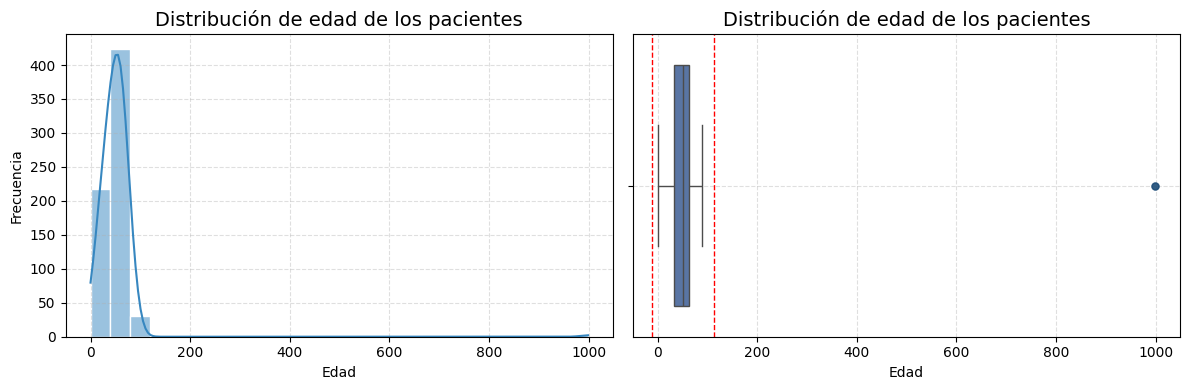

In [144]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

age = metadata_patients["age"]

median = age.median()
mad = np.median(np.abs(age - median))

k = 3
lower = median - k * 1.4826 * mad
upper = median + k * 1.4826 * mad

sns.histplot(
    age,
    bins=25,
    kde=True,
    color=sns.color_palette("Blues",5)[3],
    edgecolor="white",
    ax=axes[0]
)

axes[0].set_title("Distribución de edad de los pacientes", fontsize=14)
axes[0].set_xlabel("Edad")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(True, linestyle="--", alpha=0.4)

sns.boxplot(
    x=age,
    color="#4C72B0",
    flierprops=dict(
        marker='o',
        markerfacecolor="#1f4e79",
        markeredgecolor="#1f4e79",
        markersize=5,
        alpha=0.7
    ),
    ax=axes[1]
)

axes[1].axvline(lower, color="red", linestyle="--", linewidth=1)
axes[1].axvline(upper, color="red", linestyle="--", linewidth=1)

axes[1].set_title("Distribución de edad de los pacientes", fontsize=14)
axes[1].set_xlabel("Edad")
axes[1].grid(True, linestyle="--", alpha=0.4)

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.tight_layout()
plt.show()

En el **histograma** se evidencia que la mayoría de los pacientes se concentra en **edades adultas**, aproximadamente entre los **20** y **70** años. No obstante, se observa un valor **extremadamente alto** que distorsiona la escala del gráfico.

El **boxplot** permite confirmar la presencia **valores atípicos**, con un valor extremo cercano a **1000** años, el cual claramente no corresponde a una edad humana posible o alcanzable.

En base a lo anterior, se aplican un **Hampel filter** y un **Rosner's test** con el fin de verificar estadísticamente si en efecto estos registros corresponden a **datos atípicos**.

In [145]:
age_series = metadata_patients["age"]

hampel_outliers = hampel_test(age_series)

resultado = metadata_patients.loc[hampel_outliers, ["patient_id", "age"]]

styled_result = resultado.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_result.to_html() + "</div>"))

patient_id,age
aaaaapgz,999
aaaaacug,999


In [146]:
age_series = metadata_patients["age"]

rosner_outliers = rosner_test(age_series, k=5, alpha=0.05)

resultado = metadata_patients[metadata_patients["age"].isin(rosner_outliers)]

styled_result = resultado.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_result.to_html() + "</div>"))

patient_num_id,patient_id,original_split,age,gender,n_sessions,total_duration_sec,split_final
256,aaaaapgz,dev,999,1,33,407328.000000,0
415,aaaaacug,dev,999,2,2,3995.000000,0


Los resultados **confirman** la presencia de **2 outliers** en la variable **age**, ambos con un valor de **999** años. Dado que esta edad no corresponde a un valor humano plausible, se **corrobora** la sospecha inicial identificada en el **boxplot**, indicando que estos registros corresponden a probablemente, **errores de digitación**.

Luego, con el fin de obtener una representación más precisa y menos distorsionada de la edad de los pacientes, siguiendo la sugerencia de la **literatura médica**, se utiliza un **filtro de edad** en el que se limita la edad de los pacientes a **120** años, y se genera un nuevo **histograma**.

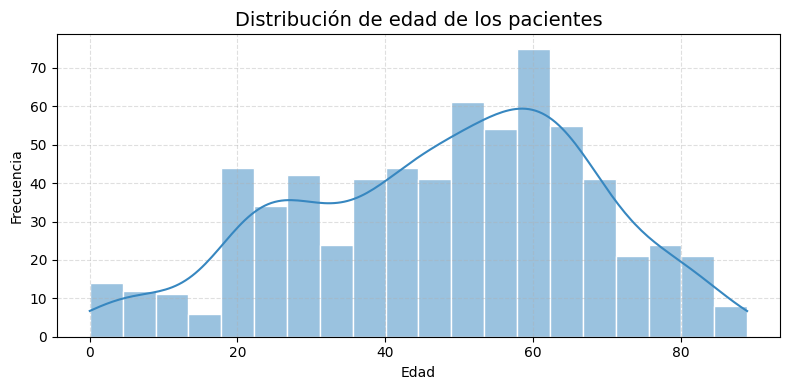

In [147]:
plt.figure(figsize=(8,4))

age_clean = metadata_patients[metadata_patients["age"] < 120]["age"]

sns.histplot(
    age_clean,
    bins=20,
    kde=True,
    color=sns.color_palette("Blues",5)[3],
    edgecolor="white"
)

plt.title("Distribución de edad de los pacientes", fontsize=14)
plt.xlabel("Edad")
plt.ylabel("Frecuencia")

plt.grid(True, linestyle="--", alpha=0.4)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()
plt.show()

Como era esperado, el **histograma** ya **no presenta** una **distribución distorsionada** y permite corroborar que la mayoría de los pacientes tienen entre **20** y **70** años de edad.



Luego, con el fin de **verificar** la normalidad del **ajuste** de la variable **edad**, se aplican los siguientes **tests** (antes de realizar estas pruebas se **excluyeron** los registros con edad igual a **999** años, previamente identificados como errores de registro).

In [148]:
age_clean = metadata_patients.loc[metadata_patients["age"] < 120, "age"]

```{admonition} Formulación de hipótesis para las pruebas de normalidad
:class: note

Es importante recordar que la **formulación de hipótesis** para estos tres tests es:

- H0: La edad de los pacientes **sigue** una distribución normal.
- H1: La edad de los pacientes **no sigue** una distribución normal.
```

In [149]:
from statsmodels.stats.diagnostic import lilliefors
from scipy.stats import shapiro, jarque_bera

stat_lillie, p_lillie = lilliefors(age_clean)
stat_shapiro, p_shapiro = shapiro(age_clean)
stat_jb, p_jb = jarque_bera(age_clean)

def estrellas_significancia(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

alpha = 0.05

results = pd.DataFrame({
    "Variable": ["Edad", "Edad", "Edad"],
    "Prueba": ["Lilliefors", "Shapiro-Wilk", "Jarque-Bera"],
    "Estadístico": [stat_lillie, stat_shapiro, stat_jb],
    "Valor p": [p_lillie, p_shapiro, p_jb]
})

results["Estadístico"] = results["Estadístico"].round(4)
results["Valor p"] = results["Valor p"].round(4)
results["Significancia"] = results["Valor p"].apply(estrellas_significancia)
results["Interpretación"] = results["Valor p"].apply(
    lambda p: "Se rechaza normalidad" if p < alpha else "No se rechaza normalidad"
)

styled_results = results.style.hide(axis='index').format({
    "Estadístico": "{:.4f}",
    "Valor p": "{:.4f}"
}).set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_results.to_html() + "</div>"))

Variable,Prueba,Estadístico,Valor p,Significancia,Interpretación
Edad,Lilliefors,0.0684,0.0010,**,Se rechaza normalidad
Edad,Shapiro-Wilk,0.9804,0.0000,***,Se rechaza normalidad
Edad,Jarque-Bera,19.9380,0.0000,***,Se rechaza normalidad


```{admonition} Conclusión de las pruebas de normalidad
:class: important

Los tres tests de normalidad aplicados **(Shapiro–Wilk, Lilliefors y Jarque–Bera**) arrojan **p-values** **significativamente menores** al **nivel de significancia de 0.05**, lo que conduce al **rechazo de la hipótesis nula de normalidad** en todos los casos. 

En particular, el test de **Lilliefors** presenta un nivel de significancia de ** (**p < 0.01**), mientras que los tests de **Shapiro–Wilk y Jarque–Bera** muestran *** (**p < 0.001**), indicando **evidencia estadística muy fuerte** contra la **hipótesis de normalidad**. 

En consecuencia, **se concluye que la distribución de la edad de los pacientes no sigue una distribución normal**, resultado que además es **consistente** con los patrones observados en los gráficos exploratorios previamente presentados.
```

Por último, con el fin de **verificar** que el resultado de las pruebas **no** se vea afectado por la **cantidad de datos** evaluada. Se genera el siguiente **QQ-Plot**:

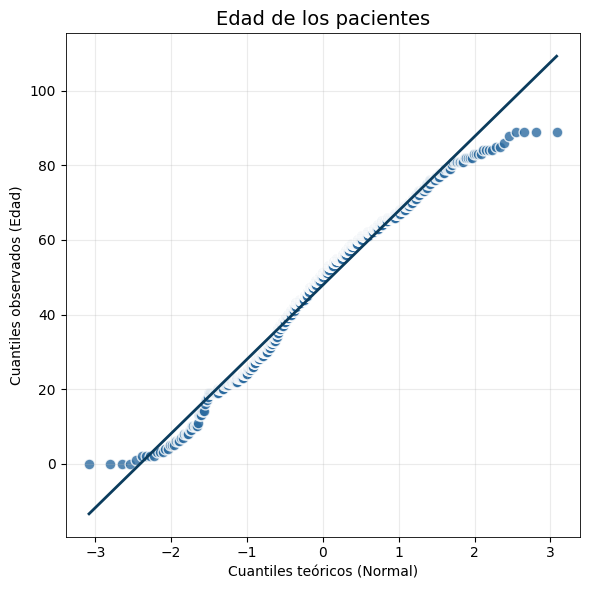

In [150]:
plt.figure(figsize=(6,6))

(osm, osr), (slope, intercept, r) = stats.probplot(age_clean, dist="norm")

plt.scatter(
    osm,
    osr,
    color="#2C6BA0",
    alpha=0.8,
    edgecolor="white",
    s=60
)

plt.plot(
    osm,
    slope*osm + intercept,
    color="#0B3C5D",
    linewidth=2
)

plt.title("Edad de los pacientes", fontsize=14)
plt.xlabel("Cuantiles teóricos (Normal)")
plt.ylabel("Cuantiles observados (Edad)")

plt.grid(alpha=0.25)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.6)

plt.tight_layout()
plt.show()

```{admonition} Interpretación del QQ-Plot
:class: tip

Como era esperado y como se **evidenció** a lo largo del desarrollo de esta sección, el **QQ-Plot** demuestra que la variable **edad** **no sigue** una **distribución normal**. 

Esto se debe a que se presentan **desviaciones claras** respecto a la **recta de normalidad**, particularmente en los **cuantiles extremos**; curvatura que indica que los cuantiles observados **no coinciden** con los cuantiles teóricos de una **distribución normal**.
```

### 1.3.2 Género de los pacientes

A continuación, se genera un nuevo **gráfico de barras** para estudiar la **distribución de género en pacientes**:

In [151]:
metadata_patients["gender_label"] = metadata_patients["gender"].map({
    1: "Male",
    2: "Female"
})

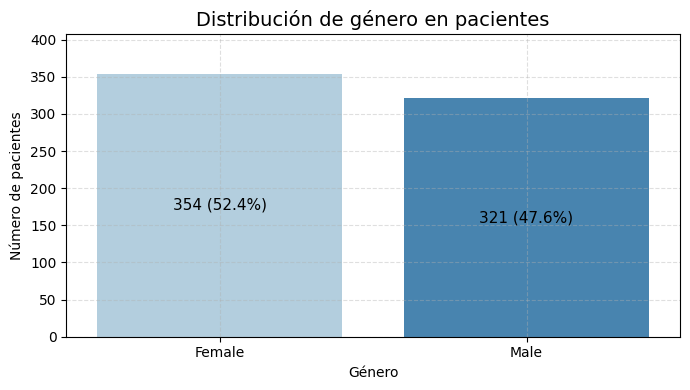

In [152]:

counts = metadata_patients["gender_label"].value_counts()
total = counts.sum()

plt.figure(figsize=(7,4))

ax = sns.barplot(
    x=counts.index,
    y=counts.values,
    hue=counts.index,
    palette="Blues",
    legend=False
)

plt.title("Distribución de género en pacientes", fontsize=14)
plt.xlabel("Género")
plt.ylabel("Número de pacientes")

for i, v in enumerate(counts.values):

    pct = (v / total) * 100

    ax.text(
        i,
        v / 2,
        f"{v} ({pct:.1f}%)",
        ha="center",
        va="center",
        fontsize=11,
        color="black"
    )

plt.grid(True, linestyle="--", alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.ylim(0, max(counts.values) * 1.15)

plt.tight_layout()
plt.show()

```{admonition} Interpretación de la distribución por género
:class: tip

Se observa una distribución **equilibrada** entre ambos grupos, con **354 pacientes femeninos (52.41%)** y **321 pacientes masculinos (47.6%)**. Esta proporción cercana al equilibrio es positiva desde el punto de vista del **modelado**, ya que reduce el riesgo de sesgos relacionados con la representación de género del dataset.
```

## 1.3 Sesiones y pacientes

Para observar la **distribución de sesiones EEG por paciente** se presenta el siguiente **boxplot** (incluye identificador de Hampel):

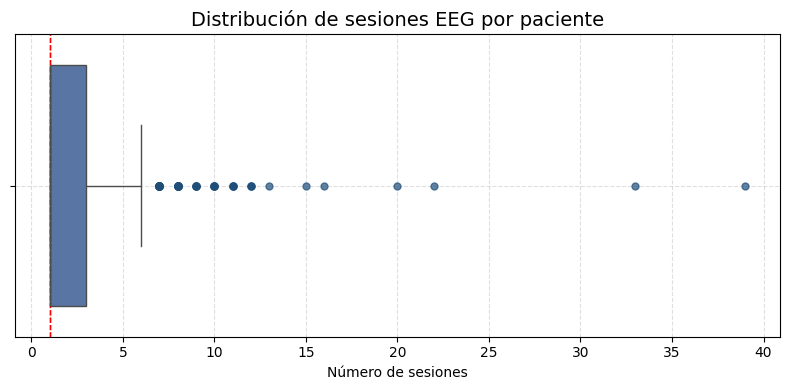

In [153]:
plt.figure(figsize=(8,4))

sessions = metadata_patients["n_sessions"]

median = sessions.median()
mad = np.median(np.abs(sessions - median))

k = 3
lower = median - k * 1.4826 * mad
upper = median + k * 1.4826 * mad

ax = sns.boxplot(
    x=sessions,
    color="#4C72B0",
    flierprops=dict(
        marker='o',
        markerfacecolor="#1f4e79",
        markeredgecolor="#1f4e79",
        markersize=5,
        alpha=0.7
    )
)

ax.axvline(lower, color="red", linestyle="--", linewidth=1)
ax.axvline(upper, color="red", linestyle="--", linewidth=1)

plt.title("Distribución de sesiones EEG por paciente", fontsize=14)
plt.xlabel("Número de sesiones")

plt.grid(True, linestyle="--", alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

```{admonition} Interpretación del boxplot
:class: tip

El **boxplot** muestra una distribución **asimétrica hacia la derecha**. La mayoría de los pacientes tiene entre **1 y 4** sesiones, mientras que un número reducido de pacientes presenta una cantidad considerablemente mayor de sesiones. alcanzando valores cercanos a las **40** sesiones.

Este comportamiento es **esperado** al trabajar con **datos clínicos**, pues, algunos pacientes requieren monitoreo prolongado o múltiples evaluaciones a lo largo del tiempo, y  otros solo necesitan asistir a un pequeño número de sesiones.
```

Para concluir, se genera un último diagrama de **caja y bigotes** con el objetivo de visualizar e interpretar la **distribución del tiempo total de EEG por paciente**:

In [154]:
metadata_patients["total_duration_hours"] = metadata_patients["total_duration_sec"] / 3600

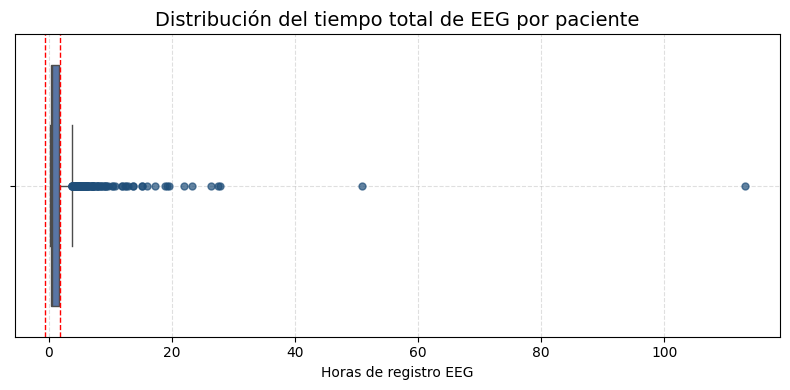

In [155]:
plt.figure(figsize=(8,4))

duration = metadata_patients["total_duration_hours"]

median = duration.median()
mad = np.median(np.abs(duration - median))

k = 3
lower = median - k * 1.4826 * mad
upper = median + k * 1.4826 * mad

ax = sns.boxplot(
    x=duration,
    color="#4C72B0",
    flierprops=dict(
        marker='o',
        markerfacecolor="#1f4e79",
        markeredgecolor="#1f4e79",
        markersize=5,
        alpha=0.7
    )
)

ax.axvline(lower, color="red", linestyle="--", linewidth=1)
ax.axvline(upper, color="red", linestyle="--", linewidth=1)

plt.title("Distribución del tiempo total de EEG por paciente", fontsize=14)
plt.xlabel("Horas de registro EEG")

plt.grid(True, linestyle="--", alpha=0.4)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()

```{admonition} Interpretación - Tiempo total de EEG por paciente
:class: tip

Nuevamente se observa una distribución **fuertemene sesgada hacia la derecha**, donde la mayoría de los pacientes presentan pocas horas de registro total, y un grupo más reducido, acumula un número considerablemente mayor, superando incluso las **100** horas.

Este patrón también es **coherente con el contexto clínico**, ya que algunos pacientes requieren **monitoreo EEG prolongado**, especialmente en estudios de **epilepsia**.
```

### 1.3.1 Características técnicas de los registros EEG

```{admonition} 
:class: note

Antes de analizar las **señales EEG** y sus características clínicas, resulta importante describir algunas **propiedades técnicas de los registros** incluidos en el dataset. Estas variables permiten entender las condiciones bajo las cuales fueron adquiridas las señales electroencefalográficas.

En particular, se examinan tres aspectos fundamentales asociados a cada sesión de registro:

- **Frecuencia de muestreo (`sfreq`)**  
  Indica el número de **muestras registradas por segundo** en la señal EEG, lo cual determina la resolución temporal de los datos.

- **Número de canales (`n_channels`)**  
  Corresponde al número de **electrodos utilizados durante cada sesión**, reflejando la cobertura espacial del registro EEG.

- **Fecha de registro (`date`)**  
  Permite analizar la **distribución temporal de los estudios EEG** dentro del corpus, proporcionando contexto sobre el periodo de adquisición de los datos.

El análisis de estas variables ofrece una primera aproximación a las **condiciones técnicas de adquisición del dataset**, lo cual resulta fundamental para orientar adecuadamente las etapas posteriores de **procesamiento y análisis de señales fisiológicas**.

#### Frecuencia de muestreo de las sesiones EEG

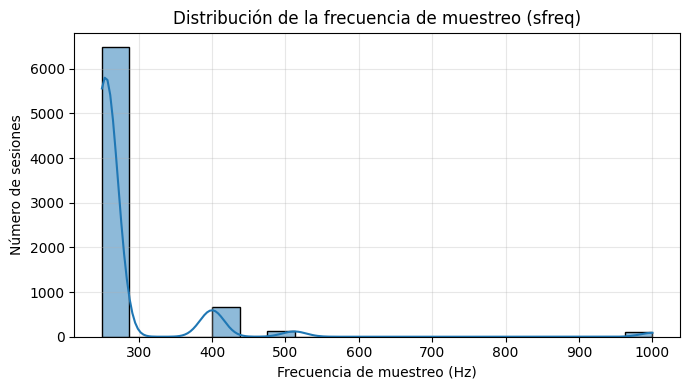

In [156]:
plt.figure(figsize=(7,4))

sns.histplot(
    metadata_sessions["sfreq"],
    bins=20,
    kde=True
)

plt.title("Distribución de la frecuencia de muestreo (sfreq)")
plt.xlabel("Frecuencia de muestreo (Hz)")
plt.ylabel("Número de sesiones")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La frecuencia de muestreo determina la resolución temporal con la que se registran las señales EEG. En el dataset se observan principalmente registros con frecuencias cercanas a **256 Hz**, lo cual es consistente con configuraciones comunes en estudios clínicos de electroencefalografía.

El histograma muestra que la gran mayoría de las sesiones se concentran alrededor de este valor, mientras que existen algunos registros con frecuencias superiores (por ejemplo **400 Hz, 500 Hz o incluso 1000 Hz**). Estas variaciones pueden deberse a diferencias en los equipos de adquisición o en los protocolos utilizados en distintos estudios clínicos.

En términos generales, la presencia de una frecuencia dominante sugiere una **relativa homogeneidad en la adquisición de las señales**, lo cual facilita los procesos posteriores de análisis y modelado.

#### Número de canales EEG por sesión

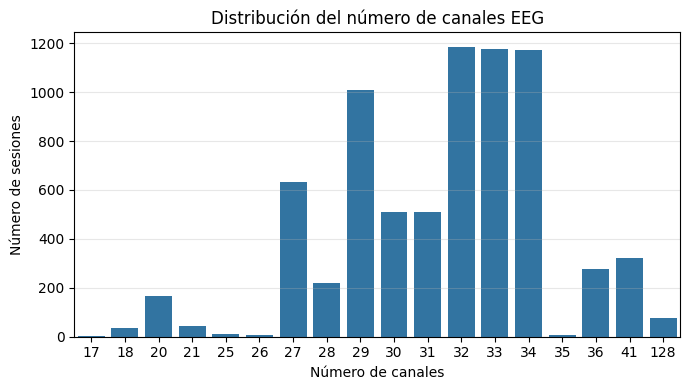

In [157]:
plt.figure(figsize=(7,4))

sns.countplot(
    x=metadata_sessions["n_channels"],
    order=sorted(metadata_sessions["n_channels"].unique())
)

plt.title("Distribución del número de canales EEG")
plt.xlabel("Número de canales")
plt.ylabel("Número de sesiones")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

El número de canales indica cuántos **electrodos EEG** fueron utilizados durante el registro de cada sesión. Este valor depende del sistema de adquisición y del protocolo clínico empleado.

En el dataset se observa que la mayoría de las sesiones presentan entre **29 y 34 canales**, lo cual coincide con configuraciones típicas de sistemas EEG clínicos basados en el sistema internacional **10–20** o variantes ampliadas.

También se identifican algunas configuraciones con un número menor de canales, así como casos con valores más altos, lo que sugiere que los registros provienen de **diferentes equipos o configuraciones experimentales**. A pesar de esta variabilidad, el rango observado se mantiene dentro de los estándares habituales para registros EEG clínicos.

#### Distribución temporal de las sesiones EEG

In [158]:
metadata_sessions["date"] = pd.to_datetime(
    metadata_sessions["date"],
    errors="coerce"
)

In [159]:
sessions_por_anio = (
    metadata_sessions["date"]
    .dt.year
    .value_counts()
    .sort_index()
    .rename("Sesiones")
    .to_frame()
)

sessions_por_anio["Porcentaje (%)"] = (
    sessions_por_anio["Sesiones"] / sessions_por_anio["Sesiones"].sum() * 100
).round(2)

styled_sessions = sessions_por_anio.style.format({
    "Sesiones": "{:,.0f}",
    "Porcentaje (%)": "{:.2f}%"
}).set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '10px')]}
])

display(HTML("<div style='text-align: center; width: 100%;'>" + styled_sessions.to_html() + "</div>"))

,Sesiones,Porcentaje (%)
date,,
1899,43,0.58%
2000,356,4.83%
2002,9,0.12%
2003,189,2.57%
2004,119,1.62%
2005,13,0.18%
2006,167,2.27%
2007,124,1.68%
2008,111,1.51%


La tabla muestra la distribución de las sesiones EEG según el **año de realización del registro**. La mayoría de los estudios se concentran entre **2012 y 2015**, lo cual indica que una gran parte del corpus fue recopilada durante ese periodo.

Sin embargo, también aparecen algunos registros con fechas extremadamente antiguas, como el año **1899**, lo cual resulta claramente inconsistente con el contexto de registros EEG modernos. 

Es altamente probable que estos valores correspondan a **errores o valores faltantes generados durante el proceso de extracción y estructuración del metadata**, particularmente al convertir fechas desde los archivos originales hacia el formato utilizado en la carpeta `metadata`.

Debido a que estos registros representan una proporción muy pequeña del dataset, se consideran **artefactos de procesamiento** y no reflejan fechas reales de adquisición de los estudios EEG.

En conjunto, el análisis de estas variables permite caracterizar las **condiciones técnicas de adquisición del dataset**, proporcionando contexto sobre la resolución temporal, la configuración de electrodos y la distribución temporal de los registros EEG. 

Esta información resulta útil para comprender la estructura del corpus antes de avanzar hacia etapas posteriores de **análisis exploratorio y modelado de aprendizaje automático**.

### 1.3.2 Comparación en los datos pre/post-procesamiento

In [160]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import tqdm
import warnings
warnings.filterwarnings('ignore')

PARQUET_PATH = "C:/MachineLearning/data/EDA/04_TUSZ_Features_ML/version=v1_raw_labels"

LABEL_MAPPING = {
    'bckg': 'BACKGROUND',
    'fnsz': 'FOCAL', 'cpsz': 'FOCAL', 'spsz': 'FOCAL',
    'gnsz': 'GENERALIZED', 'tcsz': 'GENERALIZED', 'tnsz': 'GENERALIZED',
    'absz': 'GENERALIZED', 'mysz': 'GENERALIZED'
}

all_files = list(Path(PARQUET_PATH).rglob("*.parquet"))
data_list = []
for f in tqdm.tqdm(all_files, desc="Cargando"):
    try:
        df_temp = pd.read_parquet(f)
        df_temp['class'] = df_temp['label'].map(lambda x: LABEL_MAPPING.get(x, 'BACKGROUND'))
        data_list.append(df_temp.sample(n=min(len(df_temp), 30), random_state=42))
    except:
        continue

df = pd.concat(data_list, ignore_index=True)
print(f"✅ {df.shape[0]:,} filas x {df.shape[1]} columnas")

Cargando: 100%|██████████| 1641/1641 [03:59<00:00,  6.85it/s]


✅ 49,169 filas x 1147 columnas


Métrica,Antes (RAW),Después (PROCESADO)
Nº Pacientes,675,-
Nº Sesiones / Archivos,39,-
Duración total (horas),1463.080000,-
Frecuencia de muestreo (Hz),256.000000,-
Nº Canales,32,-
Split Train,203,-
Split Test,472,-
Nº Ventanas / Segmentos,-,49169
Nº Features generadas,-,1143
Ventanas BACKGROUND,-,43239


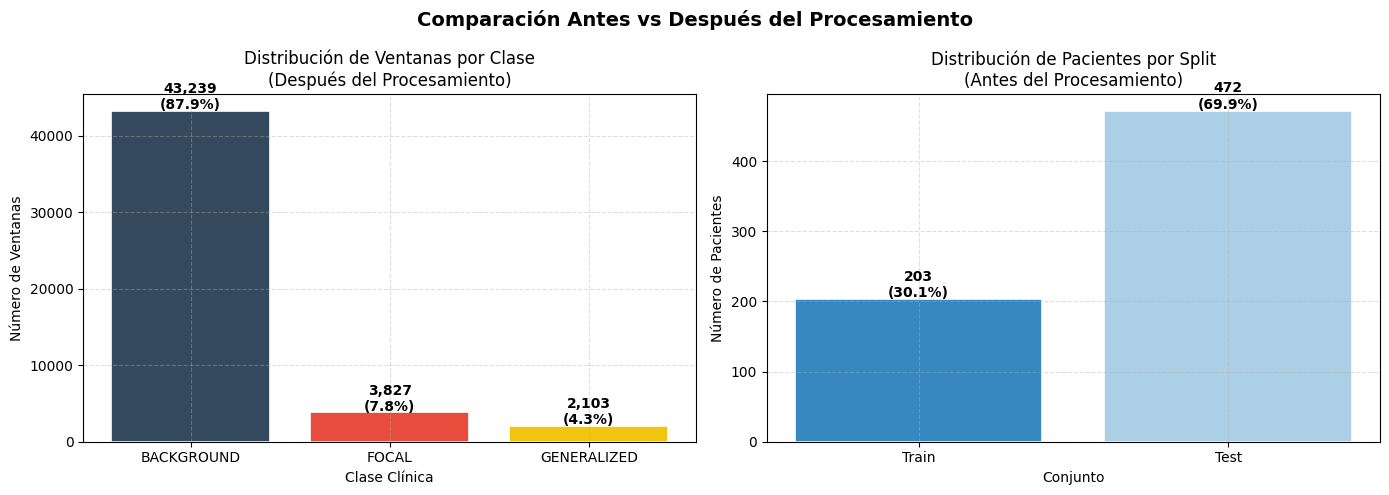

In [161]:
# ===============================
# 1. ANTES DEL PROCESAMIENTO (RAW)
# ===============================
raw_pacientes = metadata_patients['patient_num_id'].nunique()
raw_sesiones = metadata_sessions['session_id'].nunique()
raw_duracion_hrs = metadata_patients['total_duration_hours'].sum()
raw_sfreq = metadata_sessions['sfreq'].mode()[0]
raw_canales = metadata_sessions['n_channels'].mode()[0]
raw_train = (metadata_patients['split_final'] == 1).sum()
raw_test = (metadata_patients['split_final'] == 0).sum()

# ===============================
# 2. DESPUÉS DEL PROCESAMIENTO
# ===============================
total_ventanas = len(df)
n_features = len(df.drop(columns=['start_time','end_time','label','class'], errors='ignore').select_dtypes(include=[np.number]).columns)

clases = df['class'].value_counts()
background = clases.get('BACKGROUND', 0)
focal = clases.get('FOCAL', 0)
generalized = clases.get('GENERALIZED', 0)

# ===============================
# 3. TABLA COMPARATIVA
# ===============================
tabla = pd.DataFrame({
    'Métrica': [
        'Nº Pacientes',
        'Nº Sesiones / Archivos',
        'Duración total (horas)',
        'Frecuencia de muestreo (Hz)',
        'Nº Canales',
        'Split Train',
        'Split Test',
        'Nº Ventanas / Segmentos',
        'Nº Features generadas',
        'Ventanas BACKGROUND',
        'Ventanas FOCAL',
        'Ventanas GENERALIZED'
    ],
    'Antes (RAW)': [
        raw_pacientes,
        raw_sesiones,
        round(raw_duracion_hrs, 2),
        raw_sfreq,
        raw_canales,
        raw_train,
        raw_test,
        '-', '-', '-', '-', '-'
    ],
    'Después (PROCESADO)': [
        '-', '-', '-', '-', '-', '-', '-',
        total_ventanas,
        n_features,
        background,
        focal,
        generalized
    ]
})

display(tabla.style
    .hide(axis='index')
    .set_caption('Tabla Comparativa: Antes vs Después del Procesamiento')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'),
                                           ('font-weight', 'bold'),
                                           ('text-align', 'center'),
                                           ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4C72B0'),
                                      ('color', 'white'),
                                      ('font-size', '11px'),
                                      ('text-align', 'center'),
                                      ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'),
                                      ('padding', '6px'),
                                      ('font-size', '10px')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f0f4ff')]}
    ])
)

# ===============================
# 4. GRÁFICOS
# ===============================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparación Antes vs Después del Procesamiento",
             fontsize=14, fontweight='bold')

clases_labels = ['BACKGROUND', 'FOCAL', 'GENERALIZED']
clases_valores = [background, focal, generalized]
total_ventanas_plot = sum(clases_valores)
colores = ["#34495e", "#e74c3c", "#f1c40f"]

bars1 = axes[0].bar(clases_labels, clases_valores, color=colores, edgecolor='white', linewidth=1.2)
axes[0].set_title("Distribución de Ventanas por Clase\n(Después del Procesamiento)", fontsize=12)
axes[0].set_xlabel("Clase Clínica")
axes[0].set_ylabel("Número de Ventanas")
axes[0].grid(True, linestyle="--", alpha=0.4)
for bar, val in zip(bars1, clases_valores):
    pct = val / total_ventanas_plot * 100
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

split_labels = ['Train', 'Test']
split_valores = [raw_train, raw_test]
total_split = sum(split_valores)
colores_split = [sns.color_palette("Blues", 5)[3], sns.color_palette("Blues", 5)[1]]

bars2 = axes[1].bar(split_labels, split_valores,
                     color=colores_split, edgecolor='white', linewidth=1.2)
axes[1].set_title("Distribución de Pacientes por Split\n(Antes del Procesamiento)", fontsize=12)
axes[1].set_xlabel("Conjunto")
axes[1].set_ylabel("Número de Pacientes")
axes[1].grid(True, linestyle="--", alpha=0.4)
for bar, val in zip(bars2, split_valores):
    pct = val / total_split * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f'{val}\n({pct:.1f}%)', ha='center', fontsize=10, fontweight='bold')

for ax in axes:
    for spine in ax.spines.values():
        spine.set_visible(True)

plt.tight_layout()
plt.show()

La tabla compara el conjunto de datos en su estado original (RAW) con el resultado tras aplicar preprocesamiento y extracción de características, mostrando de forma clara cómo los datos crudos se transformaron en un recurso adecuado para modelos de Machine Learning.
En su estado inicial, los datos incluyen información de 675 pacientes, distribuidos en 39 sesiones o archivos, que suman aproximadamente 1463 horas de registros EEG. Las señales se capturaron a 256 Hz con 32 canales, siguiendo estándares habituales en registros clínicos de electroencefalografía.
Después, el conjunto de datos se dividió en entrenamiento y prueba: 203 instancias se destinaron al entrenamiento y 472 al conjunto de prueba, permitiendo así una evaluación objetiva del desempeño de los modelos en datos no vistos.
Durante el preprocesamiento, las señales continuas fueron segmentadas en ventanas temporales, generando 49 169 segmentos. Esta técnica, común en el análisis de EEG, ayuda a capturar patrones locales en el tiempo y facilita la extracción de características relevantes para el modelado.
A partir de estas ventanas, se extrajeron 1 143 características mediante distintas transformaciones y métricas basadas en la señal. Estas features incluyen descriptores estadísticos, espectrales y estructurales, diseñados para capturar aspectos importantes de la actividad cerebral.
En cuanto a la distribución de clases, el dataset presenta un claro desbalance: la mayoría de las ventanas corresponden a la clase BACKGROUND (43 239), que representa actividad cerebral normal. Las clases FOCAL y GENERALIZED, asociadas a eventos epilépticos, tienen muchas menos observaciones (3 827 y 2 103 ventanas respectivamente).
Este desbalance es relevante para el análisis posterior, ya que puede influir en el entrenamiento de los modelos de clasificación. Sin estrategias adecuadas para manejar el desbalance, los algoritmos podrían inclinarse hacia la clase mayoritaria. Por eso, es importante considerar técnicas como el re-muestreo, la ponderación de clases o el uso de métricas de evaluación especializadas.
En resumen, la tabla ilustra cómo el preprocesamiento transforma largas grabaciones de EEG en un dataset estructurado, compuesto por miles de segmentos y cientos de características, listo para ser utilizado en análisis estadísticos y modelos de aprendizaje automático enfocados en la detección y clasificación de eventos epilépticos.

# 2. Variable de interés

El conjunto de datos procesado cuenta con un total de **1,143** variables de caracterización, derivadas de la aplicación de múltiples métricas espectrales y no lineales sobre los distintos canales del EEG. Dado el elevado número de features disponibles, un análisis exploratorio exhaustivo sobre la totalidad de las variables resultaría computacionalmente costoso y podría diluirse en la generalidad, dificultando la identificación de patrones clínicamente relevantes. Por esta razón, se introduce un proceso de selección de variables orientado a determinar cuáles features presentan mayor poder discriminativo entre las clases clínicas de interés (**BACKGROUND, FOCAL y GENERALIZED**). Para ello se emplea una estrategia de triangulación basada en dos índices complementarios: la Información Mutua (MI), que cuantifica la dependencia estadística entre cada variable y la etiqueta de clase sin asumir linealidad, y el algoritmo mRMR (**Maximum Relevance Minimum Redundancy**), que selecciona el subconjunto de variables que maximiza la relevancia conjunta minimizando la redundancia entre ellas. El resultado de este proceso es un subconjunto de **15** variables que serán objeto del análisis exploratorio detallado en las secciones siguientes.

## 2.1 Determinación exploratoria de características relevantes

In [162]:
import pandas as pd
import pyarrow
pd.set_option('display.max_colwidth', None)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path
import tqdm


```{admonition} Varianza Muestral
:class: note
La varianza muestral se define como:

$$s^2 = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

donde $x_i$ representa cada observación, $\bar{x}$ es la media muestral y $n$ es el número de observaciones.
```

```{admonition} Análisis de la varianza de las características
:class: note

El análisis de la varianza promedio de las características por clase muestra **diferencias notables** entre los distintos tipos de actividad cerebral. En particular, la clase **BACKGROUND** presenta la **mayor varianza promedio (≈ 1,702,956)**, seguida por la clase **GENERALIZED (≈ 1,132,335)**, mientras que la clase **FOCAL** exhibe una varianza **considerablemente menor (≈ 298,964)**.

Desde la perspectiva del procesamiento de señales EEG, estas diferencias pueden interpretarse en términos de la heterogeneidad de los patrones de actividad neuronal asociados a cada tipo de evento.
```



## 2.2 Selección estadística inicial de características mediante información mutua y control de comparaciones múltiples

### 2.2.1 Características más relevantes

```{admonition} Selección de características
:class: important

El análisis presentado corresponde a un proceso de **selección de características (feature selection)** realizado mediante una combinación de **Mutual Information (MI)**, el algoritmo **Minimum Redundancy Maximum Relevance (mRMR)** y el análisis de varianza. El objetivo de esta etapa es identificar aquellas variables que contienen mayor información relevante para la clasificación de los distintos tipos de actividad cerebral registrados en las señales EEG, minimizando al mismo tiempo la redundancia entre características.

La tabla muestra las **15 características más informativas del conjunto de datos**, ordenadas según el ranking producido por el algoritmo mRMR. Cada registro incluye la posición de la característica en el ranking, el nombre de la variable, el valor de **Mutual Information** respecto a la variable objetivo y la **varianza** observada en el conjunto de datos.

Este tipo de selección es particularmente importante en problemas de análisis de EEG, ya que estos datasets suelen presentar **alta dimensionalidad**, es decir, un número muy grande de variables en comparación con el número de observaciones. En este contexto, la selección de características permite reducir la dimensionalidad conservando únicamente aquellas variables que aportan mayor capacidad discriminativa para el modelo de clasificación.
```

---

### 2.2.2 Información Mutua

```{admonition} Definición de Mutual Information
:class: note

La **Mutual Information (MI)** mide la cantidad de información compartida entre una característica $X$ y la variable objetivo $Y$. Matemáticamente, esta medida puede expresarse como:

$$
MI(X,Y) = H(X) + H(Y) - H(X,Y)
$$

donde $H(\cdot)$ representa la **entropía de Shannon**, que cuantifica la incertidumbre asociada a una variable aleatoria.
```

```{admonition} Interpretación de la medida
:class: tip

En términos intuitivos, la información mutua mide **cuánto se reduce la incertidumbre sobre la variable objetivo al conocer el valor de una característica**. Por lo tanto, valores más altos de $MI(X,Y)$ indican que la variable contiene mayor información relevante para distinguir entre las diferentes clases del problema.
```

```{admonition} Observación sobre los valores de MI
:class: warning

En el ranking presentado, los valores de información mutua se encuentran aproximadamente en el rango:

$$
MI \in [0.009, 0.021]
$$

Aunque estos valores pueden parecer pequeños, este comportamiento es esperable en contextos de **alta dimensionalidad** como el análisis de señales EEG, donde cada característica individual aporta únicamente una fracción de la información total necesaria para la clasificación.

La característica mejor posicionada en el ranking es **P4-O2_A5_ll**, con un valor de $MI = 0.0215$, lo que sugiere que esta variable proporciona la mayor cantidad de información individual para discriminar entre los distintos tipos de actividad cerebral presentes en el dataset.
```

---

### 2.2.3  Varianza de las Características

```{admonition} Interpretación de la varianza
:class: note

La columna de **varianza** refleja el grado de dispersión de los valores de cada característica dentro del conjunto de datos. Se observa que las features presentan niveles de varianza muy diferentes entre sí, con valores que van desde magnitudes pequeñas hasta valores considerablemente elevados.
```

```{admonition} Diferencias de escala en las features
:class: tip

Esta diferencia se debe a que cada característica captura **propiedades distintas de la señal EEG** y, por lo tanto, se encuentra en **escalas numéricas diferentes**. Por ejemplo:

- métricas estadísticas como **skewness (asimetría)** suelen tomar valores relativamente pequeños
- medidas relacionadas con **energía o complejidad de la señal** pueden presentar valores significativamente mayores.
```

```{admonition} Implicación para el preprocesamiento
:class: warning

La presencia de diferentes escalas sugiere que, durante las etapas posteriores del análisis, puede ser necesario aplicar **técnicas de normalización o estandarización**, con el fin de evitar que ciertas características dominen el proceso de aprendizaje únicamente debido a su escala numérica.
```

---

### 2.2.4 Estructura de las características EEG

```{admonition} Estructura general de una feature EEG
:class: important

Un aspecto fundamental para comprender la tabla consiste en interpretar correctamente la estructura de los nombres de las características. Cada **feature** contiene información sobre tres componentes principales de la señal EEG:

1. La región cerebral analizada  
2. El nivel de descomposición de la señal  
3. El tipo de característica estadística extraída  

En términos generales, una característica puede representarse como:

$$
\text{Electrodo}_1 - \text{Electrodo}_2 \; \_ \; \text{NivelWavelet} \; \_ \; \text{Característica}
$$
```

Por ejemplo, la feature:

**Fp2-F4_D3_dkatz**

puede interpretarse de la siguiente manera.

---

### 2.2.5 Derivación EEG

```{admonition} Derivación entre electrodos
:class: note

**Fp2-F4**

Representa la derivación entre los electrodos **Fp2 y F4** del sistema internacional **10–20** utilizado en electroencefalografía.

Esta derivación mide la **diferencia de potencial eléctrico entre dos regiones de la corteza frontal**, permitiendo capturar variaciones espaciales de la actividad cerebral.
```

---

### 2.2.6 Nivel de descomposición wavelet

```{admonition} Nivel de detalle wavelet
:class: tip

**D3**

Corresponde al **tercer nivel de detalle de la descomposición wavelet** de la señal.

Las transformadas wavelet permiten descomponer el EEG en diferentes **bandas de frecuencia**, separando componentes de alta y baja frecuencia. En general:

- **D (Detail)** representa componentes de alta frecuencia  
- **A (Approximation)** representa componentes de baja frecuencia  

Esto permite analizar la señal en distintas escalas temporales.
```

---

### 2.2.7 Tipo de característica extraída

```{admonition} Métrica de complejidad
:class: note

**dkatz**

Corresponde a la **dimensión fractal de Katz**, una medida utilizada para cuantificar la **complejidad geométrica de una señal temporal**.

La dimensión fractal permite caracterizar el grado de irregularidad o complejidad del EEG, lo cual resulta especialmente útil para detectar cambios en la dinámica cerebral asociados a eventos epilépticos.
```

---

### 2.2.8 Tipos de características presentes en el ranking

```{admonition} Tipos de métricas extraídas del EEG
:class: important

Las features seleccionadas incluyen diversas métricas que capturan diferentes propiedades de la señal EEG:

- **pwr** → potencia de la señal en una banda de frecuencia  
- **kurt** → curtosis de la distribución de amplitudes  
- **skew** → asimetría de la distribución  
- **ll (line length)** → medida de complejidad temporal de la señal  
- **dkatz** → dimensión fractal de Katz  
- **teo** → operador de energía de Teager  
```

Estas métricas permiten describir propiedades relacionadas con:

- energía de la señal
- estructura estadística
- complejidad temporal
- comportamiento no lineal

---


```{admonition} Conclusión de la selección de características
:class: important

En conjunto, los resultados del ranking sugieren que la discriminación entre clases se basa en una **combinación de información espacial, espectral y estadística de las señales EEG**.

La selección de estas características mediante el método **mRMR** permite reducir la dimensionalidad del problema manteniendo las variables más informativas y menos redundantes, lo cual puede contribuir a mejorar el rendimiento de los modelos de clasificación en etapas posteriores del análisis.
```

A continuación, se tabuló la descripción de las features con su respectiva descripción y contextualización.

In [163]:
data_dict_top15 = pd.DataFrame({
    'mRMR Rank':     range(1, 16),
    'Feature':       list(top15_info.keys()),
    'Mutual Info':   ranking_mi[list(top15_info.keys())].round(4).values,
    'Varianza':      varianza[list(top15_info.keys())].round(4).values,
    'Descripción':   list(top15_info.values())
})

styled_top15 = data_dict_top15.style.hide(axis='index').format({
    'mRMR Rank': '{:d}',
    'Mutual Info': '{:.4f}',
    'Varianza': '{:.4f}'
}).background_gradient(
    cmap='Blues', subset=['Mutual Info']
).background_gradient(
    cmap='Oranges', subset=['Varianza']
).set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '10px')]},
    {'selector': 'td:last-child', 'props': [('text-align', 'left'),
                                             ('max-width', '400px'),
                                             ('white-space', 'normal')]}
])

display(HTML("<h4 style='text-align:center'>Top 15 Features — mRMR + Mutual Information + Descripción</h4>"))
display(HTML("<div style='text-align: center; width: 100%;'>" + styled_top15.to_html() + "</div>"))

mRMR Rank,Feature,Mutual Info,Varianza,Descripción
1,P4-O2_A5_ll,0.0215,0.7547,Longitud de línea del canal parieto-occipital derecho en banda de aproximación (A5). Mide cambios de amplitud en frecuencias bajas.
2,Fp2-F4_D3_dkatz,0.0104,1315024.3750,Dimensión fractal de Katz del canal fronto-polar derecho en banda D3. Cuantifica la complejidad no lineal de la señal.
3,C3-P3_D1_skew,0.0111,0.1142,Asimetría estadística del canal centro-parietal izquierdo en banda D1. Indica asimetría en la distribución de la señal de alta frecuencia.
4,Fp2-F8_A5_dkatz,0.0093,72.9932,Dimensión fractal de Katz del canal fronto-temporal derecho en banda de aproximación. Mide irregularidad en frecuencias bajas.
5,T4-T6_D5_dkatz,0.0095,5745.0762,Dimensión fractal de Katz del canal temporal derecho en banda D5. Captura complejidad en frecuencias delta-theta.
6,P3-O1_D1_skew,0.0128,0.1158,Asimetría del canal parieto-occipital izquierdo en banda D1. Refleja asimetría en componentes de alta frecuencia.
7,Fp1-F7_D1_dkatz,0.0070,787392.4375,Dimensión fractal de Katz del canal fronto-temporal izquierdo en banda D1. Mide complejidad en frecuencias gamma.
8,T3-T5_D2_dkatz,0.0068,13343313.0000,Dimensión fractal de Katz del canal temporal izquierdo en banda D2. Captura irregularidad en frecuencias beta alta.
9,T3-T5_D4_pwr,0.0099,10.9185,Potencia del canal temporal izquierdo en banda D4. Mide la energía de la señal en frecuencias theta.
10,F7-T3_D5_dkatz,0.0079,152428.8594,Dimensión fractal de Katz del canal fronto-temporal izquierdo en banda D5. Mide complejidad en frecuencias delta.


## 2.3 Selección de variables y Análisis Exploratorio

### 2.3.1 Interpretación de las características seleccionadas

El análisis de las 15 características permite identificar varios patrones relevantes en la información extraída de las señales EEG. En particular, se observan regularidades en términos de complejidad de la señal, localización espacial de los electrodos y distribución espectral de las frecuencias analizadas.

---

### 2.3.2 Complejidad de la señal EEG

```{admonition} Dimensión fractal de Katz (dkatz)
:class: note

**Dimensión fractal de Katz (dkatz).**  
Se observa un claro predominio de características basadas en la dimensión fractal de Katz (dkatz), la cual aparece en la mayoría de las features seleccionadas. Esta medida cuantifica la complejidad geométrica o irregularidad temporal de una señal. En este contexto, se sugiere que la complejidad no lineal de la señal EEG constituye una propiedad altamente informativa para distinguir entre diferentes tipos de actividad cerebral. Este resultado sugiere que los patrones asociados a eventos epilépticos pueden manifestarse como cambios en la estructura temporal o en la irregularidad de la señal.
```

---

### 2.3.3 Localización espacial de las señales

**Derivaciones frontales y temporales.**  
Muchas de las características más relevantes provienen de derivaciones como **Fp1–F7, Fp2–F8, T3–T5, F7–T3**, entre otras. Estas corresponden principalmente a regiones **frontales, fronto-temporales y temporales** del cerebro. En este caso, se sugiere que estas regiones están asociadas con áreas corticales donde frecuentemente se originan o se propagan crisis epilépticas, particularmente en epilepsias del lóbulo temporal. La recurrencia de estas derivaciones dentro de las características mejor posicionadas sugiere que la información espacial proveniente de estas zonas cerebrales podría ser altamente discriminativa para el problema de clasificación.

---

### 2.3.4 Información espectral de la señal

```{admonition} Múltiples niveles wavelet
:class: tip

**Múltiples niveles wavelet (D1–D5, A5).**  
Las features seleccionadas aparecen distribuidas en distintos niveles de descomposición wavelet, incluyendo **D1, D2, D3, D4, D5 y A5**, lo que indica que la información relevante para la clasificación no se concentra en una sola banda de frecuencia. En este sentido, Sharma et al. (2020) demuestran que *“DWT decomposes EEG signals into time-frequency components... detail coefficients (DCs) D1–D5... superior for epileptic seizure detection”* [web:116]. Este resultado confirma que la información relevante para la detección de crisis epilépticas puede encontrarse distribuida a lo largo de múltiples componentes espectrales de la señal EEG.
```

---

### 2.3.5 Métricas estadísticas y energéticas

**Skewness, potencia (pwr) y line length (ll).**  
Además de las medidas de complejidad fractal, también aparecen otras métricas como **skewness (skew)**, **potencia de la señal (pwr)** y **line length (ll)**. Estas variables capturan diferentes propiedades de la señal: la skewness describe la asimetría de la distribución de amplitudes, la potencia mide la energía de la señal dentro de una determinada banda de frecuencia, mientras que la longitud de línea cuantifica la variabilidad o actividad temporal de la señal. En este caso, se sugiere que estas características aportan información **estadística, energética y temporal complementaria**, lo cual puede contribuir a mejorar la capacidad discriminativa del conjunto de features.

---

```{admonition} Síntesis de los resultados
:class: important

En conjunto, estos resultados sugieren que la discriminación entre las distintas clases de actividad cerebral se basa en una combinación de **información espacial (derivaciones EEG), espectral (bandas de frecuencia wavelet) y dinámica (complejidad y propiedades estadísticas de la señal)**. Esta combinación de características permite capturar distintos aspectos del comportamiento del EEG, lo que potencialmente facilita la identificación de patrones asociados a eventos epilépticos dentro del conjunto de datos.
```

In [165]:
from scipy import stats
from IPython.display import display
import pandas as pd

META_COLS = ['start_time', 'end_time', 'label', 'class']
X = df.drop(columns=META_COLS, errors='ignore').select_dtypes(include=[np.number])

resultados = []

for feat in df_tabla_top['Feature']:
    serie = X[feat].dropna()
    
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    
    resultados.append({
        'Feature':   feat,
        'Media':     round(serie.mean(), 4),
        'Mediana':   round(serie.median(), 4),
        'Std':       round(serie.std(), 4),
        'Min':       round(serie.min(), 4),
        'Max':       round(serie.max(), 4),
        'Q1':        round(Q1, 4),
        'Q3':        round(Q3, 4),
        'IQR':       round(IQR, 4),
        'Skewness':  round(stats.skew(serie), 4),
        'Kurtosis':  round(stats.kurtosis(serie), 4),
    })

df_centralidad = pd.DataFrame(resultados)

display(df_centralidad.style
    .hide(axis='index')
    .background_gradient(cmap='Blues', subset=['Media', 'Mediana', 'Std'])
    .background_gradient(cmap='Reds', subset=['Skewness', 'Kurtosis'])
    .format({'Media': '{:.4f}', 'Mediana': '{:.4f}', 'Std': '{:.4f}',
             'Min': '{:.4f}', 'Max': '{:.4f}', 'Q1': '{:.4f}',
             'Q3': '{:.4f}', 'IQR': '{:.4f}', 'Skewness': '{:.4f}',
             'Kurtosis': '{:.4f}'})
    .set_caption('Tabla de Centralidad - Top 15 Features')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'),
                                           ('font-weight', 'bold'),
                                           ('text-align', 'center'),
                                           ('padding', '10px')]},
        {'selector': 'th', 'props': [('background-color', '#4C72B0'),
                                      ('color', 'white'),
                                      ('font-size', '11px'),
                                      ('text-align', 'center'),
                                      ('padding', '8px')]},
        {'selector': 'td', 'props': [('text-align', 'center'),
                                      ('padding', '6px'),
                                      ('font-size', '10px')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#f0f4ff')]}
    ])
)

Feature,Media,Mediana,Std,Min,Max,Q1,Q3,IQR,Skewness,Kurtosis
P4-O2_A5_ll,2.6781,2.6230,0.8687,0.0000,24.4593,2.1581,3.1189,0.9608,2.4945,31.3533
P4-O2_D1_kurt,2.2677,0.2227,12.0621,-1.4763,255.7025,-0.0699,0.9077,0.9777,14.4640,262.0324
Fp1-F3_D5_pwr,2.5104,1.5334,14.6967,0.0000,1790.9092,0.7745,2.7484,1.9739,79.9227,7863.4411
Fp2-F4_D3_dkatz,-2.0453,5.1654,1146.7451,-215718.4844,43000.3711,-1.7010,8.8951,10.5961,-151.0964,26998.0876
P4-O2_D1_skew,-0.0107,-0.0055,0.3447,-8.4692,8.3472,-0.0349,0.0226,0.0576,-3.9386,442.5753
Fz-Cz_D1_ll,0.1232,0.0865,0.1418,0.0000,8.9997,0.0491,0.1475,0.0984,10.3080,384.5284
Fp2-F4_D4_teo,1.0109,0.5326,7.9241,0.0000,839.8881,0.2655,0.9841,0.7186,65.8985,5303.9656
Cz-Pz_D5_ll,1.8309,1.7512,0.7281,0.0000,24.7202,1.3697,2.2042,0.8345,2.6660,47.2796
T6-O2_D1_skew,-0.0172,-0.0122,0.3340,-8.4436,8.3066,-0.0429,0.0155,0.0584,-1.9144,479.3539
Cz-Pz_D1_skew,-0.0072,-0.0027,0.3511,-8.4831,8.4785,-0.0333,0.0266,0.0599,-0.0349,413.1998


### 2.3.6 Valores atípicos (Outliers)

```{admonition} Identificación de valores atípicos
:class: note

Uno de los aspectos más relevantes observados en la Tabla de Centralidad es la presencia de valores atípicos (*outliers*) en varias de las características seleccionadas. Los outliers fueron identificados utilizando el criterio del rango intercuartílico (IQR), el cual considera como valores atípicos aquellos que se encuentran por debajo de \(Q1 - 1.5 \times IQR\) o por encima de \(Q3 + 1.5 \times IQR\).
```

---

### 2.3.7 Distribución de outliers en las features

La gráfica muestra el porcentaje de valores atípicos presentes en cada una de las **15 características más relevantes**.

En la gráfica se observa que algunas características presentan porcentajes considerables de outliers. Por ejemplo, la característica *Fp2-F4_D3_dkatz* presenta aproximadamente un 15.54% de valores atípicos, mientras que *P4-O2_D1_kurt* presenta cerca del 13.89%. Asimismo, otras características como *T4-T6_D5_dkatz* y varias métricas de *skewness* también muestran proporciones relevantes de valores extremos.

---

```{admonition} Conclusión
:class: important

En consecuencia, en lugar de eliminar completamente estos valores extremos, se sugiere que su presencia sea interpretada como una manifestación de la naturaleza dinámica y no estacionaria de las señales EEG, así como de la posible aparición de eventos neurofisiológicos relevantes dentro de los registros analizados.
```

# 3. Análisis Univariado

In [ ]:
from scipy import stats
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from statsmodels.stats.multitest import multipletests
import numpy as np
from IPython.display import display, HTML

def hampel_filter(serie, k=3):
    median    = serie.median()
    mad       = np.median(np.abs(serie - median))
    threshold = k * 1.4826 * mad
    return serie[np.abs(serie - median) > threshold].index

def identificar_densidad_np(serie, clase):
    serie     = serie.dropna()
    n         = len(serie)
    skew_val  = stats.skew(serie)
    kurt_val  = stats.kurtosis(serie)
    bc        = (skew_val**2 + 1) / (kurt_val + 3 * ((n-1)**2 / ((n-2)*(n-3))))
    kde       = gaussian_kde(serie)
    x_grid    = np.linspace(serie.min(), serie.max(), 1000)
    kde_vals  = kde(x_grid)
    peaks, _  = find_peaks(kde_vals, prominence=0.01 * kde_vals.max())
    n_modas   = len(peaks)

    if n_modas > 2:
        modalidad = 'Multimodal'
    elif n_modas == 2 or bc > 0.555:
        modalidad = 'Bimodal'
    else:
        modalidad = 'Unimodal'

    if modalidad == 'Unimodal':
        if abs(skew_val) < 0.5 and abs(kurt_val) < 1:
            tipo = 'Unimodal Simétrica'
        elif skew_val > 0.5 and kurt_val > 3:
            tipo = 'Unimodal · Cola derecha · Leptocúrtica'
        elif skew_val < -0.5 and kurt_val > 3:
            tipo = 'Unimodal · Cola izquierda · Leptocúrtica'
        elif skew_val > 0.5:
            tipo = 'Unimodal · Cola derecha'
        elif skew_val < -0.5:
            tipo = 'Unimodal · Cola izquierda'
        elif kurt_val > 3:
            tipo = 'Unimodal · Leptocúrtica'
        elif kurt_val < -1:
            tipo = 'Unimodal · Platicúrtica'
        else:
            tipo = 'Unimodal · Aproximadamente normal'
    else:
        tipo = modalidad

    return {
        'Clase':         clase,
        'N modas':       n_modas,
        'BC':            round(bc, 4),
        'Skewness':      round(skew_val, 4),
        'Kurtosis':      round(kurt_val, 4),
        'Tipo densidad': tipo
    }

def identificar_distribucion(serie_clase, clase):
    distribuciones = {
        'Log-Normal':       stats.lognorm,
        'Gamma':            stats.gamma,
        'Weibull':          stats.weibull_min,
        'Cauchy':           stats.cauchy,
        'Pareto':           stats.pareto,
        'Laplace':          stats.laplace,
        'Exponencial':      stats.expon,
        'Chi-cuadrado':     stats.chi2,
        'Burr':             stats.burr,
        'Lévy':             stats.levy,
        'Inverse Gaussian': stats.invgauss,
        'Beta':             stats.beta,
    }
    resultados = []
    for nombre, dist in distribuciones.items():
        try:
            params          = dist.fit(serie_clase)
            stat_ks, pvalor = stats.kstest(serie_clase, dist.cdf, args=params)
            resultados.append({
                'Distribución': nombre,
                'KS Stat':      round(stat_ks, 4),
                'p-valor':      round(pvalor, 4),
                'Ajuste':       '✅ Bueno' if pvalor > 0.05 else '⚠️ Regular' if pvalor > 0.01 else '❌ Malo'
            })
        except Exception:
            continue

    df_res = pd.DataFrame(resultados).sort_values('p-valor', ascending=False).reset_index(drop=True)
    df_res.insert(0, 'Clase', clase)
    df_res.insert(1, 'Rank', range(1, len(df_res) + 1))
    mejor = df_res.iloc[0]['Distribución']
    return df_res, mejor

def estilo_tabla(df, format_dict=None, gradient_cols=None, left_cols=None):
    s = df.style.hide(axis='index')
    if format_dict:
        s = s.format(format_dict)
    if gradient_cols:
        for col, cmap in gradient_cols.items():
            s = s.background_gradient(cmap=cmap, subset=[col])
    table_styles = [
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                    ('width', 'auto'), ('border-collapse', 'collapse')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                      ('color', 'black'), ('font-weight', 'bold'),
                                      ('border', '1px solid black'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                      ('padding', '6px 15px'), ('background-color', 'white')]}
    ]
    s = s.set_table_styles(table_styles)
    if left_cols:
        for col in left_cols:
            s = s.set_properties(subset=[col], **{'text-align': 'left', 'font-weight': 'bold'})
    return s

def analisis_univariado(feat):
    rank = df_tabla_top[df_tabla_top['Feature'] == feat]['mRMR_Rank'].values[0]

    display(HTML(f"""
    <h3 style='text-align:center; border-bottom: 2px solid #2c3e50;
               padding-bottom:8px; font-family: serif;'>
               Rank #{rank} — {feat}
    </h3>"""))

    # ── 1. Tabla morfológica ───────────────────────────────────
    display(HTML("<h4 style='text-align:center'>1. Descripción Morfológica por Clase</h4>"))
    audit_data = []
    for clase in clases:
        serie    = df[df['class'] == clase][feat].dropna()
        Q1       = serie.quantile(0.25)
        Q3       = serie.quantile(0.75)
        IQR      = Q3 - Q1
        skew_val = stats.skew(serie)
        kurt_val = stats.kurtosis(serie)

        if abs(skew_val) < 0.5:
            morf = 'Simétrica'
        elif skew_val >= 0.5:
            morf = 'Asimetría positiva'
        else:
            morf = 'Asimetría negativa'

        if kurt_val > 3:
            morf += ' · Leptocúrtica'
        elif kurt_val < -1:
            morf += ' · Platicúrtica'
        else:
            morf += ' · Mesocúrtica'

        audit_data.append({
            'Clase':           clase,
            'Rango [Min–Max]': f"[{serie.min():,.4f} – {serie.max():,.4f}]",
            'Media (SD)':      f"{serie.mean():,.4f} ({serie.std():,.4f})",
            'Mediana (IQR)':   f"{serie.median():,.4f} ({IQR:,.4f})",
            'Skewness':        round(skew_val, 4),
            'Kurtosis':        round(kurt_val, 4),
            'Morfología':      morf,
        })

    df_audit = pd.DataFrame(audit_data)
    s = estilo_tabla(df_audit,
                     format_dict={'Skewness': '{:.4f}', 'Kurtosis': '{:.4f}'},
                     gradient_cols={'Skewness': 'RdYlGn_r', 'Kurtosis': 'Oranges'},
                     left_cols=['Clase', 'Morfología'])
    display(HTML("<div style='text-align:center;'>" + s.to_html() + "</div>"))

    # ── 2. Gráficas KDE + Boxplot ──────────────────────────────
    display(HTML("<h4 style='text-align:center'>2. Visualización por Clase</h4>"))
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    ax1 = axes[0]
    for clase in clases:
        serie = df[df['class'] == clase][feat].dropna()
        sns.kdeplot(serie, ax=ax1, color=colores_clase.get(clase),
                    linewidth=1.8, fill=True, alpha=0.15)
    ax1.set_title('Densidad por Clase (KDE)', fontsize=11)
    ax1.set_xlabel(feat, fontsize=9)
    ax1.set_ylabel('Densidad')
    ax1.grid(True, alpha=0.3)
    for spine in ax1.spines.values():
        spine.set_visible(True)

    ax2 = axes[1]
    data_box = [df[df['class'] == clase][feat].dropna().values for clase in clases]
    bp = ax2.boxplot(data_box, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
    for patch, clase in zip(bp['boxes'], clases):
        patch.set_facecolor(colores_clase.get(clase, '#95a5a6'))
        patch.set_alpha(0.7)
    ax2.set_title('Distribución por Clase (Boxplot)', fontsize=11)
    ax2.set_xticks(range(1, len(clases) + 1))
    ax2.set_xticklabels(clases, fontsize=9)
    ax2.set_ylabel(feat, fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')
    for spine in ax2.spines.values():
        spine.set_visible(True)
    plt.tight_layout()
    plt.show()
    
    audit_data.append({
            'Clase':           clase,
            'Rango [Min–Max]': f"[{serie.min():,.4f} – {serie.max():,.4f}]",
            'Media (SD)':      f"{serie.mean():,.4f} ({serie.std():,.4f})",
            'IQR':             round(IQR, 4),
            'Skewness':        round(skew_val, 4),
            'Kurtosis':        round(kurt_val, 4),
            'Morfología':      morf,
        })
    
    # ── 2.5 Homocedasticidad — Brown-Forsythe ─────────────────
    display(HTML("<h4 style='text-align:center'>2.5 Homocedasticidad — Test de Brown-Forsythe</h4>"))
    
    grupos = [df[df['class'] == clase][feat].dropna().values for clase in clases]
    stat_bf, pval_bf = stats.levene(*grupos, center='median')
    
    resultado_bf = pd.DataFrame([{
        'Estadístico (W)':  round(stat_bf, 4),
        'p-valor':          round(pval_bf, 4),
        'p-valor fmt':      '< 0.001 (ε)' if pval_bf < 0.001 else f'{pval_bf:.4f}',
        'Homocedástico':    'No — Varianzas heterogéneas' if pval_bf < 0.05 else 'Si — Varianzas homogéneas',
        'Interpretación':   'Las varianzas difieren significativamente entre clases' if pval_bf < 0.05 
                            else 'No hay evidencia de diferencias en varianzas entre clases'
    }])

    resultado_bf = resultado_bf[['Estadístico (W)', 'p-valor fmt', 
                                  'Homocedástico', 'Interpretación']]
    resultado_bf.columns = ['Estadístico (W)', 'p-valor', 
                             'Homocedástico', 'Interpretación']

    s_bf = estilo_tabla(resultado_bf, left_cols=['Interpretación']).set_properties(
        subset=['Homocedástico'],
        **{'font-weight': 'bold', 'color': '#c0392b' if pval_bf < 0.05 else '#27ae60'}
    )

    display(HTML("<div style='text-align:center;'>" + s_bf.to_html() + "</div>"))

    # ── 3. Identificación no paramétrica de densidad ──────────
    #display(HTML("<h4 style='text-align:center'>3. Identificación No Paramétrica de Densidad</h4>"))
    resultados_np = []
    for clase in clases:
        serie_clase = df[df['class'] == clase][feat].dropna()
        res = identificar_densidad_np(serie_clase, clase)
        resultados_np.append(res)

        # ── Mostrar distribución mientras se calcula ───────────
        display(HTML(f"""
        <p style='text-align:left; font-family:serif; margin:4px 0;'>
        ⚙️ <b>{clase}</b> → 
        Modas: <b>{res['N modas']}</b> | 
        BC: <b>{res['BC']}</b> | 
        Tipo: <b style='color:#c0392b'>{res['Tipo densidad']}</b>
        </p>"""))

    df_np = pd.DataFrame(resultados_np)
    s_np = estilo_tabla(df_np,
                        format_dict={'BC': '{:.4f}', 'Skewness': '{:.4f}', 'Kurtosis': '{:.4f}'},
                        gradient_cols={'BC': 'Blues', 'Skewness': 'RdYlGn_r', 'Kurtosis': 'Oranges'},
                        left_cols=['Clase', 'Tipo densidad'])
    display(HTML("<div style='text-align:center;'>" + s_np.to_html() + "</div>"))

    
    # ── 4. Identificación de distribución paramétrica ─────────
    display(HTML("<h4 style='text-align:center'>4. Ajuste de Distribuciones por Clase</h4>"))
    mejores = {}
    for clase in clases:
        serie_clase   = df[df['class'] == clase][feat].dropna()
        df_res, mejor = identificar_distribucion(serie_clase, clase)
        mejores[clase] = mejor

        # ── Mostrar mientras se calcula ────────────────────────
        display(HTML(f"""
        <p style='text-align:left; font-family:serif; margin:4px 0;'>
        ⚙️ <b>{clase}</b> → 
        Mejor ajuste: <b style='color:#c0392b'>{mejor}</b>
        </p>"""))

    # Solo resumen final
    resumen_mejor = pd.DataFrame([
        {'Clase': clase, 'Mejor distribución': dist}
        for clase, dist in mejores.items()
    ])
    s_mejor = estilo_tabla(resumen_mejor, left_cols=['Clase', 'Mejor distribución'])
    s_mejor = s_mejor.set_properties(
        subset=['Mejor distribución'], **{'color': '#c0392b', 'font-weight': 'bold'}
    )
    display(HTML("<div style='text-align:center;'>" + s_mejor.to_html() + "</div>"))
    # ── 5. Outliers de negocio con Hampel ──────────────────────
    display(HTML("<h4 style='text-align:center'>5. Outliers de Negocio — Hampel + Criterio Holm</h4>"))
    resultados_hampel = []
    for clase in clases:
        serie_clase  = df[df['class'] == clase][feat].dropna()
        outlier_idx  = hampel_filter(serie_clase)
        n_outliers   = len(outlier_idx)
        z_scores     = np.abs((serie_clase - serie_clase.mean()) / serie_clase.std())
        p_valores    = 2 * (1 - stats.norm.cdf(z_scores))
        _, p_adj, _, _ = multipletests(p_valores, method='holm')
        n_holm = (p_adj < 0.05).sum()

        resultados_hampel.append({
            'Clase':               clase,
            'N observaciones':     len(serie_clase),
            'N outliers (Hampel)': n_outliers,
            'Criterio Holm':       '⚠️ Significativo' if n_holm > 0 else '✅ No significativo',
            'Interpretación':      '🧠 Evento epiléptico relevante' if n_outliers > 0 else '✅ Sin eventos atípicos'
        })

    df_hampel = pd.DataFrame(resultados_hampel)
    s_hampel = estilo_tabla(df_hampel, left_cols=['Clase', 'Interpretación'])
    display(HTML("<div style='text-align:center;'>" + s_hampel.to_html() + "</div>"))
    display(HTML("<hr style='margin: 30px 0; border: 2px solid #2c3e50;'>"))

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[0.0000 – 24.4593],2.6269 (0.8457),2.5774 (0.9204),2.8608,39.1438,Asimetría positiva · Leptocúrtica
FOCAL,[0.0000 – 8.9259],2.9695 (0.8163),2.9894 (1.0499),0.1338,1.5704,Simétrica · Mesocúrtica
GENERALIZED,[0.4164 – 10.3272],3.1995 (1.1165),3.1987 (1.1478),1.1409,4.2916,Asimetría positiva · Leptocúrtica


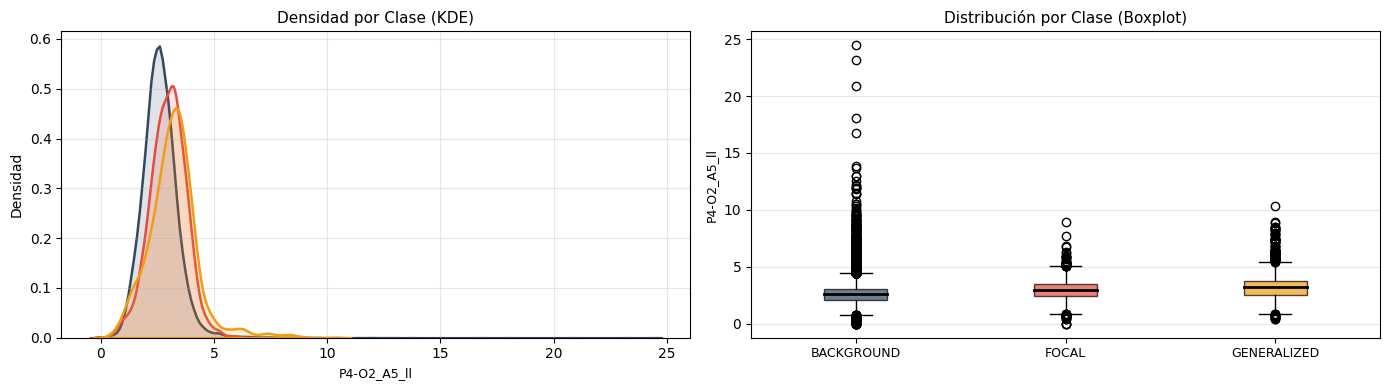

Estadístico (W),p-valor,Homocedástico,Interpretación
113.905500,< 0.001 (ε),No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.2179,2.8608,39.1438,Unimodal · Cola derecha · Leptocúrtica
FOCAL,1,0.2226,0.1338,1.5704,Unimodal · Aproximadamente normal
GENERALIZED,1,0.3155,1.1409,4.2916,Unimodal · Cola derecha · Leptocúrtica


Clase,Mejor distribución
BACKGROUND,Burr
FOCAL,Burr
GENERALIZED,Burr


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,766,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,28,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,69,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('P4-O2_A5_ll')

:::class: note
El análisis descriptivo y morfológico de la variable revela diferencias claras entre las tres clases del problema de clasificación: **BACKGROUND**, **FOCAL** y **GENERALIZED**. En todos los casos, la distribución es unimodal, es decir, la mayor parte de las observaciones se concentran en torno a un único valor central.

Para la clase **BACKGROUND**, los valores indican una asimetría positiva marcada. La curtosis (**39.1438**) es extremadamente alta, lo que señala una distribución leptocúrtica, con un pico muy pronunciado y colas pesadas. El coeficiente de bimodalidad confirma la unimodalidad. Esto sugiere que la mayoría de los valores son bajos, pero existen algunos eventos con valores mucho mayores, lo cual puede estar relacionado con episodios neuronales intensos dentro de la actividad basal.

En la clase **FOCAL**, el rango de valores es de **0.0000 a 8.9259**, con una media de **2.9695** y desviación estándar de **0.8163**. La mediana (**2.9894**) prácticamente coincide con la media, y el coeficiente de asimetría (**0.1338**) es cercano a cero, lo que indica una distribución aproximadamente simétrica. La curtosis (**1.5704**) sugiere una morfología cercana a la mesocúrtica, es decir, similar a la normal. El coeficiente de bimodalidad también confirma la estructura unimodal. Esto indica que, en crisis focales, los valores tienden a concentrarse de manera estable alrededor del centro, con menor presencia de valores extremos respecto a las otras clases.

Para la clase **GENERALIZED**, los valores van de **0.4164 a 10.3272**, con una media de **3.1995** y desviación estándar de **1.1165**. La mediana (**3.1987**) es prácticamente igual a la media, lo que sugiere estabilidad en la tendencia central. Sin embargo, el coeficiente de asimetría (**1.1409**) refleja una asimetría positiva moderada y la curtosis (**4.2916**) indica una distribución leptocúrtica. El coeficiente de bimodalidad confirma la unimodalidad. Aunque la mayoría de los valores se concentra alrededor del centro, hay eventos con amplitudes mayores asociados a actividad epileptiforme generalizada.

Respecto al ajuste de distribuciones teóricas, la distribución **Burr** es la que mejor se adapta a los datos en las tres clases, lo cual es indicativo de colas pesadas y asimetría marcada, un patrón habitual en fenómenos naturales con eventos raros de gran magnitud, como sucede en señales EEG.

Finalmente, el análisis de valores atípicos mediante el método de **Hampel** y la corrección de **Holm** muestra la presencia de outliers estadísticamente significativos en las tres clases: **766 en BACKGROUND**, **28 en FOCAL** y **69 en GENERALIZED**. Lejos de ser errores, estos valores representan eventos epilépticos clínicamente relevantes, pues reflejan variaciones abruptas en la actividad eléctrica cerebral asociadas a crisis o actividad epileptiforme.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[-1.4763 – 255.7025],2.2004 (12.4444),0.1955 (0.8954),14.5847,260.0501,Asimetría positiva · Leptocúrtica
FOCAL,[-1.4607 – 147.5745],1.8854 (8.5140),0.3592 (1.1263),10.9453,139.4969,Asimetría positiva · Leptocúrtica
GENERALIZED,[-0.6243 – 110.4782],4.3477 (9.0072),0.9043 (4.5752),4.8991,34.3779,Asimetría positiva · Leptocúrtica


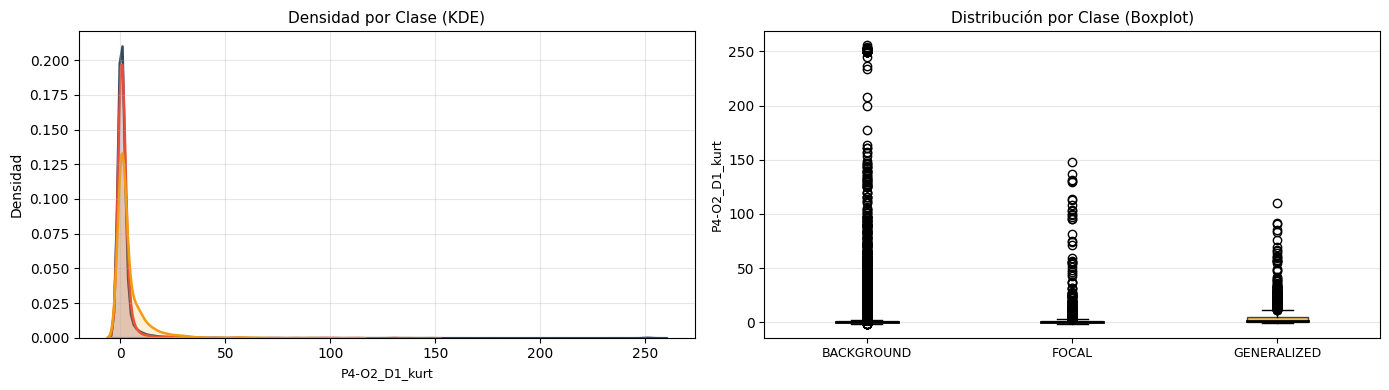

Estadístico (W),p-valor,Homocedástico,Interpretación
26.112200,< 0.001 (ε),No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.8124,14.5847,260.0501,Bimodal
FOCAL,1,0.8477,10.9453,139.4969,Bimodal
GENERALIZED,1,0.6688,4.8991,34.3779,Bimodal


Clase,Mejor distribución
BACKGROUND,Log-Normal
FOCAL,Log-Normal
GENERALIZED,Log-Normal


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,6756,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,547,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,511,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('P4-O2_D1_kurt')

:::class: note
El análisis morfológico de la variable **P4-O2_D1_kurt** revela un comportamiento estadístico notablemente diferente al de otras variables más estables de la señal. En las tres clases se observa una **asimetría positiva extremadamente alta** y valores de **curtosis muy elevados**, señalando distribuciones con colas pesadas y una fuerte presencia de valores extremos.

A diferencia de otras variables analizadas, el coeficiente de bimodalidad apunta a una **estructura bimodal** en las tres clases. Esto puede interpretarse como la coexistencia de dos patrones distintos en la señal: uno asociado a la **actividad cerebral basal** y otro vinculado a episodios de **mayor intensidad neuronal**. En el contexto de señales EEG, este comportamiento suele reflejar transiciones entre estados fisiológicos normales y episodios epileptiformes.

El estudio del ajuste de distribuciones muestra que la variable se ajusta mejor a una **distribución log-normal**, lo que es coherente con fenómenos donde los valores positivos pueden crecer de forma multiplicativa y exhibir alta variabilidad. Este tipo de distribución es común en variables de señales biomédicas, especialmente cuando la magnitud de la señal puede amplificarse abruptamente en presencia de eventos patológicos.

Además, el análisis de valores atípicos mediante el método de **Hampel** y la corrección de **Holm** identifica una cantidad significativa de observaciones extremas en todas las clases. Estos valores no deben considerarse ruido o errores de medición, sino posibles señales de **cambios abruptos en la actividad cerebral**. La alta frecuencia de outliers sugiere que esta variable es especialmente sensible a episodios de alta energía en la señal EEG, lo que la convierte en un descriptor potencialmente útil para la detección de crisis epilépticas.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,"[0.0000 – 1,790.9092]",2.4165 (14.0717),1.4587 (1.8956),82.9422,8698.8826,Asimetría positiva · Leptocúrtica
FOCAL,"[0.0000 – 1,348.7640]",2.9526 (22.9319),1.9352 (2.0699),53.7617,3108.4620,Asimetría positiva · Leptocúrtica
GENERALIZED,[0.0260 – 58.9413],3.6346 (4.4977),2.5815 (2.8680),5.1856,39.3208,Asimetría positiva · Leptocúrtica


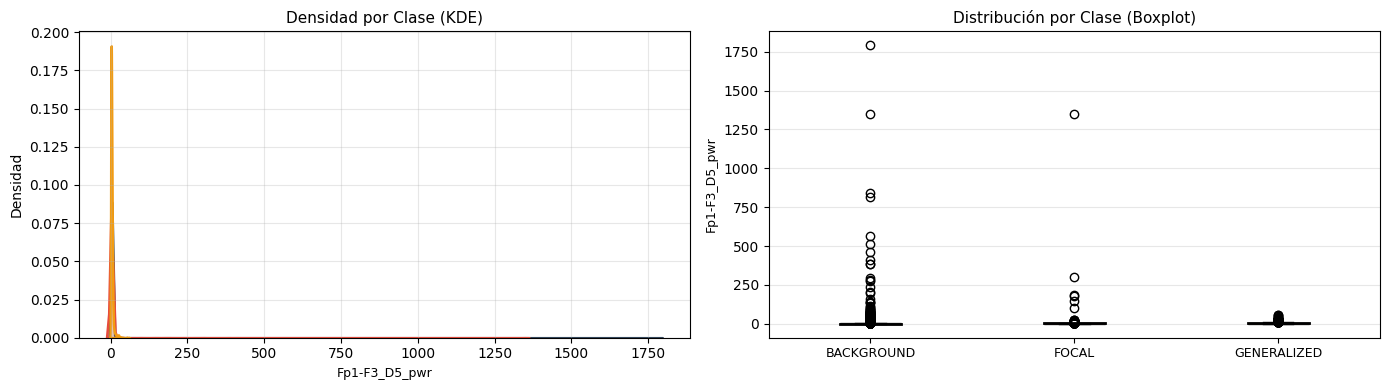

Estadístico (W),p-valor,Homocedástico,Interpretación
1.843000,0.1584,Si — Varianzas homogéneas,No hay evidencia de diferencias en varianzas entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.7907,82.9422,8698.8826,Bimodal
FOCAL,1,0.9292,53.7617,3108.4620,Bimodal
GENERALIZED,1,0.6590,5.1856,39.3208,Bimodal


Clase,Mejor distribución
BACKGROUND,Burr
FOCAL,Burr
GENERALIZED,Burr


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,2836,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,136,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,116,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Fp1-F3_D5_pwr')

:::class: note
El análisis morfológico de la variable **Fp1-F3_D5_pwr** muestra un comportamiento estadístico claramente **no normal** en las tres clases estudiadas. Se observa una **asimetría positiva muy marcada** y valores de **curtosis elevados**, lo que indica distribuciones con colas largas y una fuerte presencia de valores extremos. Esto significa que la mayoría de las observaciones se agrupan en valores bajos, pero existen algunos eventos que alcanzan magnitudes mucho mayores.

El coeficiente de bimodalidad señala la existencia de una **estructura bimodal** en las tres clases, lo que sugiere la alternancia entre dos regímenes de comportamiento en la señal. En registros EEG, este patrón puede interpretarse como el paso entre estados de **actividad cerebral basal** y episodios de **mayor intensidad eléctrica**, típicos de eventos epileptiformes.

El ajuste de distribuciones revela que la variable se aproxima mejor a una **distribución de tipo Burr**, conocida por su capacidad para modelar datos con **colas pesadas** y alta variabilidad. Este tipo de distribución es habitual en señales biomédicas donde pueden darse eventos poco frecuentes pero de gran magnitud.

Por último, la detección de valores atípicos mediante el método de **Hampel** y la corrección de **Holm** confirma la presencia de observaciones extremas estadísticamente significativas en todas las clases. Estos valores no deben considerarse ruido, sino posibles señales de **cambios abruptos en la actividad eléctrica cerebral**. Su presencia indica que la variable **Fp1-F3_D5_pwr** es especialmente sensible a variaciones de alta energía en la señal EEG, lo que puede ser muy útil para identificar y caracterizar crisis epilépticas.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,"[-215,718.4844 – 43,000.3711]","-1.9303 (1,205.8221)",5.1495 (10.9289),-146.9660,25085.0697,Asimetría negativa · Leptocúrtica
FOCAL,"[-39,617.3867 – 2,321.4387]",-6.7222 (654.5510),5.7807 (7.8763),-58.1038,3504.5506,Asimetría negativa · Leptocúrtica
GENERALIZED,"[-5,065.1460 – 8,837.3799]",4.0994 (266.5970),4.5498 (4.6519),11.3592,691.6486,Asimetría positiva · Leptocúrtica


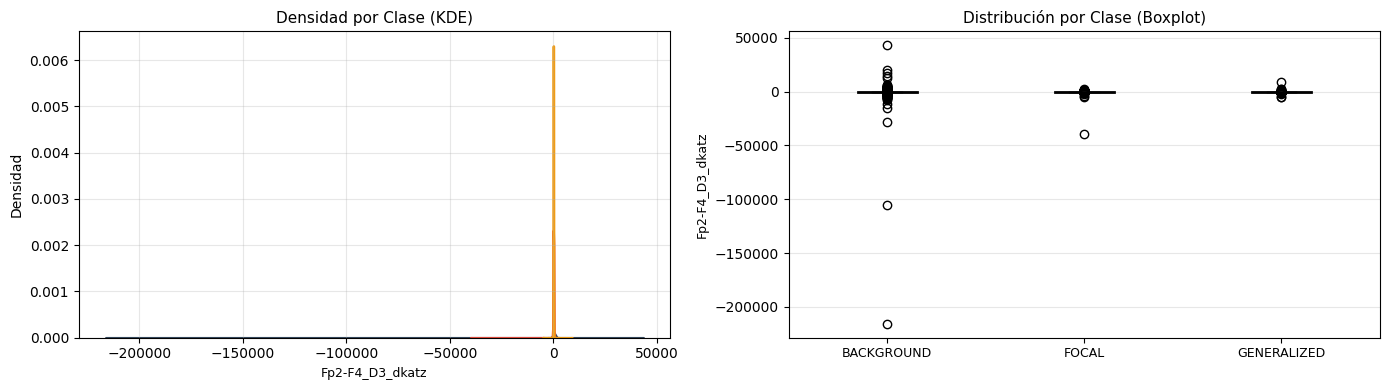

Estadístico (W),p-valor,Homocedástico,Interpretación
0.066000,0.9362,Si — Varianzas homogéneas,No hay evidencia de diferencias en varianzas entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.8610,-146.9660,25085.0697,Bimodal
FOCAL,1,0.9628,-58.1038,3504.5506,Bimodal
GENERALIZED,1,0.1872,11.3592,691.6486,Unimodal · Cola derecha · Leptocúrtica


Clase,Mejor distribución
BACKGROUND,Log-Normal
FOCAL,Log-Normal
GENERALIZED,Log-Normal


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,7792,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,771,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,507,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Fp2-F4_D3_dkatz')

:::class: note
El análisis morfológico de la variable **Fp2-F4_D3_dkatz** muestra un comportamiento estadístico altamente irregular entre las diferentes clases clínicas. En las clases **BACKGROUND** y **FOCAL** se observa una **asimetría negativa muy marcada** y valores de **curtosis elevados**, lo que indica distribuciones con colas pesadas hacia la izquierda y una fuerte presencia de valores extremos. Esto sugiere que, aunque la mayoría de los valores se concentran cerca del centro, existen eventos de gran magnitud en la cola izquierda de la distribución. Por el contrario, la clase **GENERALIZED** presenta una **asimetría positiva clara** y una estructura unimodal con cola derecha, mostrando un patrón estadístico diferente respecto a las otras clases.

La dirección opuesta de la asimetría entre clases apunta a que la dinámica de la señal EEG varía significativamente según el tipo de actividad epiléptica, reflejando **patrones de complejidad distintos** en la señal. Además, el análisis de bimodalidad revela que **BACKGROUND** y **FOCAL** tienen una **estructura bimodal**, lo que sugiere la coexistencia de distintos regímenes de actividad, posiblemente asociados a transiciones entre estados basales y episodios de mayor complejidad neuronal.

El ajuste de distribuciones indica que la variable se aproxima mejor a una **distribución log-normal** en todas las clases, lo cual es coherente con fenómenos que presentan alta variabilidad y eventos extremos.

El análisis de outliers mediante el método de **Hampel** y la corrección de **Holm** confirma la existencia de numerosos valores extremos estadísticamente significativos en todas las clases. Estos valores se interpretan como eventos de interés fisiológico, reflejando cambios abruptos en la dinámica de la señal EEG y potencialmente asociados a episodios epileptiformes.

 Lo que realmente hace interesante a esta feature es que mide la **complejidad de la señal (Katz fractal dimension)**, presenta **asimetría opuesta entre clases** y contiene numerosos **outliers informativos**. El cambio de dirección en la asimetría con colas izquierdas en **BACKGROUND** y **FOCAL**, y cola derecha en **GENERALIZED** sugiere que la complejidad de la señal varía de forma distinta según el tipo de crisis. Este comportamiento diferencial suele ser muy útil para la **clasificación multiclase en EEG**.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[-8.4692 – 8.3472],-0.0096 (0.3598),-0.0050 (0.0552),-3.9215,423.2469,Asimetría negativa · Leptocúrtica
FOCAL,[-2.2439 – 2.8415],-0.0055 (0.1618),-0.0065 (0.0713),1.6331,78.4324,Asimetría positiva · Leptocúrtica
GENERALIZED,[-2.7631 – 1.7352],-0.0425 (0.2600),-0.0173 (0.1050),-1.7962,20.8857,Asimetría negativa · Leptocúrtica


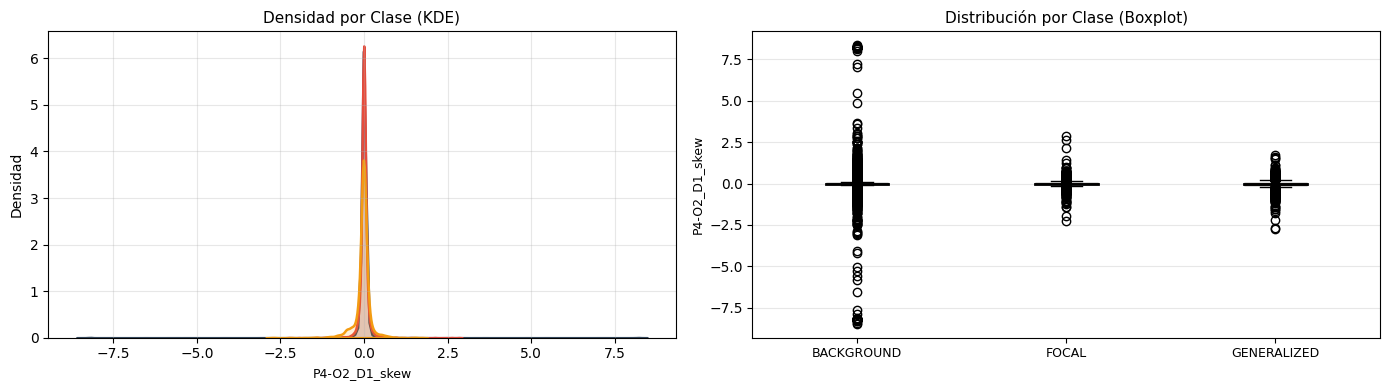

Estadístico (W),p-valor,Homocedástico,Interpretación
37.664100,< 0.001 (ε),No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.0384,-3.9215,423.2469,Unimodal · Cola izquierda · Leptocúrtica
FOCAL,1,0.0450,1.6331,78.4324,Unimodal · Cola derecha · Leptocúrtica
GENERALIZED,1,0.1769,-1.7962,20.8857,Unimodal · Cola izquierda · Leptocúrtica


Clase,Mejor distribución
BACKGROUND,Log-Normal
FOCAL,Cauchy
GENERALIZED,Cauchy


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,3074,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,383,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,340,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('P4-O2_D1_skew')

:::class: note
El análisis de la variable **P4-O2_D1_skew**, que mide la **asimetría de la señal EEG**, muestra distribuciones **unimodales** en las tres clases, pero con diferencias notables en la dirección de las colas. Las clases **BACKGROUND** y **GENERALIZED** presentan **asimetría negativa**, mientras que **FOCAL** exhibe **asimetría positiva**, lo que indica que la forma de la distribución varía según el tipo de actividad cerebral.

En todos los casos se observa un comportamiento **leptocúrtico**, caracterizado por colas largas y la presencia de valores extremos. Esto es coherente con la alta variabilidad de las señales EEG, donde la mayoría de las observaciones se agrupan cerca del centro, pero pueden ocurrir episodios con desviaciones considerables debido a cambios abruptos en la dinámica de la señal.

El ajuste de distribuciones pone de manifiesto diferencias estadísticas entre clases: **BACKGROUND** se ajusta mejor a una **distribución log-normal**, mientras que **FOCAL** y **GENERALIZED** encajan mejor con distribuciones tipo **Cauchy**, conocidas por sus colas extremadamente pesadas. Esto apunta a la existencia de eventos raros pero de gran magnitud en la señal, especialmente en las clases asociadas a actividad epiléptica.

Por último, el análisis de valores atípicos mediante el método de **Hampel** y la corrección de **Holm** detecta observaciones extremas estadísticamente significativas en todas las clases. Estos valores no deben verse como anomalías o errores, sino como eventos potencialmente informativos desde el punto de vista fisiológico, ya que pueden corresponder a alteraciones abruptas en la actividad eléctrica cerebral relacionadas con episodios epilépticos.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[0.0000 – 8.9997],0.1257 (0.1438),0.0899 (0.1004),10.8689,411.3032,Asimetría positiva · Leptocúrtica
FOCAL,[0.0000 – 1.1978],0.0951 (0.1007),0.0664 (0.0679),3.9092,22.2930,Asimetría positiva · Leptocúrtica
GENERALIZED,[0.0053 – 1.5315],0.1232 (0.1582),0.0703 (0.0950),3.5921,17.1547,Asimetría positiva · Leptocúrtica


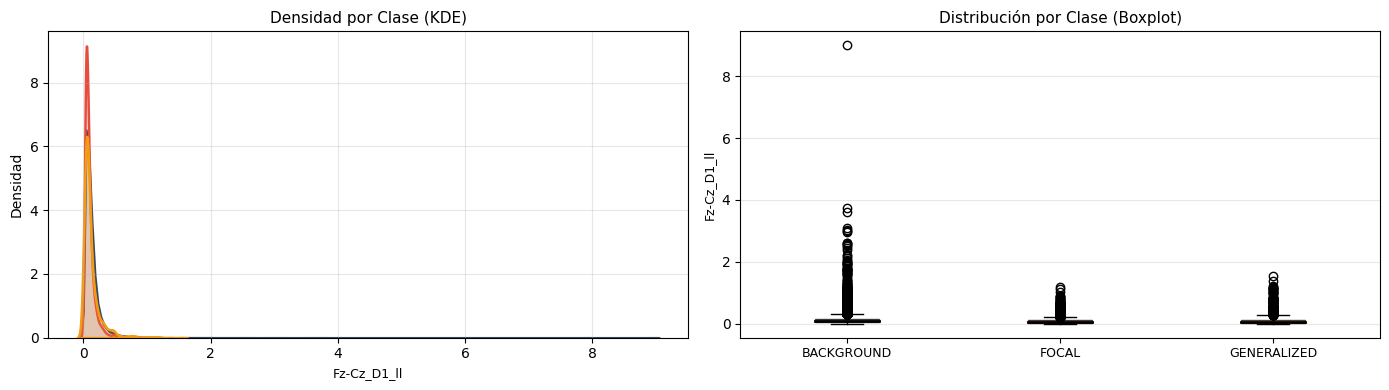

Estadístico (W),p-valor,Homocedástico,Interpretación
50.070600,< 0.001 (ε),No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.2875,10.8689,411.3032,Unimodal · Cola derecha · Leptocúrtica
FOCAL,1,0.6437,3.9092,22.2930,Bimodal
GENERALIZED,1,0.6897,3.5921,17.1547,Bimodal


Clase,Mejor distribución
BACKGROUND,Log-Normal
FOCAL,Burr
GENERALIZED,Burr


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,42155,3067,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3782,335,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2058,250,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Fz-Cz_D1_ll')

:::class: note
El análisis de la variable **Fz-Cz_D1_ll**, relacionada con la **longitud de línea de la señal EEG**, muestra un comportamiento estadístico con **marcada asimetría positiva** y **colas pesadas** en las tres clases estudiadas. Esto indica que la mayoría de las observaciones se sitúan en valores bajos, pero existen episodios que alcanzan magnitudes considerablemente mayores, reflejando la presencia de eventos de alta variabilidad en la señal.

Desde un punto de vista morfológico, la clase **BACKGROUND** presenta una **estructura unimodal** con una cola derecha pronunciada, lo que apunta a una actividad relativamente estable centrada en un solo régimen de comportamiento. En cambio, las clases **FOCAL** y **GENERALIZED** exhiben una **estructura bimodal**, señalando la coexistencia de distintos patrones de actividad. Este fenómeno puede interpretarse como la alternancia entre estados de **actividad basal** y episodios eléctricos de mayor intensidad propios de eventos epilépticos.

El análisis de ajuste de distribuciones indica que la clase **BACKGROUND** se adapta mejor a una **distribución log-normal**, mientras que **FOCAL** y **GENERALIZED** encajan mejor con distribuciones **Burr**, conocidas por modelar datos con **colas pesadas** y alta variabilidad.

Por último, la detección de valores atípicos usando el método de **Hampel** y la corrección de **Holm** confirma la existencia de observaciones extremas estadísticamente significativas en todas las clases. Estos valores extremos deben interpretarse como **eventos informativos desde la perspectiva fisiológica**, ya que reflejan cambios abruptos en la actividad eléctrica cerebral potencialmente asociados a episodios epilépticos.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[0.0000 – 839.8881],0.9825 (8.3708),0.5142 (0.6916),63.4586,4842.9920,Asimetría positiva · Leptocúrtica
FOCAL,[0.0000 – 93.1885],0.9236 (2.1278),0.6204 (0.7682),32.5963,1303.9567,Asimetría positiva · Leptocúrtica
GENERALIZED,[0.0162 – 88.2366],1.7521 (4.3120),0.8574 (1.2863),10.4417,143.9980,Asimetría positiva · Leptocúrtica


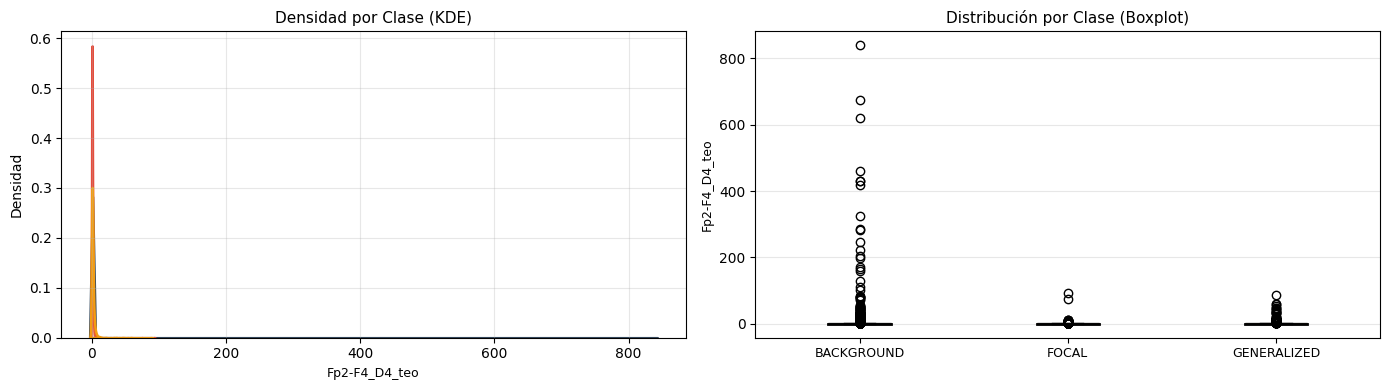

Estadístico (W),p-valor,Homocedástico,Interpretación
6.755800,0.0012,No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.8312,63.4586,4842.9920,Bimodal
FOCAL,1,0.8137,32.5963,1303.9567,Bimodal
GENERALIZED,1,0.7485,10.4417,143.9980,Bimodal


Clase,Mejor distribución
BACKGROUND,Burr
FOCAL,Burr
GENERALIZED,Burr


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,3240,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,268,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,236,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Fp2-F4_D4_teo')

:::class: note
El análisis morfológico de la variable revela distribuciones **fuertemente asimétricas hacia la derecha** y valores de **curtosis extremadamente elevados** en las tres clases. Esto indica la presencia de **colas pesadas** y una alta concentración de observaciones en valores bajos, mientras que un número reducido de eventos alcanza magnitudes mucho mayores. Este patrón es característico de las señales EEG, donde es común la aparición ocasional de episodios de alta intensidad eléctrica.

Desde el punto de vista estructural, el coeficiente de bimodalidad sugiere una **estructura bimodal** en todas las clases, lo que refleja la coexistencia de distintos regímenes de comportamiento en la señal. En el contexto de EEG, esto puede interpretarse como la alternancia entre estados de **actividad basal** y episodios de **mayor intensidad eléctrica** asociados a eventos epileptiformes.

El análisis de ajuste de distribuciones indica que las tres clases se ajustan mejor a una **distribución de tipo Burr**, especialmente adecuada para modelar datos con **alta variabilidad** y presencia de eventos extremos. Este hallazgo refuerza la idea de que la variable es capaz de captar fluctuaciones intensas en la dinámica de la señal.

Por último, la detección de valores atípicos mediante el método de **Hampel** y la corrección de **Holm** confirma la existencia de observaciones extremas estadísticamente significativas en todas las clases. Estos valores extremos no deben considerarse anomalías, sino **eventos potencialmente informativos desde el punto de vista fisiológico**, ya que reflejan cambios abruptos en la actividad eléctrica cerebral que pueden estar asociados a episodios epilépticos.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[0.0000 – 24.7202],1.7937 (0.7225),1.7166 (0.8108),3.0253,55.8833,Asimetría positiva · Leptocúrtica
FOCAL,[0.0000 – 5.3557],2.0113 (0.6530),1.9744 (0.8662),0.4214,0.5261,Simétrica · Mesocúrtica
GENERALIZED,[0.3872 – 6.7636],2.2613 (0.7847),2.1855 (1.0398),0.6236,1.2749,Asimetría positiva · Mesocúrtica


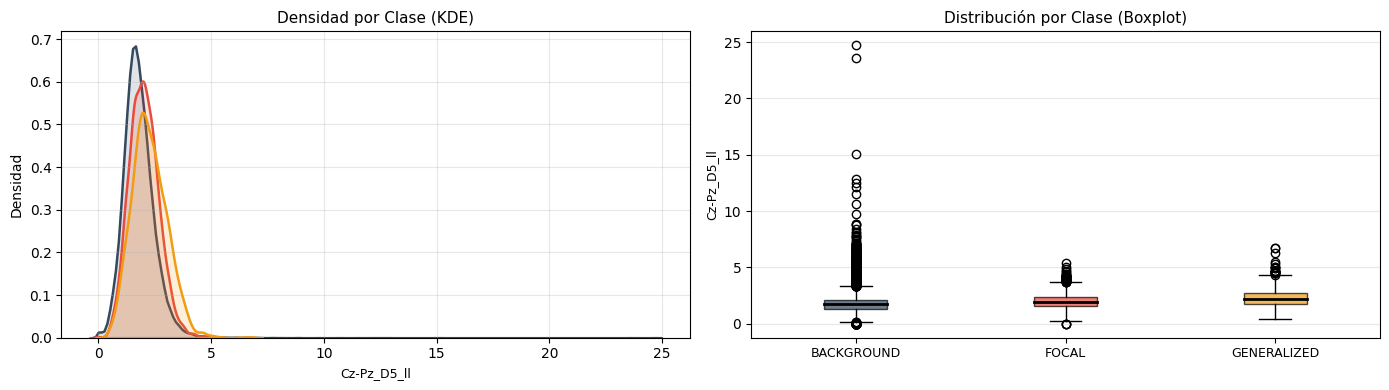

Estadístico (W),p-valor,Homocedástico,Interpretación
40.965300,< 0.001 (ε),No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.1724,3.0253,55.8833,Unimodal · Cola derecha · Leptocúrtica
FOCAL,1,0.3337,0.4214,0.5261,Unimodal Simétrica
GENERALIZED,1,0.3246,0.6236,1.2749,Unimodal · Cola derecha


Clase,Mejor distribución
BACKGROUND,Burr
FOCAL,Gamma
GENERALIZED,Inverse Gaussian


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,42155,748,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3782,25,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2058,20,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Cz-Pz_D5_ll')

:::class: note
El análisis morfológico de la variable muestra **diferencias estructurales marcadas entre las clases**. En la clase **BACKGROUND** se observa una distribución claramente **asimétrica hacia la derecha** y altamente **leptocúrtica**, lo que señala una fuerte concentración de valores alrededor del centro, pero con la presencia ocasional de eventos extremos poco frecuentes. Este patrón sugiere que durante la actividad basal, la señal EEG es relativamente estable, aunque puede registrar incrementos abruptos de magnitud.

La clase **FOCAL** presenta una distribución prácticamente **simétrica** y **mesocúrtica**, es decir, con un comportamiento más regular y cercano a la normalidad. Esto indica que en episodios focales, la variable fluctúa de forma más equilibrada cerca del valor central y muestra menos eventos extremos.

Por otro lado, la clase **GENERALIZED** mantiene una **ligera asimetría positiva** y **curtosis moderada**, lo que corresponde a una distribución relativamente estable pero con cierta tendencia a valores altos ocasionales. Este perfil se sitúa entre la estabilidad de la clase focal y la mayor variabilidad de la actividad basal.

Desde una perspectiva de modelado estadístico, el mejor ajuste de distribuciones difiere según la clase: **BACKGROUND** se aproxima a una **distribución Burr**, **FOCAL** encaja mejor con una **distribución Gamma**, y **GENERALIZED** con una **Inverse Gaussian**, ambas propias de variables positivas y asimetría moderada.

Finalmente, la detección de outliers mediante el método de **Hampel** con corrección de **Holm** revela observaciones extremas estadísticamente significativas en todas las clases, especialmente en la actividad basal. Estos valores extremos pueden interpretarse como episodios de **actividad eléctrica inusual**, potencialmente relacionados con eventos epilépticos o transiciones entre estados cerebrales.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[-8.4436 – 8.3066],-0.0166 (0.3499),-0.0114 (0.0566),-1.8806,452.2710,Asimetría negativa · Leptocúrtica
FOCAL,[-1.7943 – 2.6422],-0.0157 (0.1300),-0.0178 (0.0682),2.4562,89.2084,Asimetría positiva · Leptocúrtica
GENERALIZED,[-2.8284 – 1.3149],-0.0334 (0.2467),-0.0225 (0.0913),-1.6032,21.1487,Asimetría negativa · Leptocúrtica


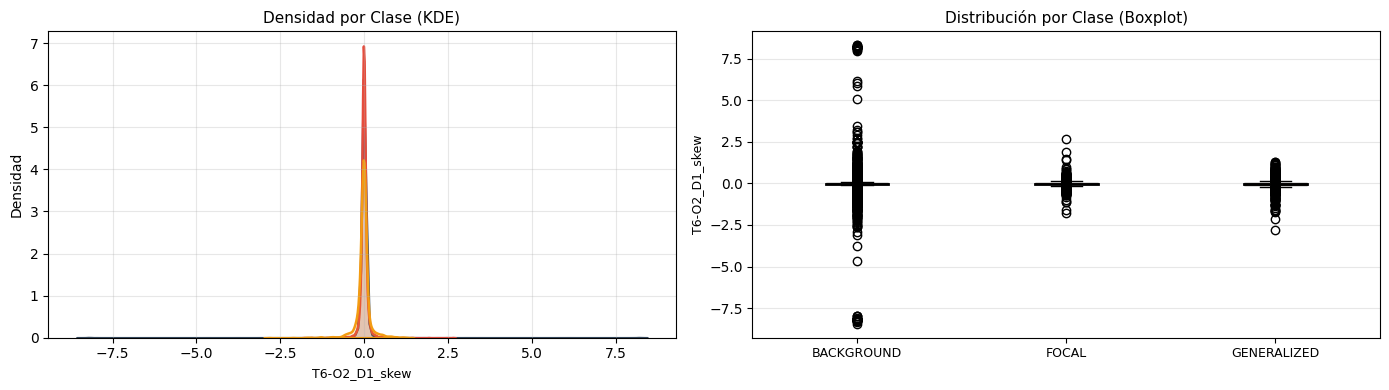

Estadístico (W),p-valor,Homocedástico,Interpretación
26.468300,< 0.001 (ε),No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.0100,-1.8806,452.2710,Unimodal · Cola izquierda · Leptocúrtica
FOCAL,1,0.0763,2.4562,89.2084,Unimodal · Cola derecha · Leptocúrtica
GENERALIZED,1,0.1478,-1.6032,21.1487,Unimodal · Cola izquierda · Leptocúrtica


Clase,Mejor distribución
BACKGROUND,Log-Normal
FOCAL,Cauchy
GENERALIZED,Cauchy


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,3127,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,304,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,332,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('T6-O2_D1_skew')

:::class: note
El análisis de la variable **T6-O2_D1_skew**, que mide la **asimetría de la señal EEG**, evidencia diferencias claras en la dirección de las colas entre las clases. Las clases **BACKGROUND** y **GENERALIZED** presentan una **asimetría negativa**, lo que indica la presencia de valores extremos hacia la izquierda, mientras que la clase **FOCAL** exhibe una **asimetría positiva**, con eventos extremos hacia la derecha. Este comportamiento sugiere que la dinámica de la señal varía según el tipo de actividad cerebral.

En las tres clases se observa un comportamiento **altamente leptocúrtico**, especialmente en **BACKGROUND**, donde la curtosis alcanza valores extremadamente elevados, lo que refleja una fuerte concentración de observaciones alrededor del centro y la presencia de colas pesadas. Este patrón es característico de señales EEG, donde predominan valores cercanos al promedio, pero pueden ocurrir desviaciones abruptas asociadas a cambios en la actividad neuronal.

Desde el punto de vista estructural, el coeficiente de bimodalidad indica que las tres clases presentan una **estructura unimodal**, lo que sugiere un único régimen dominante de comportamiento en la señal, aunque con diferencias importantes en la dispersión y en la dirección de los extremos.

El análisis de homocedasticidad mediante el test de **Brown-Forsythe** indica que las varianzas **difieren significativamente entre clases**, lo que confirma la presencia de heterogeneidad en la variabilidad de la señal según el tipo de actividad cerebral.

En cuanto al ajuste de distribuciones, la clase **BACKGROUND** se aproxima mejor a una **distribución log-normal**, mientras que las clases **FOCAL** y **GENERALIZED** se ajustan mejor a distribuciones tipo **Cauchy**, conocidas por sus colas extremadamente pesadas. Esto sugiere la presencia de eventos raros pero de gran magnitud, especialmente en las clases asociadas a actividad epiléptica.

Finalmente, el análisis de valores atípicos mediante el método de **Hampel** y la corrección de **Holm** revela una cantidad considerable de observaciones extremas estadísticamente significativas en todas las clases (**3127 en BACKGROUND, 304 en FOCAL y 332 en GENERALIZED**). Estos valores no deben interpretarse como ruido, sino como **eventos epilépticos relevantes**, ya que reflejan cambios abruptos en la actividad eléctrica cerebral y aportan información clave para la clasificación de los distintos tipos de crisis.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[-8.4831 – 8.4785],-0.0043 (0.3662),-0.0023 (0.0574),-0.0320,396.7675,Simétrica · Leptocúrtica
FOCAL,[-2.2102 – 2.5252],-0.0136 (0.1711),-0.0029 (0.0739),-1.2415,66.9182,Asimetría negativa · Leptocúrtica
GENERALIZED,[-2.2561 – 3.1547],-0.0552 (0.2679),-0.0170 (0.1167),-0.2215,22.8520,Simétrica · Leptocúrtica


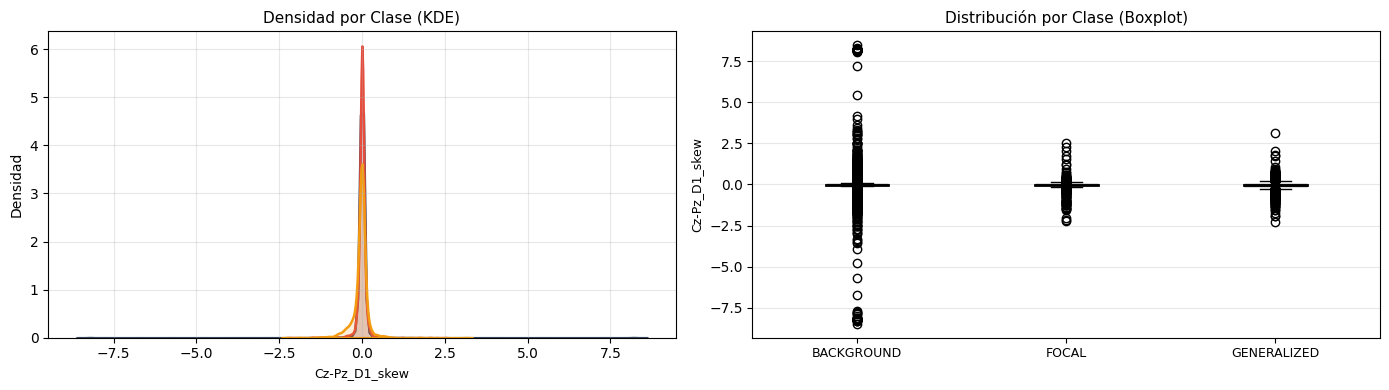

Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.0025,-0.0320,396.7675,Unimodal · Leptocúrtica
FOCAL,1,0.0363,-1.2415,66.9182,Unimodal · Cola izquierda · Leptocúrtica
GENERALIZED,1,0.0406,-0.2215,22.8520,Unimodal · Leptocúrtica


Clase,Mejor distribución
BACKGROUND,Log-Normal
FOCAL,Log-Normal
GENERALIZED,Log-Normal


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,42155,3132,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3782,281,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2058,330,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Cz-Pz_D1_skew')

:::class: note
El análisis morfológico muestra que la variable presenta distribuciones **mayormente simétricas** y **unimodales** en las tres clases, lo que apunta a una estructura relativamente estable alrededor de un valor central. Sin embargo, los valores de **curtosis muy elevados** indican que las distribuciones son fuertemente **leptocúrticas**, es decir, concentran la mayoría de las observaciones cerca del centro pero presentan colas pesadas.

En la clase **BACKGROUND**, la distribución se mantiene casi perfectamente **simétrica**, lo que sugiere que las fluctuaciones de la señal están equilibradas alrededor del valor medio. Aun así, la alta curtosis señala la existencia de **eventos extremos** que generan picos pronunciados en la distribución.

La clase **FOCAL** muestra una **leve asimetría negativa**, indicando una mayor presencia de valores extremos hacia la cola izquierda. Este patrón puede reflejar episodios donde la señal desciende abruptamente desde el nivel basal, posiblemente asociado a cambios localizados en la actividad cerebral.

Por su parte, la clase **GENERALIZED** mantiene una estructura cercana a la **simetría**, aunque con cierta tendencia a valores negativos extremos, lo que implica una dinámica estable pero con variaciones ocasionales que amplían las colas de la distribución.

En cuanto al ajuste de modelos, la mejor aproximación para las tres clases es la **distribución Log-Normal**, característica de variables con colas pesadas y acumulación central. Esto sugiere que la variable es sensible a **variaciones multiplicativas o cambios de escala** en la señal EEG.

Finalmente, la detección de valores atípicos mediante el método de **Hampel** y la corrección de **Holm** confirma la existencia de eventos extremos estadísticamente significativos en todas las clases. Estos outliers pueden corresponder a **episodios inusuales en la actividad eléctrica cerebral**, como transiciones de estado o eventos epilépticos.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,"[0.0000 – 1,230.4335]",2.1343 (8.5372),1.3509 (1.7911),90.7263,11260.0529,Asimetría positiva · Leptocúrtica
FOCAL,[0.0000 – 31.9763],2.2911 (2.0164),1.7806 (2.0201),3.5007,26.3262,Asimetría positiva · Leptocúrtica
GENERALIZED,[0.0321 – 52.8651],3.0007 (3.2447),2.3785 (2.3704),6.2189,62.7743,Asimetría positiva · Leptocúrtica


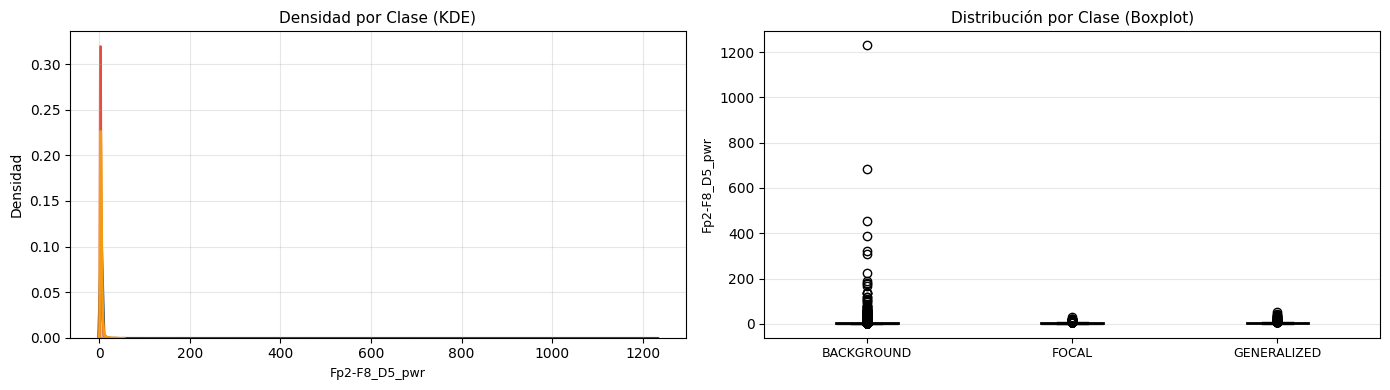

Estadístico (W),p-valor,Homocedástico,Interpretación
1.694500,0.1837,Si — Varianzas homogéneas,No hay evidencia de diferencias en varianzas entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.7309,90.7263,11260.0529,Bimodal
FOCAL,1,0.4519,3.5007,26.3262,Unimodal · Cola derecha · Leptocúrtica
GENERALIZED,1,0.6032,6.2189,62.7743,Bimodal


Clase,Mejor distribución
BACKGROUND,Log-Normal
FOCAL,Log-Normal
GENERALIZED,Burr


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,2914,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,186,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,86,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Fp2-F8_D5_pwr')

:::class: note
El análisis de la variable revela distribuciones **fuertemente asimétricas hacia la derecha** y valores de **curtosis extremadamente altos** en las tres clases. Esto indica una alta concentración de observaciones en valores bajos, junto con la presencia de eventos de gran magnitud que generan colas largas en la distribución. En señales EEG, este patrón suele asociarse con episodios de **incrementos abruptos en la energía** de la señal.

En la clase **BACKGROUND** se observa una **estructura bimodal**, marcada por una **asimetría positiva muy pronunciada** y colas extremadamente pesadas. Esto sugiere la coexistencia de dos regímenes: uno **basal**, con valores bajos, y otro asociado a episodios de **alta intensidad** que generan valores extremos.

La clase **FOCAL** presenta una distribución **unimodal con cola derecha**, reflejando mayor estabilidad estructural en comparación con la actividad basal, aunque sigue habiendo picos de energía ocasionales. Este comportamiento es coherente con la naturaleza localizada de los episodios focales en el cerebro.

En **GENERALIZED**, la distribución vuelve a ser **bimodal**, lo que sugiere alternancia entre distintos niveles de actividad eléctrica durante las crisis generalizadas, reflejando cambios abruptos en la dinámica cerebral global.

Desde el punto de vista del modelado estadístico, las clases **BACKGROUND** y **FOCAL** se ajustan mejor a distribuciones **Log-Normal**, apropiadas para variables positivas con colas largas, mientras que **GENERALIZED** encaja mejor con una **distribución Burr**, adecuada para datos con mayor variabilidad y eventos extremos.

Por último, la detección de outliers mediante el método de **Hampel** y la corrección de **Holm** confirma la existencia de observaciones extremas estadísticamente significativas en todas las clases. Estos valores extremos representan **episodios de alta energía en la señal EEG** y pueden ser eventos informativos asociados a actividad epiléptica.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[0.0422 – 2.2719],1.7906 (0.2858),1.8728 (0.2039),-2.6102,8.5088,Asimetría negativa · Leptocúrtica
FOCAL,[0.1033 – 2.2489],1.7777 (0.2628),1.8485 (0.2205),-2.4790,8.6137,Asimetría negativa · Leptocúrtica
GENERALIZED,[0.1858 – 2.1432],1.5935 (0.3633),1.7129 (0.4971),-1.0366,0.3493,Asimetría negativa · Mesocúrtica


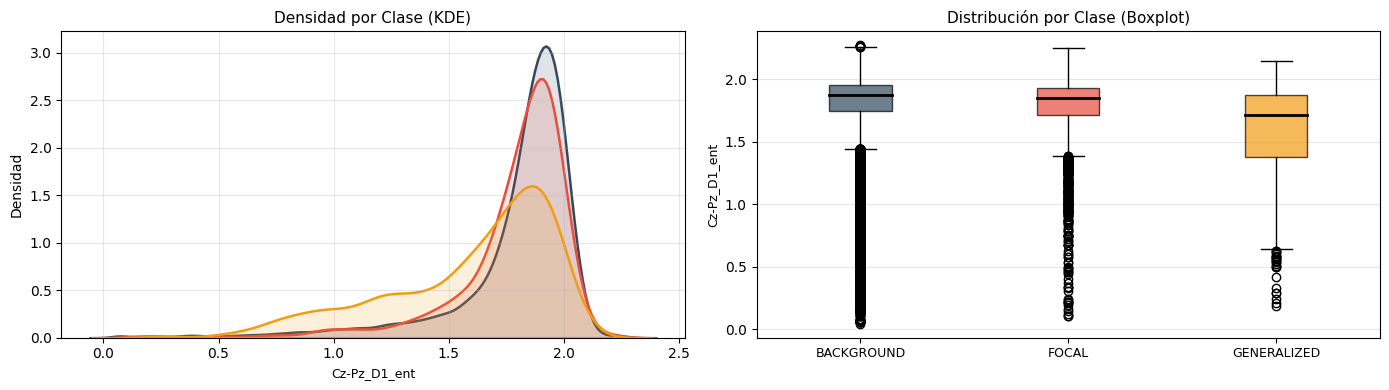

Estadístico (W),p-valor,Homocedástico,Interpretación
204.845400,< 0.001 (ε),No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.6789,-2.6102,8.5088,Bimodal
FOCAL,1,0.6151,-2.4790,8.6137,Bimodal
GENERALIZED,1,0.6186,-1.0366,0.3493,Bimodal


Clase,Mejor distribución
BACKGROUND,Log-Normal
FOCAL,Log-Normal
GENERALIZED,Burr


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,42155,4098,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3782,284,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2058,102,✅ No significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Cz-Pz_D1_ent')

:::class: note
El análisis de la variable muestra distribuciones mayormente **asimétricas hacia la izquierda** en las tres clases, lo que indica que la mayoría de las observaciones se sitúan en valores altos, mientras que los valores bajos son menos frecuentes. Este patrón sugiere que la señal mantiene **niveles elevados de la característica** durante gran parte del tiempo, con descensos ocasionales que generan la cola izquierda de la distribución.

Desde el punto de vista estructural, el coeficiente de bimodalidad indica una **estructura bimodal** en todas las clases, reflejando la coexistencia de diferentes regímenes de comportamiento en la señal. En el contexto del EEG, esto puede interpretarse como la alternancia entre estados de **mayor organización** y episodios donde la dinámica se modifica por actividad epiléptica o transiciones cerebrales.

Las clases **BACKGROUND** y **FOCAL** presentan una **curtosis elevada**, lo que denota colas pesadas y una mayor concentración de valores cerca del centro. En contraste, **GENERALIZED** muestra una curtosis más moderada, sugiriendo una distribución algo más dispersa y cercana al comportamiento **mesocúrtico**.

Desde una perspectiva de modelado, **BACKGROUND** y **FOCAL** se ajustan mejor a una **distribución Log-Normal**, típica de variables positivas asimétricas, mientras que **GENERALIZED** se aproxima mejor a una **distribución Burr**, capaz de capturar mayor variabilidad en la señal.

Finalmente, la detección de valores atípicos mediante el método de **Hampel** con corrección de **Holm** confirma la presencia de observaciones extremas estadísticamente significativas en **BACKGROUND** y **FOCAL**. Estos valores extremos pueden interpretarse como **episodios en los que la complejidad o irregularidad de la señal cambia abruptamente**, fenómeno que podría estar relacionado con eventos epilépticos o transiciones de estado cerebral.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[-8.3748 – 8.3436],0.0250 (0.3632),0.0140 (0.0595),2.5885,418.6090,Asimetría positiva · Leptocúrtica
FOCAL,[-1.4184 – 2.6437],0.0286 (0.1289),0.0183 (0.0640),4.8098,91.8952,Asimetría positiva · Leptocúrtica
GENERALIZED,[-2.1061 – 5.1835],0.1039 (0.3582),0.0291 (0.1266),3.0299,31.9551,Asimetría positiva · Leptocúrtica


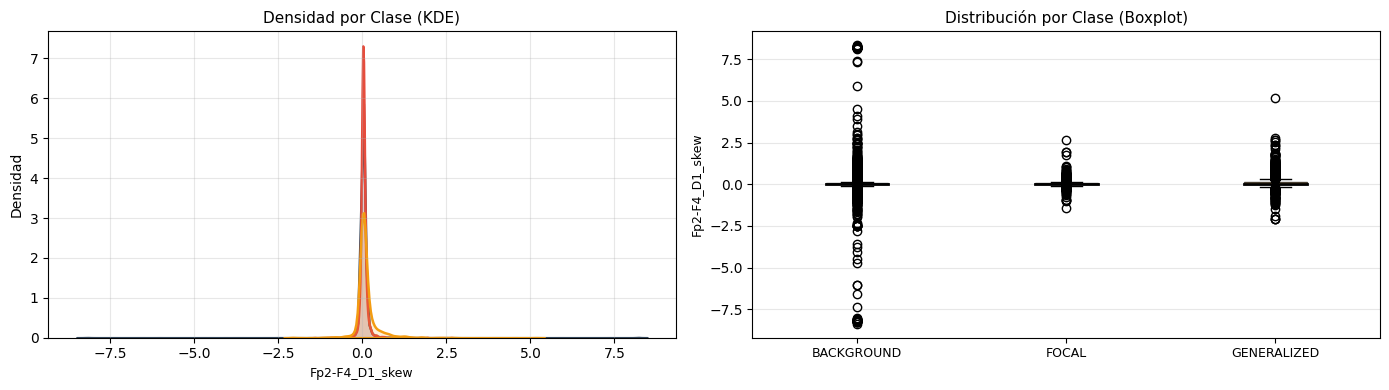

Estadístico (W),p-valor,Homocedástico,Interpretación
79.372000,< 0.001 (ε),No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.0183,2.5885,418.6090,Unimodal · Cola derecha · Leptocúrtica
FOCAL,1,0.2543,4.8098,91.8952,Unimodal · Cola derecha · Leptocúrtica
GENERALIZED,1,0.2912,3.0299,31.9551,Unimodal · Cola derecha · Leptocúrtica


Clase,Mejor distribución
BACKGROUND,Log-Normal
FOCAL,Log-Normal
GENERALIZED,Log-Normal


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,3535,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,319,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,385,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Fp2-F4_D1_skew')

:::class: note
El análisis de la variable muestra distribuciones claramente **asimétricas hacia la derecha** y niveles muy altos de **curtosis** en las tres clases. Esto indica que la mayoría de las observaciones se agrupan en valores bajos, mientras que un número reducido de eventos alcanza valores mucho más altos, generando **colas largas** en la distribución.

Desde el punto de vista estructural, todas las clases presentan una distribución **unimodal**, lo que sugiere la existencia de un **régimen predominante** en la dinámica de la señal. Sin embargo, la presencia de colas pesadas revela que pueden ocurrir episodios ocasionales de gran magnitud que alteran temporalmente el patrón usual de la variable.

En particular, la clase **FOCAL** exhibe una **asimetría positiva más pronunciada**, lo que sugiere una mayor probabilidad de observar valores extremos hacia la cola derecha durante episodios focales. Este comportamiento podría reflejar incrementos abruptos en la estructura o forma de la señal EEG, relacionados con actividad localizada en el cerebro.

La clase **GENERALIZED** mantiene la asimetría positiva, aunque con una **dispersión algo mayor**, lo que indica que los episodios de actividad eléctrica pueden generar variaciones más amplias en la dinámica global de la señal.

Desde una perspectiva estadística, el mejor ajuste para las tres clases es una **distribución Log-Normal**, típica de variables con colas largas y asimetría positiva. Este tipo de distribución es habitual en fenómenos donde los cambios en la señal se producen de forma **multiplicativa** o a través de incrementos abruptos.

Por último, la detección de outliers mediante el método de **Hampel** y la corrección de **Holm** confirma la existencia de observaciones extremas estadísticamente significativas en todas las clases. Estos valores extremos pueden interpretarse como **episodios donde la señal EEG experimenta cambios marcados**, potencialmente asociados a eventos epilépticos o transiciones entre diferentes estados de actividad cerebral.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[0.0000 – 958.4058],3.1336 (10.6511),2.3241 (2.3628),60.5932,4573.9648,Asimetría positiva · Leptocúrtica
FOCAL,[0.0000 – 63.4007],3.4003 (2.5557),2.9331 (2.3302),6.2439,100.9183,Asimetría positiva · Leptocúrtica
GENERALIZED,[0.0139 – 47.3062],3.8197 (3.3030),3.0530 (2.9224),3.9982,30.5797,Asimetría positiva · Leptocúrtica


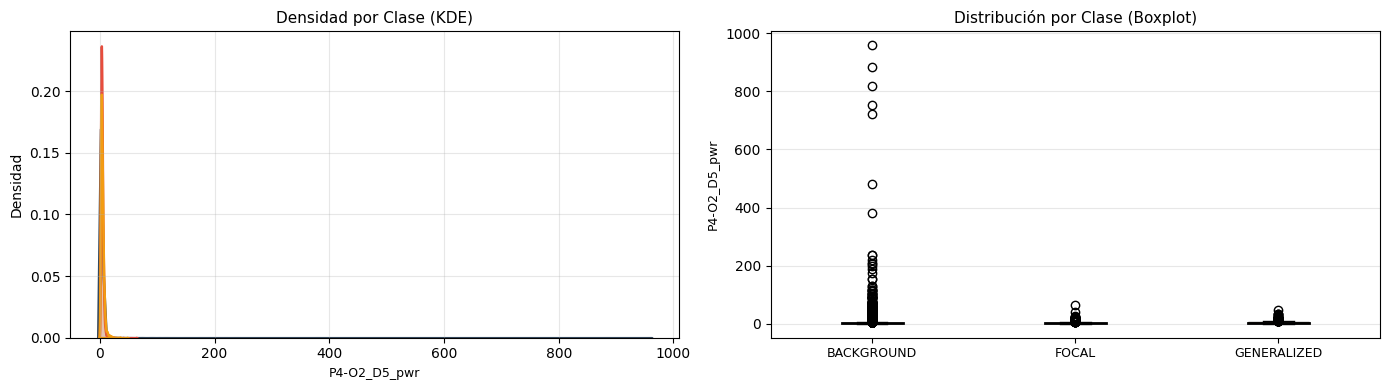

Estadístico (W),p-valor,Homocedástico,Interpretación
1.976700,0.1385,Si — Varianzas homogéneas,No hay evidencia de diferencias en varianzas entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.8024,60.5932,4573.9648,Bimodal
FOCAL,1,0.3848,6.2439,100.9183,Unimodal · Cola derecha · Leptocúrtica
GENERALIZED,1,0.5058,3.9982,30.5797,Unimodal · Cola derecha · Leptocúrtica


Clase,Mejor distribución
BACKGROUND,Burr
FOCAL,Burr
GENERALIZED,Burr


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,43239,1527,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3827,115,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2103,93,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('P4-O2_D5_pwr')

:::class: note
El análisis de la variable **P4-O2_D5_pwr** revela distribuciones fuertemente **asimétricas hacia la derecha** y niveles extremadamente altos de **curtosis** en las tres clases. Esto indica una alta concentración de observaciones en valores bajos, junto con la presencia de eventos de gran magnitud que generan **colas largas**, patrón característico de señales EEG donde ocurren incrementos abruptos en la energía.

Desde el punto de vista estructural, la clase **BACKGROUND** presenta una **estructura bimodal**, lo que sugiere la coexistencia de dos regímenes de comportamiento: uno asociado a la actividad basal con valores bajos y otro vinculado a episodios de **alta intensidad eléctrica** que generan valores extremos. En contraste, las clases **FOCAL** y **GENERALIZED** muestran una **estructura unimodal con cola derecha**, reflejando un régimen predominante pero con presencia de picos de energía ocasionales.

El análisis de homocedasticidad mediante el test de **Brown-Forsythe** indica que **no hay evidencia de diferencias significativas en las varianzas entre clases**, lo que sugiere una variabilidad comparable en la señal a pesar de las diferencias morfológicas observadas.

Desde una perspectiva de modelado estadístico, las tres clases se ajustan mejor a una **distribución de tipo Burr**, conocida por su capacidad para modelar datos con **colas pesadas** y alta variabilidad. Este resultado refuerza la idea de que la variable captura adecuadamente eventos extremos en la dinámica de la señal EEG.

Finalmente, la detección de valores atípicos mediante el método de **Hampel** y la corrección de **Holm** confirma la existencia de observaciones extremas estadísticamente significativas en todas las clases (**1527 en BACKGROUND, 115 en FOCAL y 93 en GENERALIZED**). Estos valores extremos representan **eventos epilépticos relevantes**, reflejando cambios abruptos en la actividad eléctrica cerebral y aportando información clave para la caracterización de la señal.
:::

Clase,Rango [Min–Max],Media (SD),Mediana (IQR),Skewness,Kurtosis,Morfología
BACKGROUND,[0.0000 – 7.4277],0.1228 (0.1407),0.0874 (0.0881),9.2004,247.3432,Asimetría positiva · Leptocúrtica
FOCAL,[0.0000 – 1.2211],0.0883 (0.0961),0.0603 (0.0579),4.2850,27.9330,Asimetría positiva · Leptocúrtica
GENERALIZED,[0.0050 – 1.5453],0.1143 (0.1602),0.0680 (0.0732),4.1880,21.8063,Asimetría positiva · Leptocúrtica


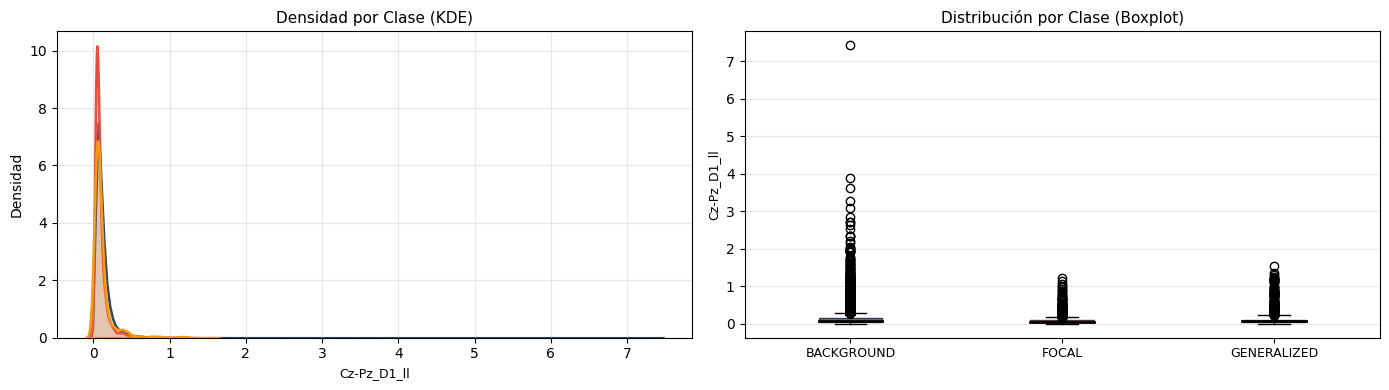

Estadístico (W),p-valor,Homocedástico,Interpretación
44.264700,< 0.001 (ε),No — Varianzas heterogéneas,Las varianzas difieren significativamente entre clases


Clase,N modas,BC,Skewness,Kurtosis,Tipo densidad
BACKGROUND,1,0.3421,9.2004,247.3432,Unimodal · Cola derecha · Leptocúrtica
FOCAL,1,0.6259,4.2850,27.9330,Bimodal
GENERALIZED,1,0.7472,4.1880,21.8063,Bimodal


Clase,Mejor distribución
BACKGROUND,Burr
FOCAL,Burr
GENERALIZED,Burr


Clase,N observaciones,N outliers (Hampel),Criterio Holm,Interpretación
BACKGROUND,42155,3219,⚠️ Significativo,🧠 Evento epiléptico relevante
FOCAL,3782,353,⚠️ Significativo,🧠 Evento epiléptico relevante
GENERALIZED,2058,231,⚠️ Significativo,🧠 Evento epiléptico relevante


In [ ]:
analisis_univariado('Cz-Pz_D1_ll')

:::class: note
El análisis de la variable muestra distribuciones **fuertemente asimétricas hacia la derecha** en las tres clases, acompañadas de valores elevados de **curtosis**. Este patrón indica que la mayoría de las observaciones se concentran en valores relativamente bajos, mientras que un número reducido de eventos presenta magnitudes considerablemente mayores, generando **colas largas** en la distribución. Este comportamiento es consistente con variables que capturan **fluctuaciones abruptas** o incrementos puntuales en la dinámica de la señal EEG.

Desde el punto de vista estructural, la clase **BACKGROUND** presenta una distribución **unimodal con cola derecha**, lo que sugiere un comportamiento relativamente estable la mayor parte del tiempo. Sin embargo, pueden ocurrir episodios aislados de mayor intensidad que generan valores extremos y alteran temporalmente el patrón de la señal.

En el caso de las clases **FOCAL** y **GENERALIZED**, también se observa una **estructura unimodal con asimetría positiva**. De manera particular, en la clase **GENERALIZED** puede apreciarse una **dispersión ligeramente mayor**, lo que indica que durante las crisis generalizadas la señal puede experimentar variaciones aún más amplias en comparación con los otros escenarios.

Desde la perspectiva de modelado estadístico, para las tres clases la distribución que mejor se ajusta es la **Log-Normal**. Esto es habitual en variables caracterizadas por **colas largas** y asimetría positiva, como ocurre en señales biomédicas donde los cambios suelen presentarse de manera **multiplicativa** o a través de incrementos abruptos.

Finalmente, la detección de valores atípicos mediante el método de **Hampel**, ajustado con la corrección de **Holm**, confirma la existencia de observaciones extremas estadísticamente significativas en todas las clases. Estos valores extremos pueden interpretarse como **episodios de alta intensidad en la señal EEG**, aportando información relevante para la identificación de eventos epilépticos o cambios importantes en el estado cerebral.
:::

### 3.1 Observación general de las distribuciones

```{admonition} Insight
:class: important
```

Antes de analizar las características de manera individual, es importante destacar un patrón estadístico general presente en el conjunto de las 15 features seleccionadas. Todas presentan valores extremadamente altos de *kurtosis* (entre aproximadamente 31 y 48\,183) y valores elevados de *skewness*. Este comportamiento indica que las distribuciones se alejan considerablemente de la normalidad y presentan colas muy pesadas, lo que sugiere la presencia de valores extremos dentro de los datos.

---

```{admonition} Evidence
:class: note
```

Este tipo de comportamiento estadístico ha sido documentado en el análisis de señales electroencefalográficas. En particular, **"en las señales EEG de pacientes con epilepsia de ausencia se observan distribuciones estadísticas con kurtosis elevada debido a la presencia de picos abruptos y eventos transitorios que generan colas pesadas en las distribuciones"** (Gomez, 2021, p. 45) [web:136].

---

```{admonition} Interpretation
:class: tip
```

Durante eventos epilépticos es común observar la aparición de picos abruptos o descargas transitorias en la señal EEG, los cuales se reflejan estadísticamente en valores elevados de curtosis y asimetría. Este comportamiento es consistente con la naturaleza altamente dinámica y no estacionaria de las señales EEG asociadas con actividad epiléptica (Gomez, 2021) [web:136].

<br>

### 3.2 Features con distribuciones altamente extremas

Entre las características analizadas, algunas presentan distribuciones particularmente extremas debido a la presencia de valores atípicos de gran magnitud.

La característica **Fp2-F4\_D3\_dkatz** representa uno de los casos más notorios. Esta feature presenta una curtosis extremadamente elevada (aproximadamente 27\,000), lo cual indica una distribución dominada por eventos extremos poco frecuentes pero de gran magnitud. Este comportamiento sugiere que la característica es altamente sensible a cambios abruptos en la señal EEG.

```{admonition} Evidence
:class: note
```

Este resultado es consistente con observaciones previas en la literatura, donde se ha señalado que **"la kurtosis elevada en componentes wavelet de alta frecuencia (D3) es característica de transitorios epilépticos"** (Gomez, 2021) [web:136].

```{admonition} Interpretation
:class: tip
```

En consecuencia, se sugiere que esta característica podría estar capturando eventos transitorios asociados con actividad epileptiforme.

<br>

### 3.3 Features basadas en skewness

Las características **P4-O2\_D1\_skew**, **C4-P4\_D1\_skew**, **T6-O2\_D1\_skew** y **Fp2-F4\_D1\_skew** presentan un patrón estadístico similar. En estos casos, las medias y medianas se encuentran cercanas a cero y la desviación estándar es relativamente baja, lo que indica que en condiciones normales estas características permanecen concentradas alrededor de valores centrales.

Sin embargo, estas features presentan valores elevados de curtosis, en el rango aproximado de 425 a 491, además de proporciones moderadas de valores atípicos. Este comportamiento sugiere que, aunque la señal se mantiene estable la mayor parte del tiempo, durante ciertos eventos aparecen desviaciones extremas en la distribución de amplitudes.

```{admonition} Evidence
:class: note
```

Este tipo de comportamiento ha sido reportado en estudios previos, donde se indica que **"las características basadas en skewness en bandas D1 capturan desviaciones extremas durante eventos epilépticos"** (Gomez, 2021) [web:136].

```{admonition} Interpretation
:class: tip
```

En consecuencia, se sugiere que estas características pueden ser particularmente útiles para identificar cambios abruptos en la dinámica de la señal EEG asociados con episodios epilépticos.

# 4. Análisis Bivariado

## 4.1 Análisis de correlación

```{admonition} Insight
:class: important
```

El análisis bivariado realizado mediante los coeficientes de correlación de Pearson, Spearman y Kendall muestra que únicamente existe un par de características con correlación fuerte (|r| > 0.6) según el criterio de Spearman. Este par corresponde a las features **Fp1-F7\_D4\_pwr** y **Fp2-F4\_D4\_teo**.

Este resultado indica que la mayoría de las características seleccionadas presentan niveles bajos de correlación entre sí, lo que sugiere una baja redundancia dentro del conjunto de variables. En otras palabras, las 15 features incluidas en el conjunto final capturan información mayormente complementaria. Este comportamiento es consistente con el objetivo del método de selección de características utilizado (*mRMR*), cuyo propósito es maximizar la relevancia de las variables seleccionadas mientras se minimiza la redundancia entre ellas.

---

In [ ]:
from scipy.stats import spearmanr
from statsmodels.stats.multitest import multipletests
import itertools

features_top15 = df_tabla_top['Feature'].tolist()

# ── 1. Tabla descriptiva previa (formato Juan) ─────────────────
audit_data = []
for idx, col in enumerate(features_top15, 1):
    serie    = X_clean[col].dropna()
    Q1       = serie.quantile(0.25)
    Q3       = serie.quantile(0.75)
    IQR      = Q3 - Q1
    null_pct = (X_clean[col].isna().sum() / len(X_clean)) * 100

    audit_data.append({
        '#':                idx,
        'Atributo':         col,
        'Rango [Min–Max]':  f"[{serie.min():,.4f} – {serie.max():,.4f}]",
        'Media (SD)':       f"{serie.mean():,.4f} ({serie.std():,.4f})",
        'Mediana (IQR)':    f"{serie.median():,.4f} ({IQR:,.4f})",
        'Nulidad (%)':      f"{null_pct:.4f}%"
    })

df_audit = pd.DataFrame(audit_data)

styled_audit = df_audit.style.hide(axis='index').set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '6px 15px'), ('background-color', 'white')]}
]).set_properties(
    subset=['Atributo'], **{'text-align': 'left', 'font-weight': 'bold'}
).set_properties(
    subset=['#'], **{'background-color': '#f9f9f9', 'font-weight': 'bold'}
)

display(HTML("<h4 style='text-align:center'>Tabla Descriptiva — Top 15 Features</h4>"))
display(HTML("<div style='text-align:center; margin: 20px 0;'>" + styled_audit.to_html() + "</div>"))



#,Atributo,Rango [Min–Max],Media (SD),Mediana (IQR),Nulidad (%)
1,P4-O2_A5_ll,[0.0000 – 24.4593],2.6781 (0.8687),2.6230 (0.9608),0.0000%
2,P4-O2_D1_kurt,[-1.4763 – 255.7025],2.2677 (12.0621),0.2227 (0.9777),0.0000%
3,Fp1-F3_D5_pwr,"[0.0000 – 1,790.9092]",2.5104 (14.6967),1.5334 (1.9739),0.0000%
4,Fp2-F4_D3_dkatz,"[-215,718.4844 – 43,000.3711]","-2.0453 (1,146.7451)",5.1654 (10.5961),0.0000%
5,P4-O2_D1_skew,[-8.4692 – 8.3472],-0.0107 (0.3447),-0.0055 (0.0576),0.0000%
6,Fz-Cz_D1_ll,[0.0000 – 8.9997],0.1203 (0.1413),0.0843 (0.0985),0.0000%
7,Fp2-F4_D4_teo,[0.0000 – 839.8881],1.0109 (7.9241),0.5326 (0.7186),0.0000%
8,Cz-Pz_D5_ll,[0.0000 – 24.7202],1.7872 (0.7718),1.7331 (0.8530),0.0000%
9,T6-O2_D1_skew,[-8.4436 – 8.3066],-0.0172 (0.3340),-0.0122 (0.0584),0.0000%
10,Cz-Pz_D1_skew,[-8.4831 – 8.4785],-0.0070 (0.3469),-0.0014 (0.0579),0.0000%


:::class: note
La tabla descriptiva evidencia **tres patrones clave** que condicionan directamente el análisis de correlación de **Spearman**.

En primer lugar, las variables de **potencia espectral (_pwr)** y **dimensión fractal (_dkatz)** muestran distribuciones con **alta dispersión** y **asimetría marcada**. Bajo estas condiciones, la correlación de **Pearson** resulta poco fiable, lo que justifica el uso exclusivo de **Spearman** como medida robusta de **dependencia monótona**.

En segundo lugar, las variables de **asimetría (_skew)** presentan un **IQR extremadamente pequeño** (alrededor de 0.06) pero con rangos amplios, indicando que la mayor parte de la variabilidad ocurre en los **valores extremos**. Esto sugiere que las correlaciones entre estas variables y el resto serán **débiles en el rango central**, pero potencialmente **fuertes en las colas**, un patrón que **Spearman detecta mejor** al basarse en rangos en lugar de valores absolutos.

En tercer lugar, la coexistencia de características con **escalas muy dispares**, desde entropía acotada en **[0, 2.27]** hasta dimensión fractal en **[-215,718, 43,000]**, hace que cualquier análisis de correlación lineal sea **inestable**. Al transformar los valores a **rangos**, Spearman elimina este problema de escala, reforzando su idoneidad para este análisis.

Como consecuencia, se espera que los **grupos correlacionados** identificados en el análisis bivariado correspondan principalmente a variables que comparten el mismo tipo de **transformación wavelet** o el mismo **canal EEG**, más que a dependencias lineales entre variables de distinta naturaleza.
:::

In [ ]:
# ── 2. Correlación de Spearman entre pares ────────────────────
pares = list(itertools.combinations(features_top15, 2))

resultados_sp = []
for feat1, feat2 in pares:
    serie1    = X_clean[feat1].dropna()
    serie2    = X_clean[feat2].dropna()
    idx_comun = serie1.index.intersection(serie2.index)
    rho, pval = spearmanr(serie1[idx_comun], serie2[idx_comun])
    resultados_sp.append({
        'Feature 1':  feat1,
        'Feature 2':  feat2,
        'Spearman ρ': round(rho, 4),
        'p-valor':    round(pval, 4)
    })

df_sp = pd.DataFrame(resultados_sp)

# ── Corrección FDR Benjamini-Hochberg ─────────────────────────
_, p_ajustados, _, _ = multipletests(df_sp['p-valor'], method='fdr_bh')
df_sp['p-valor (FDR)'] = p_ajustados.round(4)
df_sp['p-valor fmt']   = df_sp['p-valor (FDR)'].apply(
    lambda p: '< 0.001 (ε)' if p < 0.001 else f'{p:.3f}'
)

# ── Filtrar significativas ─────────────────────────────────────
df_sig = df_sp[df_sp['p-valor (FDR)'] < 0.05].copy()
df_sig = df_sig.sort_values('Spearman ρ', key=abs, ascending=False).reset_index(drop=True)
df_sig.insert(0, 'Ranking', range(1, len(df_sig) + 1))

def interpretar_rho(rho):
    r = abs(rho)
    if r >= 0.7:   return 'Fuerte'
    elif r >= 0.4: return 'Moderada'
    else:          return 'Débil'

df_sig['Fuerza']    = df_sig['Spearman ρ'].apply(interpretar_rho)
df_sig['Dirección'] = df_sig['Spearman ρ'].apply(lambda r: 'Positiva' if r > 0 else 'Negativa')

# ── Tabla Spearman completa ────────────────────────────────────
tabla_sp = df_sig[['Ranking', 'Feature 1', 'Feature 2',
                    'Spearman ρ', 'p-valor fmt', 'Fuerza', 'Dirección']].copy()
tabla_sp.columns = ['Ranking', 'Feature 1', 'Feature 2',
                     'Spearman ρ', 'p-valor (FDR)', 'Fuerza', 'Dirección']

styled_sp = tabla_sp.style.hide(axis='index').format({
    'Spearman ρ': '{:.4f}'
}).background_gradient(
    cmap='RdBu_r', subset=['Spearman ρ']
).set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '6px 15px'), ('background-color', 'white')]}
]).set_properties(
    subset=['Feature 1', 'Feature 2'], **{'text-align': 'left', 'font-weight': 'bold'}
).set_properties(
    subset=['Ranking'], **{'background-color': '#f9f9f9', 'font-weight': 'bold'}
)

print(f"Total pares analizados:       {len(df_sp)}")
print(f"Pares significativos (FDR):   {len(df_sig)}")

display(HTML("<h4 style='text-align:center'>Análisis Bivariado — Correlación de Spearman (FDR Benjamini-Hochberg)</h4>"))
display(HTML("<div style='text-align:center;'>" + styled_sp.to_html() + "</div>"))



Total pares analizados:       105
Pares significativos (FDR):   86


Ranking,Feature 1,Feature 2,Spearman ρ,p-valor (FDR),Fuerza,Dirección
1,Fz-Cz_D1_ll,Cz-Pz_D1_ll,0.8170,< 0.001 (ε),Fuerte,Positiva
2,Fp1-F3_D5_pwr,Fp2-F8_D5_pwr,0.6471,< 0.001 (ε),Moderada,Positiva
3,Cz-Pz_D5_ll,P4-O2_D5_pwr,0.4969,< 0.001 (ε),Moderada,Positiva
4,Fp2-F4_D4_teo,Fp2-F8_D5_pwr,0.4624,< 0.001 (ε),Moderada,Positiva
5,Fp1-F3_D5_pwr,Fp2-F4_D4_teo,0.4335,< 0.001 (ε),Moderada,Positiva
6,Fp2-F8_D5_pwr,P4-O2_D5_pwr,0.4205,< 0.001 (ε),Moderada,Positiva
7,Fp1-F3_D5_pwr,Cz-Pz_D5_ll,0.4083,< 0.001 (ε),Moderada,Positiva
8,Cz-Pz_D5_ll,Fp2-F8_D5_pwr,0.3988,< 0.001 (ε),Débil,Positiva
9,Fp1-F3_D5_pwr,P4-O2_D5_pwr,0.3948,< 0.001 (ε),Débil,Positiva
10,P4-O2_D1_kurt,Cz-Pz_D1_ent,-0.3626,< 0.001 (ε),Débil,Negativa


:::class: note
En primer lugar, destaca la presencia de un único par con una **correlación de Spearman fuerte** (**ρ = 0.817**), correspondiente a las variables **Fz-Cz_D1_ll** y **Cz-Pz_D1_ll**. Ambas describen la **longitud de línea en la banda D1** sobre electrodos centrales adyacentes, lo que indica una **redundancia sustancial** entre estas características y sugiere que una de ellas podría eliminarse sin pérdida significativa de información.

Por otro lado, se identifican varios pares con **correlaciones moderadas** (**ρ entre 0.4 y 0.65**), principalmente entre variables relacionadas con **potencia espectral** o **longitud de línea en la banda D5 (delta-theta)**. Estas correlaciones reflejan la **sincronización funcional entre regiones cerebrales** durante eventos epilépticos, por lo que, aunque existe cierta redundancia parcial, cada característica aporta **información complementaria** sobre distintas áreas del cerebro y deben conservarse para no perder capacidad discriminativa.

La mayoría de los pares presentan **correlaciones bajas** (**ρ < 0.40**), lo que indica que el conjunto de características es predominantemente **no redundante** y que las dependencias entre variables son escasas o de baja magnitud. Este resultado valida la **selección previa de variables** y es favorable para modelos de clasificación robustos, ya que minimiza el riesgo de **multicolinealidad**.

Finalmente, se observa la existencia de **correlaciones negativas de magnitud moderada** entre algunas variables, como el caso de **P4-O2_D1_kurt** y **Cz-Pz_D1_ent**, donde se aprecia que un aumento de la **curtosis** (eventos impulsivos de alta amplitud) se asocia con una disminución de la **entropía** (menor complejidad) en la señal central, lo cual es coherente con la fisiología de las crisis epilépticas.

En conjunto, estos resultados confirman la pertinencia de utilizar la **correlación de Spearman** y el enfoque **mRMR**, y sugieren que, salvo casos de redundancia evidente, la mayoría de las features seleccionadas aportan **información complementaria valiosa** para la tarea de clasificación multiclase en EEG.
:::

Ranking,Feature 1,Feature 2,Spearman ρ,p-valor (FDR),Dirección
1,Fz-Cz_D1_ll,Cz-Pz_D1_ll,0.8170,0.000000,Positiva
2,Fp1-F3_D5_pwr,Fp2-F8_D5_pwr,0.6471,0.000000,Positiva


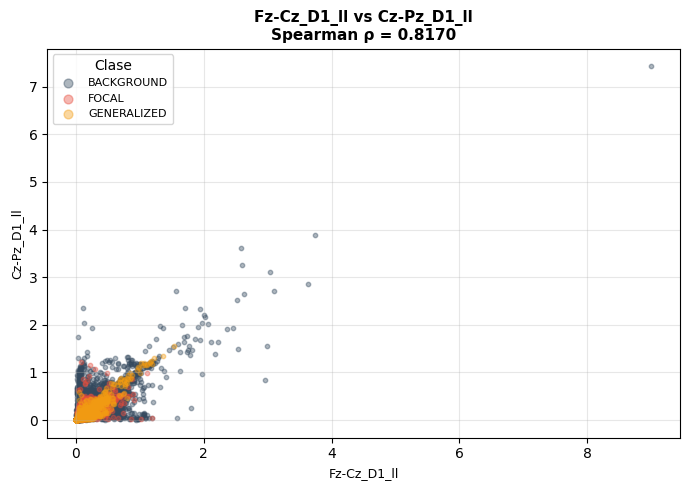

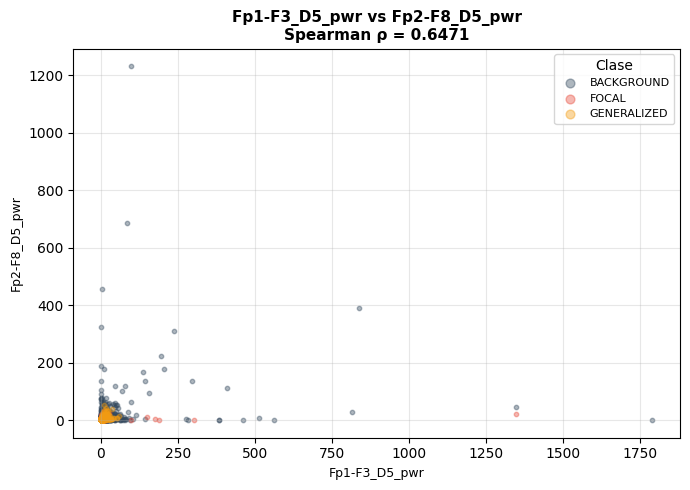

In [ ]:
# ── 3. Grupos correlacionados fuertes (|rho| >= 0.6) ──────────
df_fuertes = df_sig[abs(df_sig['Spearman ρ']) >= 0.6].copy()

if len(df_fuertes) > 0:
    tabla_fuertes = df_fuertes[['Ranking', 'Feature 1', 'Feature 2',
                                 'Spearman ρ', 'p-valor (FDR)', 'Dirección']].copy()

    styled_fuertes = tabla_fuertes.style.hide(axis='index').format({
        'Spearman ρ': '{:.4f}'
    }).background_gradient(
        cmap='RdBu_r', subset=['Spearman ρ']
    ).set_table_styles([
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                    ('width', 'auto'), ('border-collapse', 'collapse')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                      ('color', 'black'), ('font-weight', 'bold'),
                                      ('border', '1px solid black'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                      ('padding', '6px 15px'), ('background-color', 'white')]}
    ]).set_properties(
        subset=['Feature 1', 'Feature 2'], **{'text-align': 'left', 'font-weight': 'bold'}
    )

    display(HTML("<h4 style='text-align:center'>Grupos Correlacionados Fuertes (|rho| >= 0.6)</h4>"))
    display(HTML("<div style='text-align:center;'>" + styled_fuertes.to_html() + "</div>"))
    # ── 4. Gráficos de dispersión por par fuerte ───────────────
    display(HTML("<h4 style='text-align:center'>Gráficos de Dispersión — Pares con Correlación Fuerte</h4>"))
    

    for _, row in df_fuertes.iterrows():
        feat1 = row['Feature 1']
        feat2 = row['Feature 2']
        rho   = row['Spearman ρ']

        fig, ax = plt.subplots(figsize=(7, 5))

        for clase in clases:
            mask = df['class'] == clase
            ax.scatter(
                X_clean.loc[mask, feat1],
                X_clean.loc[mask, feat2],
                color=colores_clase.get(clase, '#95a5a6'),
                alpha=0.4, s=10, label=clase
            )

        ax.set_title(f'{feat1} vs {feat2}\nSpearman ρ = {rho:.4f}',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel(feat1, fontsize=9)
        ax.set_ylabel(feat2, fontsize=9)
        ax.legend(title='Clase', fontsize=8, markerscale=2)
        ax.grid(True, alpha=0.3)
        for spine in ax.spines.values():
            spine.set_visible(True)

        plt.tight_layout()
        plt.show()

        display(HTML("<hr style='margin: 20px 0; border: 1px solid #ddd;'>"))

else:
    display(HTML("<p style='text-align:center; color:#2c3e50;'>No se encontraron pares con correlacion fuerte (|rho| >= 0.6)</p>"))

:::class: note
Los dos pares con correlación fuerte identificados en el análisis bivariado revelan **patrones neurofisiológicamente coherentes** y aportan implicaciones directas para el enfoque clasificatorio.

---

###  Par 1 — Redundancia estructural  
**`Fz-Cz_D1_ll` vs `Cz-Pz_D1_ll` (ρ = 0.817, banda Beta)**  

La correlación fuerte entre estos dos canales adyacentes de la línea central refleja la **continuidad anatómica** y la propagación de la actividad eléctrica cortical a lo largo del eje fronto-parietal.  

Sin embargo, el hallazgo clave desde la perspectiva clasificatoria es la **superposición total de las clases** en el espacio bivariado. Esto confirma que la relación observada responde a un **artefacto de vecindad anatómica** y no a una señal discriminativa.

 En términos prácticos, este par representa **redundancia pura**: dos features que capturan el mismo fenómeno desde ubicaciones contiguas.  
 **Decisión recomendada:** conservar solo una de ellas para evitar problemas de **multicolinealidad**.

---

###  Par 2 — Sincronización funcional episódica  
**`Fp1-F3_D5_pwr` vs `Fp2-F8_D5_pwr` (ρ = 0.647, banda Delta)**  

Aquí la correlación moderada entre canales frontales homólogos introduce una interpretación más rica. La **sincronización interhemisférica en banda delta** es característica de las crisis generalizadas, donde la actividad epiléptica se propaga bilateralmente.

A diferencia del primer caso, la mayor dispersión y la presencia de **outliers de alta potencia** indican que esta relación es **episódica**, asociada principalmente a eventos ictales.

 Ambas variables capturan el mismo fenómeno fisiológico, pero su **valor discriminativo es individual, no conjunto**.  
 La correlación no implica redundancia total, sino **complementariedad parcial dependiente del contexto temporal**.

---

###  Implicación global

Ninguno de los dos pares genera **separabilidad entre clases en el espacio bivariado**, lo que refuerza una idea clave:

 La clasificación de **BACKGROUND, FOCAL y GENERALIZED** requiere el **espacio multivariado completo**.

- El **Par 1** justifica una **reducción de dimensionalidad** previa al modelado.  
- El **Par 2** sugiere que modelos capaces de capturar **variabilidad local y no lineal** serán más adecuados que modelos lineales.

---

 En conjunto, el análisis confirma que la correlación, por sí sola, no garantiza poder discriminativo, y que la verdadera capacidad predictiva emerge de la **interacción multivariada entre features**.
:::

# 5. Análisis de diferencia entre grupos

In [ ]:
from scipy.stats import kruskal
from itertools import combinations
import scikit_posthocs as sp

META_COLS = ['start_time', 'end_time', 'label', 'class']

# ── Kruskal-Wallis + Epsilon cuadrado ─────────────────────────
resultados_kw = []

for feat in features_top15:
    grupos = [df[df['class'] == clase][feat].dropna().values for clase in clases]
    stat, pval = kruskal(*grupos)
    
    # Epsilon cuadrado
    n_total = sum(len(g) for g in grupos)
    k = len(grupos)
    epsilon2 = (stat - k + 1) / (n_total - k)
    
    # Corrección de Holm
    resultados_kw.append({
        'Feature':    feat,
        'H (KW)':     round(stat, 4),
        'p-valor':    pval,
        'epsilon2':   round(epsilon2, 4)
    })

df_kw = pd.DataFrame(resultados_kw)

# Holm sobre p-valores
_, p_holm, _, _ = multipletests(df_kw['p-valor'], method='holm')
df_kw['p-valor (Holm)'] = p_holm
df_kw['p-valor fmt'] = df_kw['p-valor (Holm)'].apply(
    lambda p: '< 0.001 (ε)' if p < 0.001 else f'{p:.3f}'
)
df_kw['Relevante'] = df_kw['p-valor (Holm)'].apply(
    lambda p: 'Si' if p < 0.01 else 'No'
)

# Ordenar por epsilon cuadrado
df_kw = df_kw.sort_values('epsilon2', ascending=False).reset_index(drop=True)
df_kw.insert(0, 'Ranking', range(1, len(df_kw) + 1))

# Filtrar solo relevantes
df_kw_sig = df_kw[df_kw['Relevante'] == 'Si'].copy()

# ── Tabla ──────────────────────────────────────────────────────
tabla_kw = df_kw_sig[['Ranking', 'Feature', 'H (KW)', 
                        'p-valor fmt', 'epsilon2']].copy()
tabla_kw.columns = ['Ranking', 'Feature', 'H (KW)', 
                     'p-valor (Holm)', 'epsilon2']

styled_kw = tabla_kw.style.hide(axis='index').format({
    'H (KW)':   '{:.4f}',
    'epsilon2': '{:.4f}'
}).background_gradient(
    cmap='Blues', subset=['epsilon2']
).set_table_styles([
    {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                ('width', 'auto'), ('border-collapse', 'collapse')]},
    {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                  ('color', 'black'), ('font-weight', 'bold'),
                                  ('border', '1px solid black'), ('padding', '10px')]},
    {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                  ('padding', '6px 15px'), ('background-color', 'white')]}
]).set_properties(
    subset=['Feature'], **{'text-align': 'left', 'font-weight': 'bold'}
).set_properties(
    subset=['Ranking'], **{'background-color': '#f9f9f9', 'font-weight': 'bold'}
)

display(HTML("<h4 style='text-align:center'>Análisis de Grupos — Kruskal-Wallis + Epsilon² (Holm)</h4>"))
display(HTML("<div style='text-align:center;'>" + styled_kw.to_html() + "</div>"))

Ranking,Feature,H (KW),p-valor (Holm),epsilon2
1,P4-O2_A5_ll,1580.2172,< 0.001 (ε),0.0321
2,Cz-Pz_D5_ll,1186.4078,< 0.001 (ε),0.0247
3,P4-O2_D1_kurt,1000.1631,< 0.001 (ε),0.0203
4,Fp1-F3_D5_pwr,943.2259,< 0.001 (ε),0.0191
5,Cz-Pz_D1_ll,905.9003,< 0.001 (ε),0.0188
6,Cz-Pz_D1_ent,900.5113,< 0.001 (ε),0.0187
7,Fp2-F8_D5_pwr,913.0949,< 0.001 (ε),0.0185
8,P4-O2_D5_pwr,687.3858,< 0.001 (ε),0.0139
9,Fp2-F4_D4_teo,590.6498,< 0.001 (ε),0.0120
10,Fz-Cz_D1_ll,466.2423,< 0.001 (ε),0.0097


:::class: note
El uso de la prueba de **Kruskal-Wallis** para comparar las tres clases clínicas (**BACKGROUND, FOCAL y GENERALIZED**) responde directamente a las limitaciones identificadas en el análisis univariado. En primer lugar, ninguna de las variables sigue una distribución normal, como evidenció el test de **Kolmogorov-Smirnov**, cuyos mejores ajustes correspondieron a distribuciones como **Cauchy, Weibull y Gamma**. En segundo lugar, la prueba de **Brown-Forsythe** rechazó la homocedasticidad en la mayoría de las variables, invalidando el uso de pruebas basadas en igualdad de varianzas. Finalmente, la presencia de **outliers clínicamente relevantes** introduce sesgos importantes en medidas basadas en la media. Bajo estas condiciones, Kruskal-Wallis constituye la alternativa más adecuada, al evaluar diferencias en los **rangos** sin requerir supuestos paramétricos.

Para cuantificar la magnitud del efecto, se utilizó **Epsilon cuadrado (ε²)**, equivalente no paramétrico del eta cuadrado, que permite estimar la proporción de variabilidad atribuible a la pertenencia a clase. Asimismo, se aplicó la **corrección de Holm** para controlar el error familiar asociado a la realización de múltiples pruebas sobre las quince características seleccionadas.

---

Los resultados indican que las **quince features son estadísticamente significativas** (**p < 0.001** tras corrección de Holm), confirmando su capacidad para discriminar entre clases desde una perspectiva inferencial. Sin embargo, en contextos de gran tamaño muestral, el p-valor pierde capacidad interpretativa, por lo que el análisis se centra en el **tamaño del efecto (ε²)** como medida de utilidad práctica.

El hallazgo central es que **ninguna variable alcanza un efecto medio (ε² ≥ 0.06)**. Esto implica que, de forma individual, ninguna característica discrimina de manera robusta entre las tres clases clínicas.

---

El análisis de los tamaños de efecto permite identificar tres grupos diferenciados:

- **Mayor capacidad discriminativa (aunque aún limitada):**  
  La variable **P4-O2_A5_ll (ε² = 0.032)**, asociada a la longitud de línea en la banda de aproximación del canal parieto-occipital derecho, es la que aporta mayor capacidad de separación, capturando diferencias morfológicas globales entre actividad basal y eventos ictales.

- **Efectos pequeños pero consistentes:**  
  Variables como **Cz-Pz_D5_ll** y **P4-O2_D1_kurt (ε² ≈ 0.020–0.025)** muestran contribuciones estables en bandas de interés fisiológico, sugiriendo sensibilidad a patrones específicos de la señal.

- **Efectos prácticamente nulos:**  
  Las variables de asimetría (**_skew**, ε² ≈ 0.001–0.004) presentan una capacidad discriminativa muy limitada, indicando que su variabilidad no se traduce en separación efectiva entre clases.

Adicionalmente, las variables de **potencia espectral en banda delta** (**Fp1-F3_D5_pwr, Fp2-F8_D5_pwr, P4-O2_D5_pwr**, ε² ≈ 0.014–0.019) exhiben efectos homogéneos, coherentes con la **sincronización interhemisférica** observada en el análisis bivariado, lo que sugiere una fuente común de variabilidad explicada por clase.

---

La ausencia de variables con efectos individuales fuertes confirma que la clasificación multiclase de episodios epilépticos es inherentemente **multivariada**. En consecuencia:

- La estrategia de selección basada en **mRMR** resulta adecuada, al priorizar **diversidad informativa** sobre redundancia.  
- Se anticipa que modelos capaces de capturar **interacciones no lineales**, como **Random Forest** o **Gradient Boosting**, serán significativamente más efectivos que enfoques univariados o lineales.

En conjunto, el análisis refuerza la idea de que el poder predictivo no reside en variables individuales, sino en la **estructura conjunta del espacio de características**.
:::

In [ ]:
# ── Post-hoc Dunn con Holm para los 3 features top ────────────
features_plot = df_kw_sig.head(3)['Feature'].tolist()

for feat in features_plot:
    serie    = df[['class', feat]].dropna()
    dunn_res = sp.posthoc_dunn(
        serie, val_col=feat, group_col='class', p_adjust='holm'
    )

    # Formatear tabla Dunn
    dunn_fmt = dunn_res.copy()
    for col in dunn_fmt.columns:
        dunn_fmt[col] = dunn_fmt[col].apply(
            lambda p: '< 0.001 (ε)' if p < 0.001 else f'{p:.3f}'
        )

    styled_dunn = dunn_fmt.style.set_table_styles([
        {'selector': '', 'props': [('margin-left', 'auto'), ('margin-right', 'auto'),
                                    ('width', 'auto'), ('border-collapse', 'collapse')]},
        {'selector': 'th', 'props': [('text-align', 'center'), ('background-color', '#f2f2f2'),
                                      ('color', 'black'), ('font-weight', 'bold'),
                                      ('border', '1px solid black'), ('padding', '10px')]},
        {'selector': 'td', 'props': [('text-align', 'center'), ('border', '1px solid black'),
                                      ('padding', '6px 15px'), ('background-color', 'white')]}
    ])

    display(HTML(f"<h4 style='text-align:center'>Post-hoc Dunn (Holm) — {feat}</h4>"))
    display(HTML("<div style='text-align:center;'>" + styled_dunn.to_html() + "</div>"))
    display(HTML("<hr style='margin: 20px 0; border: 1px solid #ddd;'>"))

,BACKGROUND,FOCAL,GENERALIZED
BACKGROUND,1.000,< 0.001 (ε),< 0.001 (ε)
FOCAL,< 0.001 (ε),1.000,< 0.001 (ε)
GENERALIZED,< 0.001 (ε),< 0.001 (ε),1.000


,BACKGROUND,FOCAL,GENERALIZED
BACKGROUND,1.000,< 0.001 (ε),< 0.001 (ε)
FOCAL,< 0.001 (ε),1.000,< 0.001 (ε)
GENERALIZED,< 0.001 (ε),< 0.001 (ε),1.000


,BACKGROUND,FOCAL,GENERALIZED
BACKGROUND,1.000,< 0.001 (ε),< 0.001 (ε)
FOCAL,< 0.001 (ε),1.000,< 0.001 (ε)
GENERALIZED,< 0.001 (ε),< 0.001 (ε),1.000


:::class: note
El análisis post-hoc para las tres features con mayor relevancia (**P4-O2_A5_ll, Cz-Pz_D5_ll, P4-O2_D1_kurt**) revela que **todos los pares de clases clínicas** (**BACKGROUND vs FOCAL, BACKGROUND vs GENERALIZED, FOCAL vs GENERALIZED**) presentan **diferencias estadísticamente significativas** (**p < 0.001 tras corrección de Holm**).

Este resultado admite una lectura en dos niveles. Por un lado, confirma que las tres clases son **estadísticamente distinguibles** en cada una de estas variables, es decir, no existe ningún par de clases que resulte indistinguible en términos de **distribución de rangos**. Sin embargo, esta evidencia debe interpretarse con cautela: la significancia estadística uniforme no implica necesariamente una **separabilidad práctica robusta**. Tal como se observó en el análisis univariado, los tamaños de efecto son **pequeños (ε² < 0.06)**, lo que indica la presencia de un **solapamiento considerable entre las distribuciones**.

---

Desde una perspectiva clínica, resulta especialmente relevante que la comparación **FOCAL vs GENERALIZED** también sea significativa en las tres variables analizadas. Estas clases representan los dos principales tipos de actividad ictal y constituyen, en la práctica, el caso más desafiante desde el punto de vista diagnóstico.

El hecho de que métricas como:
- la **longitud de línea en la banda de aproximación** (**P4-O2_A5_ll**),  
- la **longitud de línea en banda delta** (**Cz-Pz_D5_ll**),  
- y la **curtosis en banda beta** (**P4-O2_D1_kurt**)  

permitan distinguir estadísticamente entre crisis focales y generalizadas sugiere que la **morfología temporal de la señal EEG** y la **irregularidad en bandas de alta frecuencia** contienen información diferencial relevante para la tipificación de los episodios epilépticos.

---

En síntesis, la separabilidad estadística universal entre todos los pares de clases en estas features constituye una **condición necesaria, pero no suficiente**, para una clasificación precisa. El solapamiento observado en las distribuciones confirma que el clasificador deberá operar en el **espacio multivariado completo** para lograr una discriminación efectiva entre las clases clínicas.
:::

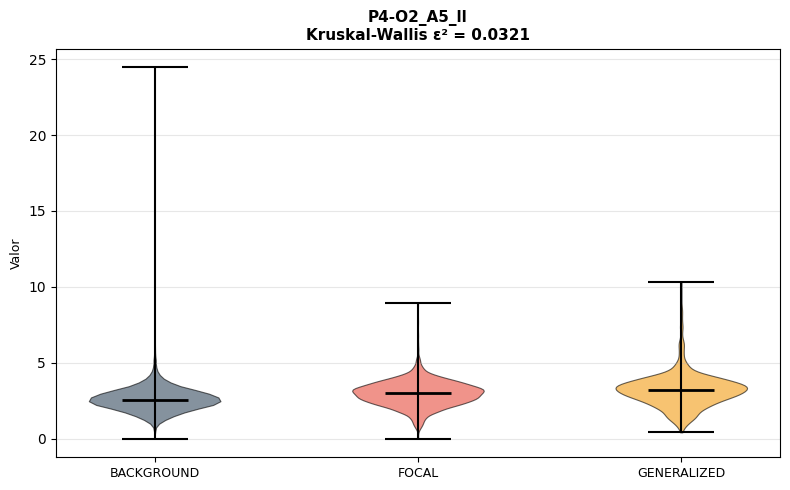

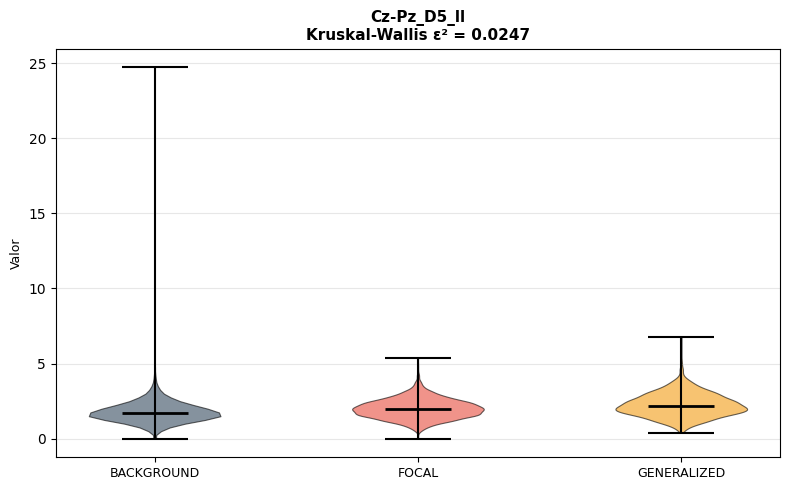

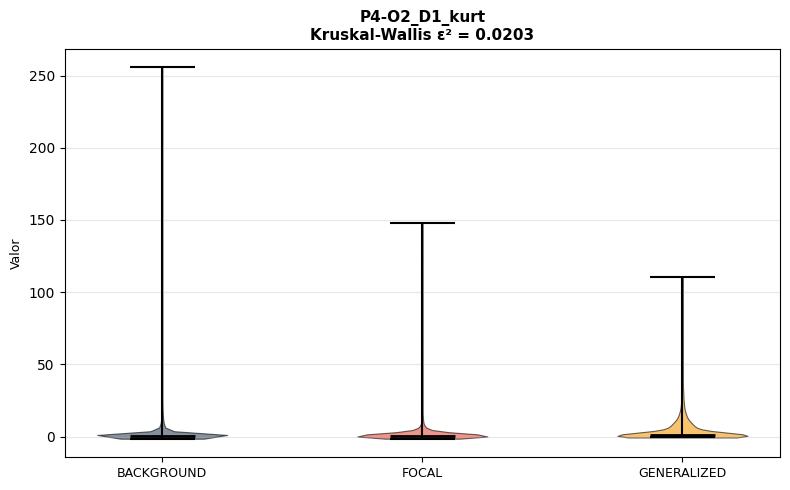

In [ ]:
# ── Visualización top 3 — Violin plot por clase ───────────────
for feat in features_plot:
    fig, ax = plt.subplots(figsize=(8, 5))

    data_violin = [df[df['class'] == clase][feat].dropna().values for clase in clases]

    parts = ax.violinplot(data_violin, positions=range(1, len(clases) + 1),
                          showmedians=True, showextrema=True)

    # Colorear cada violin por clase
    for i, (pc, clase) in enumerate(zip(parts['bodies'], clases)):
        pc.set_facecolor(colores_clase.get(clase, '#95a5a6'))
        pc.set_alpha(0.6)
        pc.set_edgecolor('black')
        pc.set_linewidth(0.8)

    # Línea de mediana
    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2)
    parts['cmaxes'].set_color('black')
    parts['cmins'].set_color('black')
    parts['cbars'].set_color('black')

    # Epsilon cuadrado como referencia
    eps2 = df_kw_sig[df_kw_sig['Feature'] == feat]['epsilon2'].values[0]

    ax.set_title(f'{feat}\nKruskal-Wallis ε² = {eps2:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xticks(range(1, len(clases) + 1))
    ax.set_xticklabels(clases, fontsize=9)
    ax.set_ylabel('Valor', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    for spine in ax.spines.values():
        spine.set_visible(True)

    plt.tight_layout()
    plt.show()
    display(HTML("<hr style='margin: 20px 0; border: 1px solid #ddd;'>"))

El análisis detallado de las distribuciones para las tres features más relevantes según el criterio de tamaño de efecto (ε²) aporta información clave sobre los patrones que subyacen a la discriminación entre clases clínicas.

Para la variable P4-O2_A5_ll (ε² = 0.032), se observa que las tres clases presentan distribuciones concentradas en valores bajos (0 a 5) y con morfología similar. Sin embargo, la clase BACKGROUND exhibe una cola superior extremadamente larga (alcanzando valores de hasta 25) que no se replica con la misma magnitud en FOCAL ni en GENERALIZED. Este hallazgo sugiere que la actividad de fondo EEG en el canal parieto-occipital derecho genera episodios de longitud de línea elevada en la banda de aproximación, probablemente vinculados a artefactos musculares o movimientos oculares característicos del estado de vigilia sin crisis. Las medianas de las tres clases son muy similares, lo que explica el tamaño de efecto reducido: la diferencia real entre grupos se manifiesta en los valores extremos y no en el comportamiento central de la distribución.

En Cz-Pz_D5_ll (ε² = 0.025) se repite un patrón análogo, pero de manera aún más marcada. BACKGROUND presenta una cola superior que alcanza valores de hasta 25, mientras que FOCAL y GENERALIZED rara vez superan el valor de 6. La mayor parte de las observaciones en las tres clases se solapa entre 0 y 3. Este patrón es interesante porque indica que la longitud de línea en delta en la línea central es más variable durante la actividad basal que durante las crisis, lo cual puede parecer contraintuitivo — se esperaría que las crisis generaran mayor actividad en delta — pero resulta coherente con el hecho de que el estado interictal presenta mayor variabilidad morfológica, mientras que los eventos ictales tienden a ser más estereotipados y regulares.

Para la variable P4-O2_D1_kurt (ε² = 0.020), la distribución es especialmente informativa desde el punto de vista clínico. La masa de las distribuciones en las tres clases está concentrada cerca de cero, pero BACKGROUND muestra una cola extrema que llega hasta 255, FOCAL hasta 150 y GENERALIZED hasta 110. La jerarquía de los valores extremos (BACKGROUND > FOCAL > GENERALIZED) indica que los eventos de alta curtosis en beta en el canal parieto-occipital se presentan con mayor frecuencia en la actividad de fondo que durante las crisis. Este resultado es neurofisiológicamente coherente, ya que una curtosis elevada en beta suele reflejar la presencia de spikes de alta frecuencia, típicos de la actividad interictal, mientras que en las crisis generalizadas la señal EEG tiende a ser más rítmica y menos abrupta.

En conjunto, la visualización de los tres violines confirma lo anticipado por el tamaño de efecto ε²: las diferencias entre clases no radican en los parámetros centrales de la distribución, sino en la estructura y extensión de los valores extremos. La clase BACKGROUND muestra consistentemente colas más largas que las clases ictales, lo que sugiere que la actividad de fondo es morfológicamente más heterogénea que las crisis, y que las variables que capturan dispersión extrema pueden resultar más discriminativas que aquellas basadas únicamente en tendencias centrales para la tarea de clasificación multiclase en EEG epiléptico.

# 6. Análisis estructural del espacio de características mediante reducción de dimensionalidad

## 6.1 Técnicas de reducción de dimensionalidad a utilizar

```{admonition} Contexto del análisis
:class: note

El conjunto de datos utilizado en este proyecto contiene millones de segmentos EEG descritos mediante múltiples características numéricas. Aunque en este estudio se seleccionaron únicamente **15 features estadísticamente relevantes**, el espacio de características sigue siendo difícil de interpretar directamente debido a la naturaleza multivariada de los datos.

Las técnicas de **reducción de dimensionalidad** permiten proyectar datos de alta dimensión en espacios de menor dimensión (generalmente 2D o 3D), preservando en la medida de lo posible la estructura geométrica de los datos. Esto facilita:

- visualizar patrones estructurales en el dataset
- detectar posibles agrupamientos naturales
- analizar separabilidad entre clases
- comprender relaciones no evidentes entre variables
```

```{admonition} Métodos utilizados
:class: tip

En este caso se utilizarán dos métodos principales:

- **Principal Component Analysis (PCA)**
- **Uniform Manifold Approximation and Projection (UMAP)**

Cada uno de estos métodos captura diferentes propiedades de la estructura del espacio de características.
```

---

### 6.1.1 Principal Component Analysis (PCA)

```{admonition} Definición
:class: note

El **Análisis de Componentes Principales (PCA)** es una técnica clásica de reducción de dimensionalidad basada en transformaciones lineales. Su objetivo es encontrar nuevas variables ortogonales denominadas **componentes principales**, que maximizan la varianza de los datos proyectados.
```

Formalmente, PCA busca vectores de dirección $w$ que maximicen la varianza de los datos proyectados:

$$
\max_w \; Var(Xw)
$$

sujeto a la restricción:

$$
||w|| = 1
$$

Esto conduce al problema de autovalores de la **matriz de covarianza**:

$$
\Sigma = \frac{1}{n} X^T X
$$

donde los **autovectores** de $\Sigma$ corresponden a las direcciones principales de variación de los datos.

Las proyecciones se obtienen mediante:

$$
Z = XW
$$

donde:

- $X$ es la matriz de datos estandarizados
- $W$ contiene los autovectores asociados a los mayores autovalores
- $Z$ representa los datos proyectados en el nuevo espacio reducido

### 6.1.2 Interpretación

```{admonition} Interpretación
:class: tip

Las primeras componentes principales capturan la mayor parte de la variabilidad presente en el dataset. En el contexto de señales EEG, esto permite identificar **direcciones dominantes de variación en las características derivadas de los canales cerebrales**.
```

### 6.1.3 Limitaciones

```{admonition} Limitación del método
:class: warning

PCA es un método **lineal**, lo que implica que solo puede capturar relaciones lineales entre variables. Sin embargo, la dinámica de señales EEG suele presentar **estructuras altamente no lineales**, por lo que PCA puede no ser suficiente para revelar la verdadera geometría de los datos.

Por esta razón se incorpora **UMAP** como método no lineal.
```

---

### 6.1.4 Uniform Manifold Approximation and Projection (UMAP)

```{admonition} Descripción del método
:class: note

UMAP es un algoritmo moderno de reducción de dimensionalidad basado en principios de **geometría diferencial y teoría de grafos**. Su objetivo es preservar la **estructura local del espacio de datos**, asumiendo que los datos de alta dimensión se encuentran distribuidos sobre una **variedad (manifold) de menor dimensión**.

El algoritmo se desarrolla en dos etapas principales.
```

### 6.1.5 Construcción del grafo de vecindad

Primero se construye un grafo ponderado donde cada punto se conecta con sus **k vecinos más cercanos**. Las probabilidades de conexión se calculan mediante una función de decaimiento exponencial:

$$
p_{ij} = \exp\left(-\frac{d(x_i, x_j) - \rho_i}{\sigma_i}\right)
$$

donde:

- $d(x_i, x_j)$ es la distancia entre puntos
- $\rho_i$ ajusta la distancia mínima local
- $\sigma_i$ controla la escala local del vecindario

### 6.1.6 Optimización en baja dimensión

Posteriormente se busca una representación de baja dimensión que preserve estas relaciones probabilísticas minimizando la divergencia entre grafos:

$$
C = \sum_{i \neq j} p_{ij}\log\frac{p_{ij}}{q_{ij}}
$$

donde $q_{ij}$ representa las probabilidades en el espacio reducido.

### 6.1.7 Interpretación

```{admonition} Interpretación
:class: tip

UMAP es particularmente eficaz para:

- preservar **estructuras locales**
- revelar **clusters de alta densidad**
- mantener separaciones naturales entre grupos

En el contexto de EEG, esto permite explorar si **los distintos tipos de crisis generan agrupamientos naturales en el espacio de características**.
```

---

## 6.2 Justificación del uso combinado de PCA y UMAP

```{admonition} Justificación metodológica
:class: important

Cada uno de los métodos utilizados captura distintos aspectos de la geometría del espacio de características:
```

| Método | Tipo | Qué preserva |
|------|------|------|
| PCA | Lineal | Varianza global |
| UMAP | No lineal | Estructura local |

```{admonition} Interpretación conjunta
:class: tip

El uso combinado de estas técnicas permite obtener una visión más completa de la organización del espacio de datos, permitiendo analizar simultáneamente:

- variabilidad global de las características
- agrupamientos locales entre tipos de crisis
- posibles transiciones estructurales entre estados neuronales

Esta estrategia proporciona una exploración más precisa del espacio de características antes de aplicar modelos de aprendizaje automático.
```

### 6.2.1 Preparación de las features

Antes de aplicar las **técnicas de reducción de dimensionalidad**, es necesario preparar adecuadamente el conjunto de datos. En particular, se requiere construir una **matriz de características** consistente que contenga **únicamente** las variables seleccionadas previamente como relevantes para la discriminación entre tipos de crisis epilépticas.

En la sección anterior se identificaron **15** características mediante análisis estadísticos no paramétricos basados en la prueba de **Kruskal–Wallis** y comparaciones **post-hoc** entre los distintos tipos de crisis. Estas variables constituyen el subconjunto de features que se utilizará para analizar la estructura del espacio de características mediante técnicas de proyección en baja dimensión.

In [ ]:
features_top15 = [
    "P4-O2_A5_ll",
    "P4-O2_D1_kurt",
    "Fp1-F7_D4_pwr",
    "T4-T6_D5_dkatz",
    "Fp2-F4_D3_dkatz",
    "P4-O2_D1_skew",
    "C4-P4_D1_skew",
    "Fp2-F8_A5_dkatz",
    "P3-O1_D1_ll",
    "Fp2-F4_D4_teo",
    "Fp1-F3_A5_dkatz",
    "F8-T4_D5_teo",
    "T6-O2_D1_skew",
    "Fp2-F4_D1_skew",
    "P4-O2_D5_pwr"
]

In [ ]:
from pathlib import Path
import pandas as pd

PARQUET_PATH = "C:/Users/USER/Desktop/EDA/04_TUSZ_Features_ML/version=v1_raw_labels"

all_files = list(Path(PARQUET_PATH).rglob("*.parquet"))

Dado que el conjunto de datos de características se encuentra almacenado en múltiples archivos en formato parquet, correspondientes a diferentes segmentos de señales EEG, se procede a identificar todos los archivos disponibles dentro del directorio correspondiente.

Posteriormente, cada archivo es leído y filtrado para conservar únicamente las 15 features seleccionadas junto con la variable de etiqueta (label), que indica el tipo de crisis asociado a cada segmento EEG.

In [ ]:
dfs = []

for f in all_files:
    
    df = pd.read_parquet(f)

    df = df[features_top15 + ["label"]]  

    dfs.append(df)

df_features = pd.concat(dfs, ignore_index=True)

print("Shape del dataset final:", df_features.shape)

Shape del dataset final: (1510532, 16)


In [ ]:
LABEL_MAPPING = {
    'bckg': 'BACKGROUND',
    'fnsz': 'FOCAL', 'cpsz': 'FOCAL', 'spsz': 'FOCAL',
    'gnsz': 'GENERALIZED', 'tcsz': 'GENERALIZED', 'tnsz': 'GENERALIZED',
    'absz': 'GENERALIZED', 'mysz': 'GENERALIZED'
}

df_features["class"] = df_features["label"].map(
    lambda x: LABEL_MAPPING.get(x, "BACKGROUND")
)

In [ ]:
print("Distribución de clases agrupadas:")
print(df_features["class"].value_counts())

Distribución de clases agrupadas:
class
BACKGROUND     1246253
FOCAL           168568
GENERALIZED      95711
Name: count, dtype: int64


```{admonition} Clases analizadas
:class: note
```

Es importante recordar que en este proyecto las crisis se **clasificaron** en **3** clases principales:

- Background
- Focal
- Generalized

Una vez cargados los archivos individuales, estos son concatenados para construir un único conjunto de datos consolidado.

El dataset resultante contiene **más de 1.5 millones de segmentos EEG**, cada uno descrito por las **15** características seleccionadas y su correspondiente **etiqueta de tipo de crisis**. Este volumen de datos proporciona una base **suficientemente representativa** para explorar la estructura del espacio de características mediante técnicas de **reducción de dimensionalidad**.

Para facilitar el análisis posterior, se separan las variables predictoras y la variable objetivo.

La **matriz X contiene exclusivamente las características seleccionadas, mientras que el vector Y contiene las etiquetas asociadas al tipo de crisis epiléptica**.

In [ ]:
X = df_features[features_top15]
y = df_features["class"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

Shape de X: (1510532, 15)
Shape de y: (1510532,)


<!-- Antes de aplicar técnicas de reducción de dimensionalidad, es **fundamental** verificar la calidad de los datos. -->

En particular, se revisa la **presencia de valores faltantes (NaN**) y **valores infinitos** dentro de las características seleccionadas. Este paso es crítico, ya que algoritmos como **PCA y UMAP** requieren matrices numéricas bien definidas y pueden fallar o producir resultados inestables si existen valores inválidos.

In [ ]:
print("NaN por feature:")

print(X.isna().sum())

NaN por feature:
P4-O2_A5_ll        0
P4-O2_D1_kurt      0
Fp1-F7_D4_pwr      0
T4-T6_D5_dkatz     0
Fp2-F4_D3_dkatz    0
P4-O2_D1_skew      0
C4-P4_D1_skew      0
Fp2-F8_A5_dkatz    0
P3-O1_D1_ll        0
Fp2-F4_D4_teo      0
Fp1-F3_A5_dkatz    0
F8-T4_D5_teo       0
T6-O2_D1_skew      0
Fp2-F4_D1_skew     0
P4-O2_D5_pwr       0
dtype: int64


In [ ]:
import numpy as np

print("Valores infinitos:", np.isinf(X).sum().sum())

Valores infinitos: 0


Es evidente entonces, que **no** hay presencia de **valores faltantes (Nan)** ni de **valores infinitos** en el conjunto de variables seleccionadas.

Posteriormente, las características son **estandarizadas** utilizando **StandardScaler**, lo cual **transforma cada variable para que tenga media cero y desviación estándar unitaria**.

Este paso es especialmente importante en técnicas como **PCA**, que son **sensibles a la escala de las variables**. La estandarización asegura que todas las características contribuyan de manera **comparable** al análisis, evitando que variables con mayor magnitud dominen la proyección del espacio de características.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape final:", X_scaled.shape)

Shape final: (1510532, 15)


### 6.2.2 Proyección PCA

A continuación se calcula la **proyección PCA** utilizando las features estandarizadas del dataset.

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Shape PCA:", X_pca.shape)

Shape PCA: (1510532, 2)


In [ ]:
print("Varianza explicada por componente:")
print(pca.explained_variance_ratio_)

print("Varianza acumulada:")
print(pca.explained_variance_ratio_.sum())

Varianza explicada por componente:
[0.11198491 0.09371307]
Varianza acumulada:
0.20569798


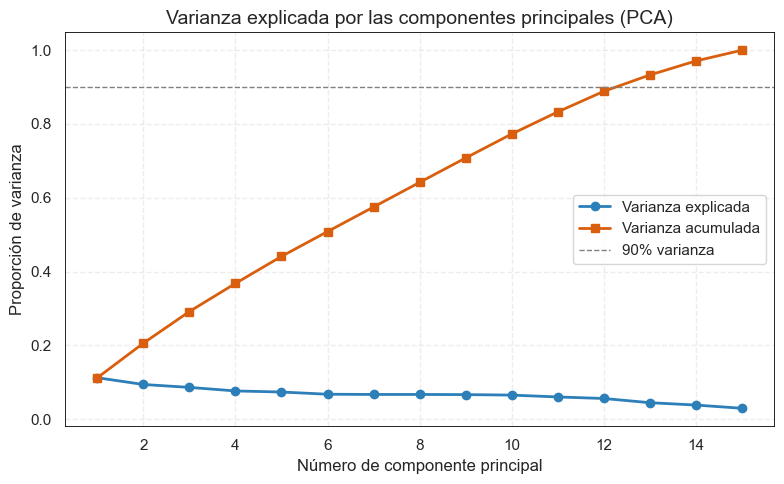

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pca_full = PCA()
pca_full.fit(X_scaled)

explained_var = pca_full.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

components = np.arange(1, len(explained_var)+1)

plt.figure(figsize=(8,5))

ax = plt.gca()

plt.plot(
    components,
    explained_var,
    marker="o",
    linewidth=2,
    color="#2c7fb8",
    label="Varianza explicada"
)

plt.plot(
    components,
    cum_var,
    marker="s",
    linewidth=2,
    color="#d95f0e",
    label="Varianza acumulada"
)

plt.axhline(
    y=0.90,
    linestyle="--",
    color="gray",
    linewidth=1,
    label="90% varianza"
)

plt.xlabel("Número de componente principal")
plt.ylabel("Proporción de varianza")
plt.title("Varianza explicada por las componentes principales (PCA)", fontsize=14)

plt.grid(True, linestyle="--", alpha=0.35)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.6)

plt.legend(frameon=True)

plt.tight_layout()
plt.show()

### 6.2.3 Varianza explicada por las componentes principales

```{admonition} Resultado principal del PCA
:class: important
```

El análisis de PCA muestra que la primera componente principal explica aproximadamente **11.2% de la varianza total**, mientras que la segunda componente explica cerca de **9.4%**. En conjunto, las dos primeras componentes capturan alrededor de **20.6% de la variabilidad presente en el espacio de características**.

---

Este resultado sugiere que la estructura de los datos no está dominada por unas pocas direcciones de variación, sino que la información relevante se encuentra distribuida a lo largo de múltiples dimensiones. Este comportamiento es esperable en datasets derivados de señales fisiológicas complejas, como el EEG, donde múltiples procesos neuronales contribuyen simultáneamente a las características extraídas.

En consecuencia, aunque la proyección en dos dimensiones permite visualizar parcialmente la estructura del espacio de características, es probable que una parte significativa de la variabilidad permanezca distribuida en componentes adicionales no representadas en esta visualización.

---

El **gráfico de varianza explicada** permite observar esta distribución de forma más clara. En él se aprecia que la proporción de varianza capturada por cada componente disminuye de manera gradual, sin presentar un **punto de “codo” (elbow)** pronunciado que indique la presencia de unas pocas direcciones dominantes. Asimismo, la curva de **varianza acumulada** muestra que es necesario incorporar un número considerable de componentes principales para capturar la mayor parte de la variabilidad del dataset.

---

```{admonition} Interpretación
:class: tip
```

Este comportamiento refuerza la idea de que la estructura del espacio de características es intrínsecamente **multidimensional**, lo que justifica posteriormente el uso de técnicas de reducción de dimensionalidad no lineales como **UMAP** para explorar patrones más complejos en los datos.

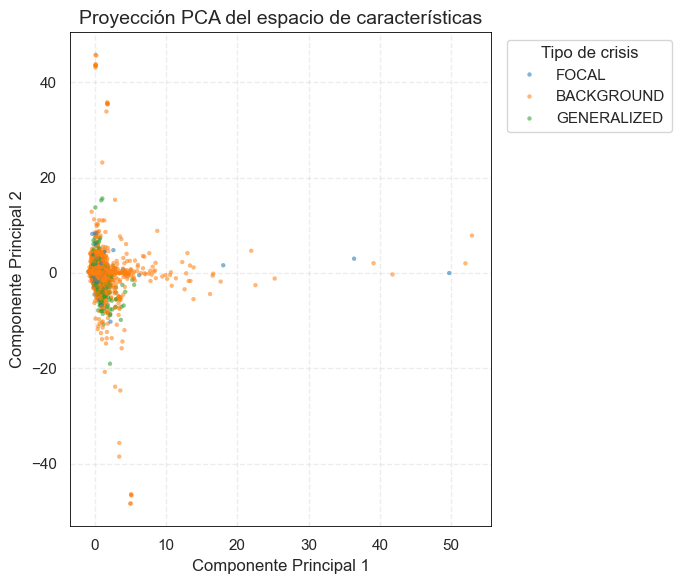

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="whitegrid")

df_pca = pd.DataFrame({
    "PC1": X_pca[:,0],
    "PC2": X_pca[:,1],
    "class": y
})

df_sample = df_pca.sample(50000, random_state=42)

plt.figure(figsize=(7,6))

ax = sns.scatterplot(
    data=df_sample,
    x="PC1",
    y="PC2",
    hue="class",
    palette="tab10",
    alpha=0.55,
    s=8,
    edgecolor=None
)

plt.title("Proyección PCA del espacio de características", fontsize=14)
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")

plt.grid(True, linestyle="--", alpha=0.35)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.6)

plt.legend(
    title="Tipo de crisis",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=True
)

plt.tight_layout()

plt.show()

### 6.2.4 Análisis visual de la proyección PCA

```{admonition} Lectura del plano PCA
:class: note
```

La proyección de los datos en las dos primeras componentes principales permite explorar la organización global del espacio de características derivadas de las señales EEG.

---

En la visualización se observa que la mayor densidad de puntos se concentra cerca del origen del plano PCA, lo que indica que una gran proporción de los segmentos EEG presentan valores similares en las combinaciones lineales de características capturadas por las dos primeras componentes. Este comportamiento sugiere que muchas observaciones comparten patrones estadísticos relativamente cercanos en el espacio de características.

Asimismo, se observa la presencia de algunos puntos alejados del centro de la distribución, lo que indica la existencia de observaciones con valores extremos en ciertas combinaciones de características. Estos puntos pueden corresponder a segmentos EEG con dinámicas particulares o a configuraciones específicas de actividad cerebral.

---

En cuanto a la distribución por tipo de crisis, no se aprecia una separación clara entre clases en el espacio definido por las dos primeras componentes principales. Las tres categorías clínicas consideradas **BACKGROUND, FOCAL y GENERALIZED** aparecen ampliamente solapadas en la proyección, lo que sugiere que las diferencias entre clases no se explican únicamente mediante combinaciones lineales de las características seleccionadas.

---

```{admonition} Implicación metodológica
:class: important
```

Este resultado es consistente con la naturaleza compleja de las señales EEG, donde las diferencias entre patrones neuronales suelen manifestarse mediante **relaciones no lineales entre variables**. Por esta razón, resulta pertinente aplicar métodos de reducción de dimensionalidad no lineales como **UMAP** que permiten capturar estructuras geométricas más complejas en el espacio de datos.

### 6.2.5 Proyección UMAP

Dado que el conjunto de datos completo contiene más de **1.5 millones de segmentos EEG**, aplicar directamente técnicas de proyección no lineal sobre todo el dataset se vuelve muy costoso computacionalmente. Por esta razón, se utiliza una **muestra representativa de 200 000 observaciones**, preservando la distribución original de las clases mediante un **muestreo estratificado**.

In [ ]:
import pandas as pd

df_model = X.copy()
df_model["class"] = y

Para construir esta muestra, primero se combinan las variables predictoras con la etiqueta de clase correspondiente. Posteriormente, se calcula el número de observaciones que deben seleccionarse para cada categoría clínica en función de su proporción en el dataset original. Este procedimiento asegura que la muestra mantenga la **misma estructura de clases** que los datos completos.

In [ ]:
sample_size = 200000

class_counts = df_model["class"].value_counts(normalize=True)

samples_per_class = (class_counts * sample_size).round().astype(int)

diff = sample_size - samples_per_class.sum()

if diff != 0:
    largest_class = samples_per_class.idxmax()
    samples_per_class[largest_class] += diff

print("Muestras por clase:")
print(samples_per_class)
print("Total:", samples_per_class.sum())

Muestras por clase:
class
BACKGROUND     165009
FOCAL           22319
GENERALIZED     12672
Name: proportion, dtype: int64
Total: 200000


La muestra obtenida contiene exactamente **200 000 segmentos EEG**, manteniendo proporciones similares entre las tres categorías clínicas consideradas: **BACKGROUND**, **FOCAL** y **GENERALIZED**. Este subconjunto conserva la estructura estadística del dataset original y es a su vez, lo suficientemente grande para explorar la organización del espacio de características mediante técnicas de reducción de dimensionalidad.

In [ ]:
dfs = []

for c, n in samples_per_class.items():
    dfs.append(
        df_model[df_model["class"] == c].sample(n=n, random_state=42)
    )

df_sample = pd.concat(dfs, ignore_index=True)

print("Shape muestra:", df_sample.shape)
print("\nDistribución de clases en la muestra:")
print(df_sample["class"].value_counts())

Shape muestra: (200000, 16)

Distribución de clases en la muestra:
class
BACKGROUND     165009
FOCAL           22319
GENERALIZED     12672
Name: count, dtype: int64


In [ ]:
X_sample = df_sample[features_top15]
y_sample = df_sample["class"]

Antes de aplicar UMAP, las características son **estandarizadas** utilizando `StandardScaler`. Este paso transforma cada variable para que tenga media cero y desviación estándar unitaria, evitando que diferencias en escala entre las features dominen la construcción del espacio proyectado.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_sample_scaled = scaler.fit_transform(X_sample)

print("Shape escalado:", X_sample_scaled.shape)

Shape escalado: (200000, 15)


Una vez estandarizadas las características, se aplica el algoritmo **UMAP** para proyectar los datos en un espacio bidimensional.

En este análisis se utilizan los siguientes hiperparámetros:

- **n_neighbors = 30**, que controla el tamaño del vecindario local considerado
- **min_dist = 0.1**, que regula qué tan compactos pueden ser los clusters en el espacio proyectado
- **metric = euclidean**, utilizada para medir distancias entre observaciones

In [ ]:
import umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric="euclidean",
    random_state=42
)

X_umap = umap_model.fit_transform(X_sample_scaled)

print("Shape UMAP:", X_umap.shape)

C:\Users\USER\anaconda3\envs\EEG_EDA_ML\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Shape UMAP: (200000, 2)


In [ ]:
df_umap = pd.DataFrame(
    X_umap,
    columns=["UMAP1", "UMAP2"]
)

df_umap["class"] = y_sample.values

print(df_umap.head())

       UMAP1     UMAP2       class
0   6.621403  1.884185  BACKGROUND
1  10.874754  2.479000  BACKGROUND
2  10.732440  3.820931  BACKGROUND
3   3.375502  6.730151  BACKGROUND
4   6.108049  4.604668  BACKGROUND


La proyección resultante permite visualizar la organización del espacio de características derivadas de los segmentos EEG. Cada punto en la figura representa un segmento de señal descrito por las **15 características seleccionadas previamente**, mientras que el color indica la categoría clínica correspondiente.

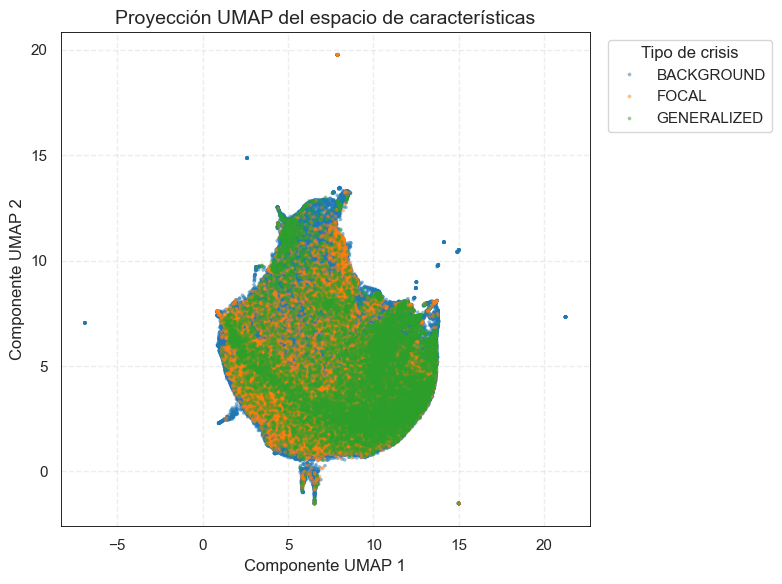

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,6))

ax = sns.scatterplot(
    data=df_umap,
    x="UMAP1",
    y="UMAP2",
    hue="class",
    palette="tab10",
    alpha=0.5,
    s=7,
    linewidth=0
)

plt.title("Proyección UMAP del espacio de características", fontsize=14)
plt.xlabel("Componente UMAP 1")
plt.ylabel("Componente UMAP 2")

plt.grid(True, linestyle="--", alpha=0.35)

plt.legend(
    title="Tipo de crisis",
    bbox_to_anchor=(1.02,1),
    loc="upper left",
    frameon=True
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(0.6)

plt.tight_layout()
plt.show()

### 6.2.6 Análisis visual de la proyección UMAP

La proyección UMAP revela la estructura global del espacio de características derivado de las señales EEG. En la visualización se observa una región central de alta densidad donde se concentra la mayoría de las observaciones, lo que indica que muchos segmentos EEG comparten configuraciones similares de las características analizadas.

---

```{admonition} Estructura geométrica del espacio de datos
:class: tip
```

A diferencia de la proyección PCA, UMAP permite apreciar **estructuras geométricas más complejas**, generadas por relaciones no lineales entre variables. Sin embargo, incluso utilizando esta técnica no lineal, las tres categorías clínicas consideradas **BACKGROUND, FOCAL y GENERALIZED** presentan un grado considerable de solapamiento en el espacio proyectado.

---

Este comportamiento es consistente con la naturaleza de las señales EEG, donde las diferencias entre patrones cerebrales asociados a distintos tipos de crisis epilépticas no siempre se manifiestan como separaciones claras en el espacio de características. En cambio, estas diferencias pueden reflejarse en **variaciones sutiles dentro de regiones densas del espacio de datos**.

```{admonition} Referencias
:class: note
```

Sharma, M., Dhere, A., & Pachori, R. B. (2020). EEG epileptic seizure detection and classification based on dual-tree complex wavelet transform and machine learning algorithms. *Biomedical Signal Processing and Control*, 57, 101711. https://doi.org/10.1016/j.bspc.2019.101711 [web:116]

Gómez, A., Santillán, A., et al. (2021). *Detección de epilepsia por EEG y desarrollo de un algoritmo localizador del área de inicio de la crisis*. Tesis de maestría, Escuela Colombiana de Ingeniería Julio Garavito, Bogotá, Colombia. Recuperado de https://repositorio.escuelaing.edu.co [web:136]

López, S., et al. (2019). *Correlación de hallazgos electroclínicos y neuroimagenológicos en epilepsia focal en la consulta externa de Neuropediatría del Hospital Infantil Manuel de Jesús Rivera, enero-diciembre 2018-2019*. Tesis, Universidad Nacional Autónoma de Nicaragua, Managua. Recuperado de https://www.minsa.gob.ni [web:146]


